# Учебный проект "Горизонт покупки"


## Описание проекта

### Задача 

Необходимо разработать модель которая предсказывает вероятность покупки клиентом интернет-магазина в ближайшие 90 дней на основе истории покупок, реакций на рассылки и агрегированной статистики по кампаниям.


### План работы

1. **Загрузка и первичный осмотр данных**
Чтение всех таблиц, изучение структуры, типов данных, размера таблиц, базовой статистики.

2. **Предобработка данных и создание кастомного предобработчика**
Приведение типов дат, обработка пропусков и аномалий если такие обнаружаться, нормализация `category_ids` извлекаем уникальные значения категорий

3. **Исследовательский анализ данных (EDA)**
Анализ распределений, выбросов, баланса целевого признака, динамики покупок и рассылок во времени, проверка корреляций между признаками.

4. **Feature engineering**
Создание временных признаков , агрегация событий рассылок по клиентам (число открытий, кликов по каналам), формирование финальной таблицы признаков.

5. **Корреляционный анализ**
Проверка корреляций с новыми признаками

6. **Обучение модели и подбор гиперпараметров**
Разделение данных по времени (обучение на ранних периодах, тест на последних 90 днях). Применение методов борьбы с дисбалансом классов (взвешивание, подбор порога). Обучение градиентного бустинга (LightGBM/CatBoost) с оптимизацией ROC‑AUC. При необходимости - отбор наиболее значимых признаков.

7. **Тестирование,  анализ признаков**
Оценка финальной модели на тестовой выборке, анализ важности признаков .  

8. создание файлов `README.md` и `requirements.txt`.

### Ожидаемый результат

**Репозиторий на GitHub который содержит:**
- Тетрадь jupyter notebook c выполненым проектом
- Описание и инструкция по использованию (файл README.md)
- файл requirements.txt со списком зависимостей библиотек необходимых для работы.

## Описание данных

1. `apparel-purchases` - история покупок

| Признак | Описание |
|---------|----------|
| `client_id` | Идентификатор клиента |
| `quantity` | Количество единиц товара в заказе |
| `price` | Цена товара |
| `category_ids` | Список идентификаторов категорий товара. **Особенность:** вложенность категорий может меняться со временем (один и тот же ID встречается на разных позициях), а также список может включать маркеры распродажи или половой принадлежности. |
| `date` | Дата покупки |
| `message_id` | Идентификатор сообщения из рассылки (если покупка совершена по рассылке) |

2. `apparel-messages` - история рекламных рассылок

| Признак | Описание |
|---------|----------|
| `bulk_campaign_id` | Идентификатор рекламной кампании |
| `client_id` | Идентификатор клиента |
| `message_id` | Идентификатор сообщения |
| `event` | Тип действия с сообщением (отправлено, открыто, покупка и др.) |
| `channel` | Канал рассылки |
| `date` | Дата действия |
| `created_at` | Точное время создания сообщения |

3. `apparel-target_binary` - целевой признак

| Признак | Описание |
|---------|----------|
| `client_id` | Идентификатор клиента |
| `target` | Совершил ли клиент покупку в течение следующих 90 дней (бинарный признак) |

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#from scipy import stats
from scipy.stats import randint, uniform

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from lightgbm import LGBMClassifier
from phik import phik_matrix
from xgboost import XGBClassifier

import ast
import joblib


## Настройки для  графиков и датасетов

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('ggplot')
sns.set_palette('tab10')

## Константы

In [3]:
RANDOM_STATE = 42
SIZE = 0.25
CV_FOLDS = 5

HORIZON = 90

## Подготовка данных

### Загрузка и первичный осмотр

In [4]:
def load_dataset(path):
    try:
        df = pd.read_csv(path)
        print(f'Загружен файл: {path}')
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f'Файл не найден: {path}')
    except Exception as e:
        raise Exception(f'Ошибка при загрузке {path}: {type(e).__name__}: {e}')

In [5]:
def show_data(df, n_separator=60):
    
    def separator(n_sep=n_separator):
        print('='*n_sep)

    separator()
    print('\nОбщая информация о датасете')
    separator()
    print(f'Количество строк: {df.shape[0]}')
    print(f'Количество столбцов: {df.shape[1]}')
    
    print('\nИнформация о столбцах:')
    separator()
    print(df.info())
    
    print('\nПервые 5 строк датасета:')
    separator()
    display(df.head().style) 

In [6]:
def separator(sep='=', n=60):
    print(sep*n)

#### Загрузка и первичный осмотр `apparel-purchases.csv`

In [7]:
df_purchases = load_dataset('data/apparel-purchases.csv')
show_data(df_purchases)

Загружен файл: data/apparel-purchases.csv

Общая информация о датасете
Количество строк: 202208
Количество столбцов: 6

Информация о столбцах:
<class 'pandas.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   client_id     202208 non-null  int64  
 1   quantity      202208 non-null  int64  
 2   price         202208 non-null  float64
 3   category_ids  202208 non-null  str    
 4   date          202208 non-null  str    
 5   message_id    202208 non-null  str    
dtypes: float64(1), int64(2), str(3)
memory usage: 9.3 MB
None

Первые 5 строк датасета:


,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.000000,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.000000,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.000000,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.000000,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.000000,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


In [8]:
df_purchases.describe()

,client_id,quantity,price
count,202208.00,202208.00,202208.00
mean,1515915625596210944.00,1.01,1193.30
std,145945755.93,0.18,1342.25
min,1515915625468060928.00,1.00,1.00
25%,1515915625490081280.00,1.00,352.00
50%,1515915625557177088.00,1.00,987.00
75%,1515915625624391936.00,1.00,1699.00
max,1515915626010443520.00,30.00,85499.00


In [9]:
df_purchases.describe(include=['str']).T

,count,unique,top,freq
category_ids,202208,933,"['4', '28', '57', '431']",8626
date,202208,642,2022-11-11,5270
message_id,202208,50204,1515915625489095763-6251-6311b13a4cf78,365


##### Выводы по результатам осмотра `apparel-purchases.csv`

1.  Объём: 202 208 строк и 6 столбцов
2.  Пропуски на первый взгляд отсутствуют
3.  В столбеце `category_ids` данные записаны в текстовом формате. необходимо будет перевести в список.  
    Самаые популярные товары относятся к категории `['4', '28', '57', '431']`. товары из этой категории заказали 8626 раз
4.  В столбце `date` данные записаны в текстовом формате. необходимо будет перевести в datetime  
    Стоит отметить что 11 ноября 22 года было совершено рекордное количество покупок - 5270.  
    Дата совпадает с днем распродаж известной как черная пятница
5.  данные в столбце `client_id` имеют тип `int` но по смыслу имеют категориальное значение. Необходимо привести к соответствующему формату
6.  `quantity` 
   - Среднее значение 1.006, медиана, первый и третий квартиль -1. стандартное отклонение 0.18  
     В 75% случаев во всех покупках только 1 товар. Но крайне редку встречаются и крупные покупки (Max = 30)
7. `price` 
    - цена основной массы покупок находиться в диапазоне от 350 до 1700 у.е.
    - но встречаются как слишком дешевые товары со стоимостью 1 у.е., возможно акционные товары для привлечения клиентов так и очень дорогие, до 85500 у.е. вероятно брендовые товары или товары премиум сегиента.
    - Высокое стандартное отклонение говорит о существенном разбросе стоимости товаров. Нужно быть готовым к наличию выбросов.

Датасет пригоден для дальнейшего анализа

#### Загрузка и первичный осмотр данных файла `apparel-messages.csv`

In [10]:
df_messages = load_dataset('data/apparel-messages.csv')
show_data(df_messages)

Загружен файл: data/apparel-messages.csv

Общая информация о датасете
Количество строк: 12739798
Количество столбцов: 7

Информация о столбцах:
<class 'pandas.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype
---  ------            -----
 0   bulk_campaign_id  int64
 1   client_id         int64
 2   message_id        str  
 3   event             str  
 4   channel           str  
 5   date              str  
 6   created_at        str  
dtypes: int64(2), str(5)
memory usage: 680.4 MB
None

Первые 5 строк датасета:


,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52


In [11]:
df_messages.describe()

,bulk_campaign_id,client_id
count,12739798.00,12739798.00
mean,11604.59,1515915625574831616.00
std,3259.21,132970411.56
min,548.00,1515915625468060928.00
25%,8746.00,1515915625489149440.00
50%,13516.00,1515915625503432192.00
75%,14158.00,1515915625591286272.00
max,14657.00,1515915626010288640.00


In [12]:
df_messages.describe(include=['str']).T

,count,unique,top,freq
message_id,12739798,9061667,1515915625489095763-6251-6311b13a4cf78,1454
event,12739798,11,send,9058196
channel,12739798,2,mobile_push,7512156
date,12739798,638,2023-06-10,89661
created_at,12739798,4103539,2023-12-29 15:20:53,621


##### Выводы по результатам осмотра `apparel-messages.csv`

1.  Объём: 12 739 797 строк и 6 столбцов. Достаточно большой массив данных. потребуется оптимизация.
2.  Пропуски на первый взгляд отсутствуют
3.  данные в столбцах `client_id`, `bulk_campaign_id` имеют тип `int` но по смыслу имеют категориальное значение. Необходимо привести к соответствующему формату
4.  `message_id` имеет дубликаты. нектореы рассылки имали массовый характер и вероятно использовались разные каналы доставки сообщений
5.  10 июня 23 года было отправлено почти 90 тысяч сообщений. а  29 декабря 23 года в 15:20:23 было отправлено 621 сообщение, вероятно массовая рассылка с акциями к Новогодним праздникам. Необходимо провести анализ отправки сообщений в разрезе дат. временные интервалы стоит разбить на несколько групп, наприимер утро день вечер и нось. таким образом вместо тысяч уникальных значений получим 4 явные категории.
6.  в столбцах `date` и `created_at` данные записаны в текстовом формате. необходимо будет перевести в datetime и провести проверку на дублирование информации. На первый взгляд дата в обоих столбцах совпадает, но в столбце `created_at` добавлено время
7.  самая частая кампания рассылок с id 14272 - 104,5 тыс событий

Датасет пригоден для дальнейшего анализа

#### Загрузка и первичный осмотр данных файла `apparel-target_binary.csv`

In [13]:
df_target = load_dataset('data/apparel-target_binary.csv')
show_data(df_target)

Загружен файл: data/apparel-target_binary.csv

Общая информация о датасете
Количество строк: 49849
Количество столбцов: 2

Информация о столбцах:
<class 'pandas.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  49849 non-null  int64
 1   target     49849 non-null  int64
dtypes: int64(2)
memory usage: 779.0 KB
None

Первые 5 строк датасета:


,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0


In [14]:
df_target.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.98, 0.99])

,client_id,target
count,49849.00,49849.00
mean,1515915625598796032.00,0.02
std,148794654.89,0.14
min,1515915625468060928.00,0.00
25%,1515915625489972736.00,0.00
50%,1515915625556614912.00,0.00
75%,1515915625633408768.00,0.00
90%,1515915625854859776.00,0.00
98%,1515915625987224320.00,0.00
99%,1515915626000332288.00,1.00


##### Выводы по результатам осмотра `apparel-target_binary.csv`

1.  Объём: 49 849 строк и 2 столбца . 
2.  Пропуски на первый взгляд отсутствуют
3.  данные в столбцe `client_id` имеют тип `int` но по смыслу имеют категориальное значение. Необходимо привести к соответствующему формату для дальнейшего исследования
4.  `target` бинарный целевой признак имеет значения 1 и 0
5.  Заметен сильный дисбаланс классов. 98% клиентов не совершали повторные покупки. У компании существует серьёзная проблема с удержанием клиентов.


Датасет пригоден для дальнейшего анализа

### Приведение типов

#### `client_id` и `bulk_campaign_id` в 'category'

In [15]:
df_purchases[['client_id',  'message_id']] = df_purchases[['client_id',  'message_id']].astype('category')
df_messages[['client_id',  'message_id', 'bulk_campaign_id']] = df_messages[['client_id',  'message_id', 'bulk_campaign_id']].astype('category')
df_target['client_id'] = df_target['client_id'].astype('category')



####  Преобразование дат в datetime

In [16]:
for col in ['date', 'created_at']:
    df_messages[col] = pd.to_datetime(df_messages[col], errors='raise')


In [17]:
df_purchases['date'] = pd.to_datetime(df_purchases['date'], errors='raise')

In [18]:
df_purchases.info()

<class 'pandas.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     202208 non-null  category      
 1   quantity      202208 non-null  int64         
 2   price         202208 non-null  float64       
 3   category_ids  202208 non-null  str           
 4   date          202208 non-null  datetime64[us]
 5   message_id    202208 non-null  category      
dtypes: category(2), datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 8.5 MB


In [19]:
df_messages.info()

<class 'pandas.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype         
---  ------            -----         
 0   bulk_campaign_id  category      
 1   client_id         category      
 2   message_id        category      
 3   event             str           
 4   channel           str           
 5   date              datetime64[us]
 6   created_at        datetime64[us]
dtypes: category(3), datetime64[us](2), str(2)
memory usage: 579.8 MB


#### Результаты Приведения типов

- идентификаторы клиентов, рассылок и рассылочных кампаний приведены к типу 'category' и в дальнейшем будут рассматриваться как категориальные
- даты приведены к `datetime`

### Переименование  столбцов

In [20]:
df_purchases = df_purchases.rename(columns={
    'date': 'purchase_date'
})

In [21]:
df_messages = df_messages.rename(columns={ 
    'date': 'message_date', 
    'created_at': 'message_created_at' 
    })

#### Результат

Провели переименование столбцов для имеющих одинаковые названия но отражающих разное значени (даты покупки и даты отправки сообщений)

### Проверка на дубликаты

In [22]:
def check_remove_duplicates(df, column_name=None, remove_duplicates=False, keep='first', n_rows=10):
    """
    Функция для проверки  и удаления дубликатов
    
    Параметры:
    df - DataFrame
    column_name - имя столбца (None для всего датафрейма) (по умолчанию column_name=None)
    remove_duplicates - флаг для удаления дубликатов (по умолчанию remove_duplicates=False)
    keep - какие дубликаты сохранять ('first', 'last', False) (по умолчанию keep='first')
    n_rows - количество строк которые для вывода в примере df с дубликатами (int) (по умолчанию n_rows=10)
    
    Возвращает: обработанный DataFrame
    """
    subset = [column_name] if column_name else None
    text = f"в столбце '{column_name}'" if column_name else "во всем датафрейме"

    #вычисление статистики
    dup_mask = df.duplicated(subset=subset, keep=keep)
    total = len(df)
    dup_count = dup_mask.sum()
    dup_pct = (dup_count / total) * 100 if total > 0 else 0

    # Вывод статистики
    print(f"Анализ дубликатов {text}:")
    separator()
    print(f"Всего записей: {total}")
    print(f"Дубликатов: {dup_count}")
    print(f"Процент: {dup_pct:.2f}%")

    # Вывод примеров
    if dup_count > 0:
        print("\nПримеры дублирующихся строк:")    
        if column_name:
            display(df[dup_mask].sort_values(by=column_name).head(n_rows))
        else:
            display(df[dup_mask].sort_values(by=df.columns.tolist()).head(n_rows))
    
    # Удаление дубликатов
    if remove_duplicates:
        start = len(df)
        df = df.drop_duplicates(subset=subset, keep=keep)
        removed = start - len(df)
        separator()
        print("Результат удаления:")
        separator()
        print(f"Удалено: {removed}")
        print(f"Осталось: {len(df)}")
        
        if removed > 0:
            new_dup = df.duplicated(subset=subset, keep=False).sum()
            new_pct = (new_dup / len(df)) * 100 if len(df) > 0 else 0
            print(f"Текущие дубликаты: {new_dup}")
            print(f"Текущий процент: {new_pct:.2f}%")

    separator()
    print('\n')
    return df if remove_duplicates else None

#### Проверка на дубликаты в `df_purchases`

In [23]:
check_remove_duplicates(df_purchases, remove_duplicates=False, keep='first', n_rows=10)

Анализ дубликатов во всем датафрейме:
Всего записей: 202208
Дубликатов: 73020
Процент: 36.11%

Примеры дублирующихся строк:


,client_id,quantity,price,category_ids,purchase_date,message_id
3699,1515915625468060902,1,199.00,"['4', '27', '176', '458']",2022-05-27,1515915625468060902-4617-6290657dac196
3698,1515915625468060902,1,1999.00,"['4', '28', '260', '420']",2022-05-27,1515915625468060902-4617-6290657dac196
81794,1515915625468061003,1,2100.00,"['4', '28', '249', '615']",2023-01-04,1515915625468061003-9148-63b54b04855a4
200016,1515915625468061100,1,1049.00,"['4', '27', '1828', '5717']",2024-02-10,1515915625468061100-14623-65c5c55eeb9e0
95807,1515915625468061170,1,7.00,[],2023-03-26,1515915625468061170-11144-641ad2cda77a2
141477,1515915625468061170,1,999.00,"['4', '28', '244', '432']",2023-06-17,1515915625468061170-13157-6483192913837
141478,1515915625468061170,1,999.00,"['4', '28', '244', '432']",2023-06-17,1515915625468061170-13157-6483192913837
96093,1515915625468061170,1,1609.00,"['4', '28', '260', '420']",2023-03-29,1515915625468061170-11208-6423f082d2fcb
96101,1515915625468061170,1,2194.00,"['4', '28', '260', '420']",2023-03-29,1515915625468061170-11208-6423f082d2fcb
96095,1515915625468061170,1,2195.00,"['4', '28', '260', '420']",2023-03-29,1515915625468061170-11208-6423f082d2fcb


##### Выводы

В датасете df_purchases обнаружено 73020 полных дубликата что составляет более 36% от общего числа данных.  
Но так как клиенты могут совершать одинаковые покупки в один и тот же день, а в дате покупки не отражено её точное время (две покупки не совержиьт за 1 секунду) нельзя с уверенностью сказать что дубликаты являются ошибочными записями а не реальными повторными приобретениями одних и тех же товаров в один день.

Эти дубликаты оставим без обработки

#### Проверка на дубликаты в `df_messages`

In [24]:
df_messages = check_remove_duplicates(df_messages,  remove_duplicates=True, keep='first', n_rows=10)

Анализ дубликатов во всем датафрейме:
Всего записей: 12739798
Дубликатов: 48610
Процент: 0.38%

Примеры дублирующихся строк:


,bulk_campaign_id,client_id,message_id,event,channel,message_date,message_created_at
9453808,3131,1515915625491874218,1515915625491874218-3131-621889fa7e306,click,email,2023-11-17,2023-11-17 17:15:21
5228980,3401,1515915625471119033,1515915625471119033-3401-62304447d2158,click,email,2023-05-25,2023-05-25 05:46:21
5281390,3401,1515915625471119033,1515915625471119033-3401-62304447d2158,click,email,2023-05-25,2023-05-25 17:24:27
4679281,3433,1515915625488270582,1515915625488270582-3433-6232d6007e929,click,email,2023-04-10,2023-04-10 02:07:04
5170207,3433,1515915625488270582,1515915625488270582-3433-6232d6007e929,click,email,2023-05-20,2023-05-20 14:30:09
5281782,3433,1515915625488270582,1515915625488270582-3433-6232d6007e929,click,email,2023-05-25,2023-05-25 21:45:28
5434920,3433,1515915625488270582,1515915625488270582-3433-6232d6007e929,click,email,2023-06-02,2023-06-02 09:20:05
5849285,3433,1515915625488270582,1515915625488270582-3433-6232d6007e929,click,email,2023-06-22,2023-06-22 19:07:18
8580465,3557,1515915625472711460,1515915625472711460-3557-623d68bab126a,click,email,2023-10-17,2023-10-17 23:47:09
4296545,3933,1515915625491053423,1515915625491053423-3933-6257f0c0c835c,click,email,2023-03-08,2023-03-08 20:17:37


Результат удаления:
Удалено: 48610
Осталось: 12691188
Текущие дубликаты: 0
Текущий процент: 0.00%




##### Выводы

В результате проверки  `df_messages` обнаружено 48 610 полных дубликатов - 0,38% от всех записей. Учитывая, что одному клиенту в один и тот же канал невозможно отправить более одного сообщения за одну секунду (любые дополнительные отправки в этот момент это технические ошибки), все выявленные дубликаты являются ошибками и должны быть удалены.


Проведено удаление дубликатов. Оставлено первое вхождение. Удалено 48 610 записей

#### Проверка на дублирование информации в `date` и `message_created_at`

In [25]:
df_messages['date_from_created_at'] = df_messages['message_created_at'].dt.date

In [26]:
matches = (df_messages['message_date'].dt.date == df_messages['date_from_created_at'])

In [27]:
print(f"Процент совпадений: {matches.mean() * 100: .0f}%")

Процент совпадений:  100%


In [28]:
df_messages = df_messages.drop(columns=['date_from_created_at', 'message_date'])

In [29]:
df_messages.head()  

,bulk_campaign_id,client_id,message_id,event,channel,message_created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19 00:56:52


##### Выводы

Проверка показала полное совпадение дат в столбцах `message_date` и `message_created_at`. 

- `message_date` содержит только дату события.
- `message_created_at` содержит полную временную метку до секунд

так как столбец `message_date` является избыточным и не несёт дополнительной информации,  
для избежания путаницы при группировках данных и экономии памяти мы его удалили

#### Проверка на дубликаты в `df_target`

In [30]:
check_remove_duplicates(df_target, remove_duplicates=False, keep='first', n_rows=10)

Анализ дубликатов во всем датафрейме:
Всего записей: 49849
Дубликатов: 0
Процент: 0.00%




##### Выводы
В датасете `df_target` дубликаты не обнаружены

## EDA - Исследовательский анализ

In [31]:
def analyze_feature(df, feature, bins=50, title=None, figsize=(12,5), delta_y=1, rename_columns = None, only_chart = False):
    """
    Проводит комплексный анализ числового признака  в DataFrame, включая построение графиков
    распределения, "ящика с усами" и и статистический анализ выбросов.
    """
    def separator():
        print("=" * 50)
    if rename_columns:
       text = f'параметра: {rename_columns[feature]}'
    elif title:
       text = f'параметра: {title}'
    else:
       text = f'параметра: {feature}'
    
    if not only_chart:
        separator()
        print("Анализ " + text)
       
        # описательная статистика
        print(f"\nОписательная статистика {text}:")
        stats = df[feature].describe().apply(lambda x: format(x, '0.2f'))
        print(stats)

    label = feature if title else title
    # Создаем финуру с несколькими  графиками
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=figsize)
    plt.subplots_adjust(wspace=0.3)  # увеличим пространство между графиками
    # задаем цета для графиков
    hist_color = '#3498db'  
    kde_color = '#e74c3c'  
    mean_color = '#16a085'  
    median_color = '#f39c12' 

    # строим гистограмму распределения
    sns.histplot(data=df[feature],
                 bins=bins,
                 edgecolor=hist_color,
                 linewidth=1,
                 alpha=0.6,
                 label='Распределение',
                 kde=True,
                 ax=ax1).lines[0].set_color(kde_color)
    
   # добавим линии среднего и медианы
    mean = df[feature].mean()
    median = df[feature].median()
    ax1.axvline(mean, color=mean_color, linestyle='--', 
                linewidth=2.5, label=f'Среднее: {mean:.2f}')
    ax1.axvline(median, color=median_color, linestyle=':', 
                linewidth=2.5, label=f'Медиана: {median:.2f}')
    
    # Настройки оформления
    ax1.set_title(f"Гистограмма распределения\n{text}", fontsize=14, pad=10)
    ax1.set_xlabel(title, fontsize=12)
    ax1.set_ylabel('Плотность', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(fontsize=10, framealpha=1, shadow=True)
   
    y_max = ax1.get_ylim()[1]  #текущий максимум оси Y
    ax1.set_ylim(top=y_max * delta_y)  # доп. отступ сверху чтобы легенда не заползала


    # ящик с усами
    box_color = '#3498db'
    sns.boxplot(x=df[feature], 
                color=box_color, 
                width=0.3, 
                linewidth=2, 
                # настроим отображение выбросов
                flierprops=dict(
                    marker='D', # ромб
                    markersize=5, 
                    markerfacecolor='#e74c3c'), 
                ax=ax2)
    ax2.set_title(f'"Ящик с усами" для\n{text}', fontsize=14, pad=10)
    ax2.set_xlabel('')
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    
    plt.tight_layout(pad=3, h_pad=2, w_pad=3)
    plt.show()
    
#анализ выбросов  (правило 1.5 * IQR)
# Любая точка данных, которая на 1,5 IQR ниже первого квартиля или выше третьего, является выбросом
    
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
        
    if not only_chart:
        print(f"\nМежквартильный размах: {iqr:.3f}")
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    
    if not only_chart:
        print(f"\nКоличество выбросов: {len(outliers)}")
        if len(outliers)>0:
            print(f"Границы выбросов: [{lower_bound:.2f}, {upper_bound:.2f}]")
            print("\nПримеры выбросов:")
            print(outliers[feature].head(10))
            separator()
        else:
            separator()
    
    return lower_bound, upper_bound

### EDA `df_purchases`

In [32]:
df_purchases.shape

(202208, 6)

In [33]:
df_purchases.info()

<class 'pandas.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   client_id      202208 non-null  category      
 1   quantity       202208 non-null  int64         
 2   price          202208 non-null  float64       
 3   category_ids   202208 non-null  str           
 4   purchase_date  202208 non-null  datetime64[us]
 5   message_id     202208 non-null  category      
dtypes: category(2), datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 8.5 MB


#### Анализ параметра `quantity` - количество 

Анализ параметра: Количество приобретенных товаров

Описательная статистика параметра: Количество приобретенных товаров:
count    202208.00
mean          1.01
std           0.18
min           1.00
25%           1.00
50%           1.00
75%           1.00
max          30.00
Name: quantity, dtype: str


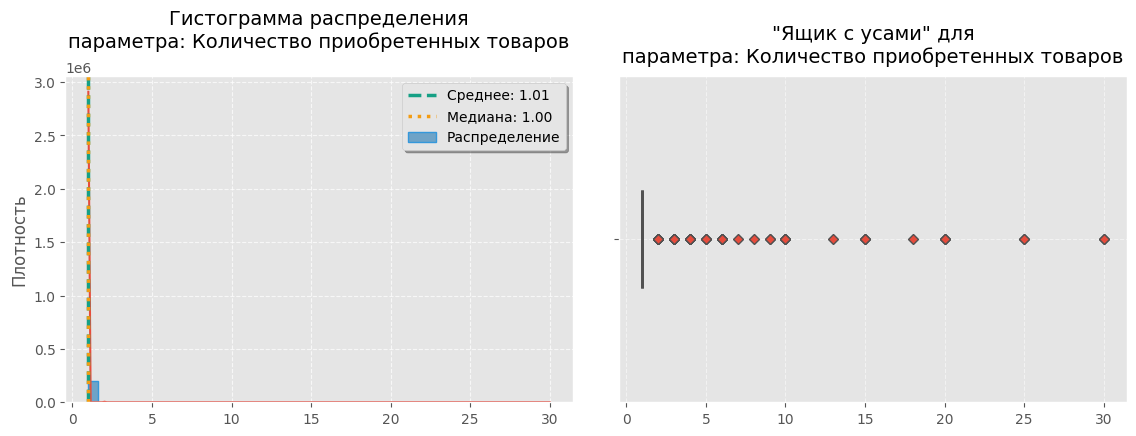


Межквартильный размах: 0.000

Количество выбросов: 885
Границы выбросов: [1.00, 1.00]

Примеры выбросов:
11     2
12     2
98     2
242    2
303    2
317    2
384    2
446    2
536    2
662    2
Name: quantity, dtype: int64


(np.float64(1.0), np.float64(1.0))

In [34]:
analyze_feature(df_purchases, feature='quantity', rename_columns = {'quantity':'Количество приобретенных товаров'})

##### Выводы

- Распределение с сильной левой ассиметрией что характерно для данного параметра (в магазине всегда будут редкие случаи крупных покупок)
- Основная часть данных располагается в райлне 1.0
- Очень низакое стандартное отклонение (0,18) и отсутствие межквартильного размаха говорит о том что большинство клиентов за одну покупку приобретают не больше одного товара  

**Выбросы**

Мы зафиксировали 885 выбросов но например значения 2 и 3 не слишком далеки от основного распределения
Границы выбросов указывают что под них попадают любые значения отличающиеся от 1
Максимальное значение - 30 это редкий случай крупной покупки

**Рекомендации**

Если для дальнейшего решения задачи мы будем использовать бустинг модели то нормализация данного параметра не требуется, но возможно стоит рассмотреть как на модель повлияет логарифмическое преобразование

Выбросы лучше оставить, они могут отражать редкие события, например распродажи в черную пятницу (мы ранее зафиксировали рост количества продаж 11.11.22) или лояльных например клиентов



#### Анализ параметра `price` - Цена 

Анализ параметра: Цена

Описательная статистика параметра: Цена:
count    202208.00
mean       1193.30
std        1342.25
min           1.00
25%         352.00
50%         987.00
75%        1699.00
max       85499.00
Name: price, dtype: str


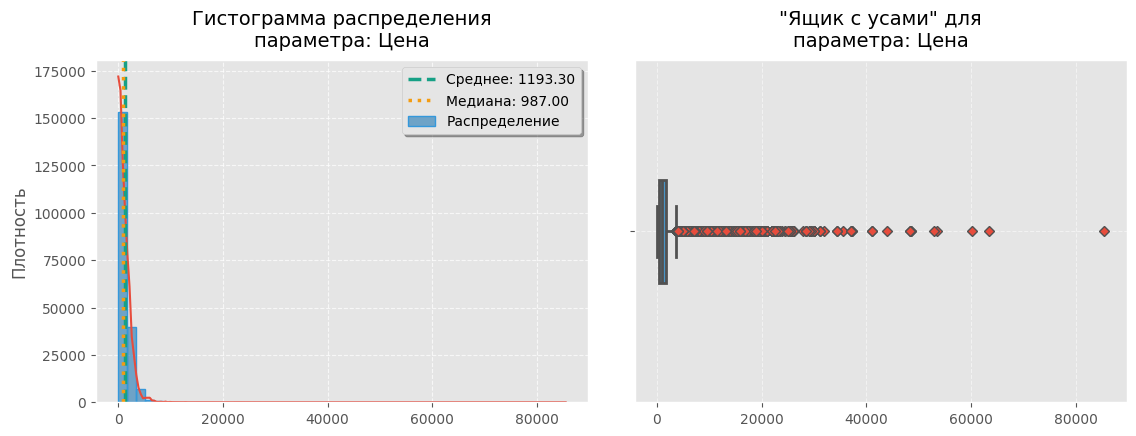


Межквартильный размах: 1347.000

Количество выбросов: 6589
Границы выбросов: [-1668.50, 3719.50]

Примеры выбросов:
2     6499.00
3     4999.00
4     4999.00
47    3999.00
111   3999.00
115   5999.00
198   3899.00
215   4499.00
238   7999.00
255   3999.00
Name: price, dtype: float64


(np.float64(-1668.5), np.float64(3719.5))

In [35]:
analyze_feature(df_purchases, feature='price', rename_columns = {'price':'Цена'})

In [36]:
mask = df_purchases['price'] >= 30000

In [37]:
df_purchases[mask]

,client_id,quantity,price,category_ids,purchase_date,message_id
6018,1515915625692218402,1,48499.00,"['4', '29', '312', '1576']",2022-06-01,1515915625489907961-4679-62972222453b3
70064,1515915625490563372,1,31999.00,"['4', '29', '312', '1576']",2022-12-20,1515915625490563372-8813-63a1acf4d6e83
138818,1515915625971673322,1,53499.00,"['4', '29', '310', '1577']",2023-06-13,1515915625971673322-13342-648873c693815
151607,1515915625487894579,1,31080.00,"['4', '29', '310', '1577']",2023-07-03,1515915625487894579-13427-649e839ea11d7
151608,1515915625487894579,1,31080.00,"['4', '29', '310', '1577']",2023-07-03,1515915625487894579-13427-649e839ea11d7
166576,1515915625776653984,1,63499.00,"['4', '29', '310', '1577']",2023-08-26,1515915625776653984-13719-64e85f9332bc8
166577,1515915625776653984,1,35559.00,"['4', '29', '310', '1577']",2023-08-26,1515915625776653984-13719-64e85f9332bc8
166578,1515915625776653984,1,60200.00,"['4', '29', '310', '1577']",2023-08-26,1515915625776653984-13719-64e85f9332bc8
171434,1515915625959777467,1,43999.00,"['4', '29', '313', '1574']",2023-09-27,1515915625959777467-13868-6513cbb257da6
171435,1515915625959777467,1,48499.00,"['4', '29', '313', '1574']",2023-09-27,1515915625959777467-13868-6513cbb257da6


In [38]:
df_purchases[mask].describe()

,quantity,price,purchase_date
count,22.00,22.00,22
mean,1.00,44672.95,2023-09-26 19:38:10.909091
min,1.00,31080.00,2022-06-01 00:00:00
25%,1.00,35919.00,2023-08-26 00:00:00
50%,1.00,41160.00,2023-11-08 00:00:00
75%,1.00,48499.00,2023-12-24 00:00:00
max,1.00,85499.00,2024-02-14 00:00:00
std,0.00,12981.18,NaN


In [39]:
high_price_category_ids = set(tuple(lst) for lst in df_purchases[mask]['category_ids'])


In [40]:
mask = df_purchases['category_ids'].apply(
    lambda cat_list: tuple(cat_list) in high_price_category_ids
)

In [41]:
df_purchases[mask].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,quantity,price,purchase_date
count,240.00,240.00,240
mean,1.00,17523.19,2023-08-31 18:24:00
min,1.00,1.00,2022-06-01 00:00:00
25%,1.00,9999.00,2023-06-14 18:00:00
50%,1.00,15499.00,2023-10-19 00:00:00
75%,1.00,21000.00,2023-12-26 12:00:00
90%,1.00,29963.90,2024-01-30 00:00:00
95%,1.00,37436.00,2024-02-13 01:12:00
99%,1.00,57586.61,2024-02-14 00:00:00
max,1.00,85499.00,2024-02-14 00:00:00


##### Выводы

- Распределение с сильной левой ассиметрией что характерно для данного параметра (в магазине всегда будут редкие товары с высокой стоимостью)
- Основная часть данных располагается в райлне медианы 987 ед.
- Очень высокое стандартное отклонение 1342,25 указывает на большой разброс стоимости товаров
- мнимальная цена равна 1 ед. - возможно ошибка или акция 


**Выбросы**

Мы зафиксировали 6589 значений выбросов  с границей от 0 до 3720 ед
максимальная стоимость товаров - 85499. такие товары могут относиться к категории премиум категории, например брендовые вещи
Можно заметить что все товары преимум сегмента относяться к категории [4,29,310-313, 1574-1577]


**Рекомендации**
При агрегации данных нужно будет учесть дату последней покупки общую стоимость и общее количество купленых товаров, любимцю категорию товаров
выбросы удаять не будем так как данные могут представлять реальные значения цены и их удаление приведет к потере информации об акционных товарах и товарах премиум сегмента

#### Анализ параметра `client_id` - id клиента 

In [42]:
total_purchases = df_purchases.shape[0]
print(f'общее количество покупок: {total_purchases}')

unique_client = df_purchases['client_id'].nunique()
print(f'количество уникальных клиентов: {unique_client}')

print(f'Среднее количество покупок на клиента: {total_purchases/unique_client:.2f}')

общее количество покупок: 202208
количество уникальных клиентов: 49849
Среднее количество покупок на клиента: 4.06


In [43]:
purchases_per_client = df_purchases.groupby('client_id').size().reset_index(name='purchase_count')
print(purchases_per_client['purchase_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count   49849.00
mean        4.06
std         5.52
min         1.00
25%         1.00
50%         2.00
75%         5.00
90%         8.00
95%        12.00
99%        25.00
max       346.00
Name: purchase_count, dtype: float64


##### Топ-20 самых активных клиентов

In [44]:
print(purchases_per_client.sort_values('purchase_count', ascending=False).head(20))

                 client_id  purchase_count
44817  1515915625853312319             346
36600  1515915625624308268             218
35816  1515915625607113301             210
18479  1515915625500232103             131
2879   1515915625470860261             131
17169  1515915625491750681             121
13552  1515915625490352441             111
33360  1515915625586493853             107
28053  1515915625559931867             103
5782   1515915625487144079              98
7236   1515915625488041632              96
17722  1515915625491913953              91
25202  1515915625557342756              89
2893   1515915625470883759              87
4441   1515915625475422624              86
11573  1515915625489646733              83
38996  1515915625666901395              82
46374  1515915625912328708              81
26011  1515915625558691508              77
33455  1515915625586986524              77


##### Распределения покупок по клиентам

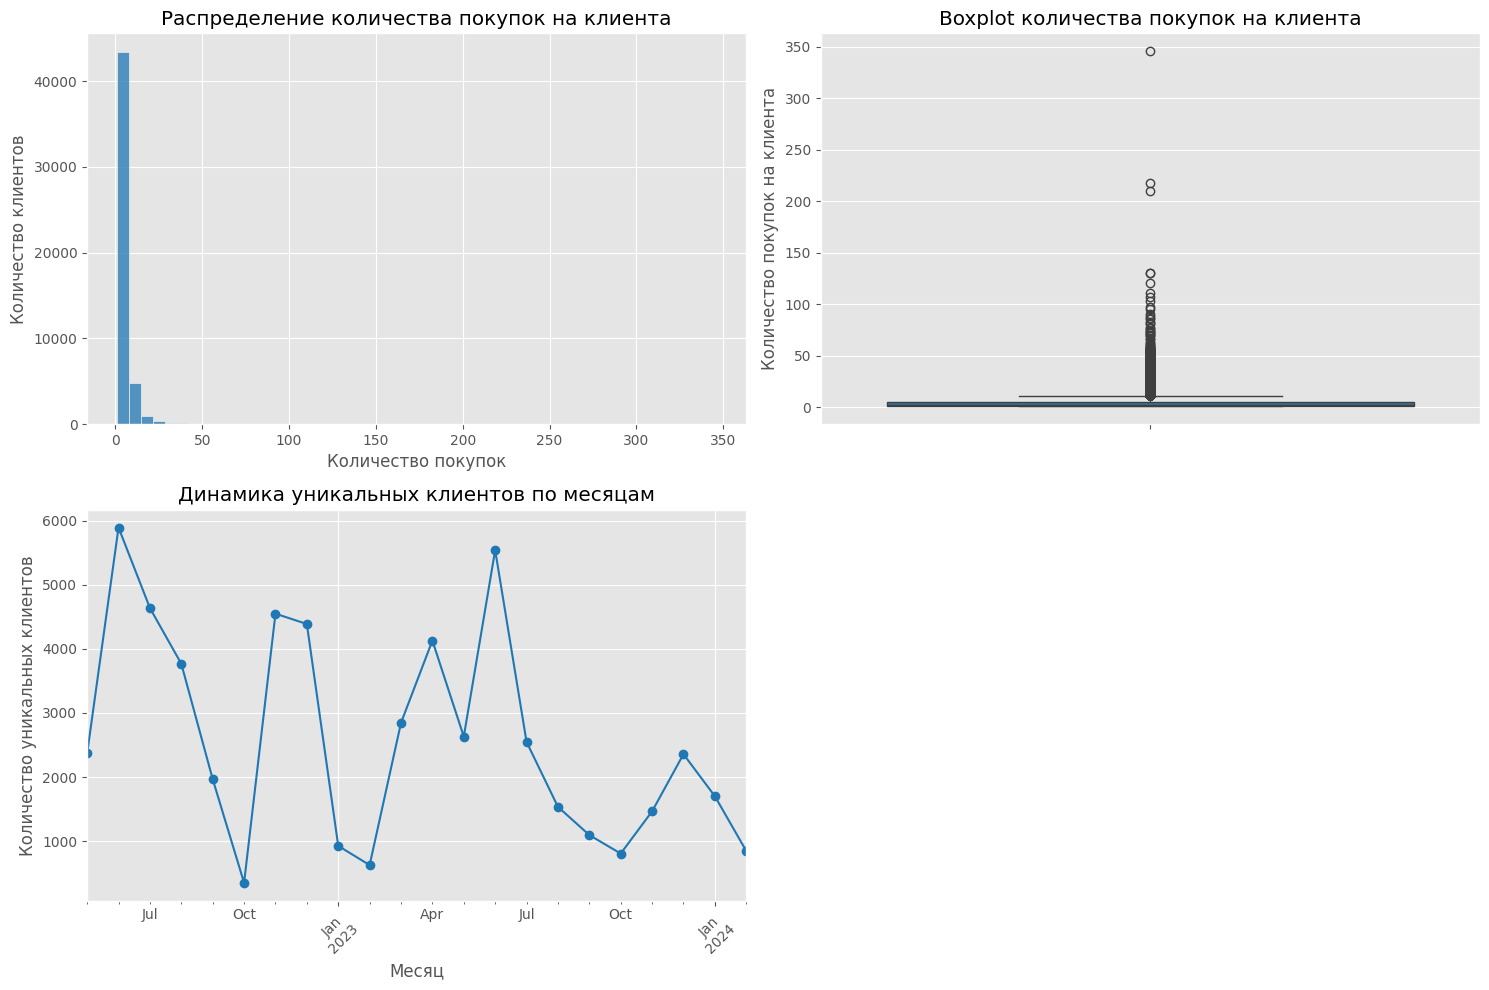

In [45]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(data=purchases_per_client, x='purchase_count', bins=50)
plt.title('Распределение количества покупок на клиента')
plt.xlabel('Количество покупок')
plt.ylabel('Количество клиентов')


plt.subplot(2, 2, 2)
sns.boxplot(y=purchases_per_client['purchase_count'])
plt.title('Boxplot количества покупок на клиента')
plt.ylabel('Количество покупок на клиента')

df_purchases['month'] = df_purchases['purchase_date'].dt.to_period('M')
clients_by_month = df_purchases.groupby('month')['client_id'].nunique()

plt.subplot(2, 2, 3)
clients_by_month.plot(kind='line', marker='o')
plt.title('Динамика уникальных клиентов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество уникальных клиентов')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [46]:
df_purchases = df_purchases.drop(columns=['month'])

#### Выводы

- общее количество покупок 202 208
- количество уникальных клиентов 49 849
- среднее количество покупок на 1 клиентв 4,06 но медианное количество 2
- высокое стандартное отклонение 5,52  говорит о значительном непостоянстве клиентов

**Распределение покупок**  

- Распределение неравномерное
- четверть клиентов совершает только одну покупку
- половина клиентов не более 2 покупок
- 3/4 клиентов совершают до 5 покупок
- 10% наиболее активных клиентов совершили 8 и более покупок
- 5% самых активных сделали более 12 покупок
- Самый активный клиент совершил 346 покупок 

Найдены топ 20 суперклиентов которые совершили от 77 до 346 покупок  
Эти клиенты требуют особого внимания со стороын магазина с точки зрения лояльности и персональных предложений

Активный период продаж с Марта по Июль и с ноября по Декабрь
Резкое снижение продаж с Августа по октябрь и с января по февраль
сезонные колебания могут быть вызваны спецификой товаров или маркетинговыми мероприятиями.

Необходимо провести доп анализ топ 20 клиентов для выявления закономерностей чтобы масштабировать это в дальнейшем.



### Пересечение клиентов

In [47]:
clients_purchases = df_purchases['client_id'].nunique()
clients_messages  = df_messages['client_id'].nunique()
clients_target    = df_target['client_id'].nunique()

In [48]:
print(f"Уникальных клиентов в покупках:  {clients_purchases:,}")
print(f"Уникальных клиентов в рассылках: {clients_messages:,}")
print(f"Уникальных клиентов в target:    {clients_target:,}")

Уникальных клиентов в покупках:  49,849
Уникальных клиентов в рассылках: 53,329
Уникальных клиентов в target:    49,849


#### Выводы

Не все клиенты которым отправлялись сообщения находятся в истории покупок и как следствии в df_target. Это холодные клиенты с которыми еще предстоит вести работу

### EDA `df_messages`

In [49]:
df_messages.shape[0]

12691188

In [50]:
df_messages.info()

<class 'pandas.DataFrame'>
Index: 12691188 entries, 0 to 12739797
Data columns (total 6 columns):
 #   Column              Dtype         
---  ------              -----         
 0   bulk_campaign_id    category      
 1   client_id           category      
 2   message_id          category      
 3   event               str           
 4   channel             str           
 5   message_created_at  datetime64[us]
dtypes: category(3), datetime64[us](1), str(2)
memory usage: 577.9 MB


In [51]:
top10_campaigns= df_messages.groupby('bulk_campaign_id')['event'].count().sort_values(ascending=False).head(10)
print('Топ-10 кампаний по количеству событий:')
print(top10_campaigns)

Топ-10 кампаний по количеству событий:
bulk_campaign_id
14272    104060
14276     63362
4679      50621
11760     45745
14081     44067
14623     44044
14515     43700
12218     40926
14352     39983
14356     38729
Name: event, dtype: int64


In [52]:
# распределение по каналам
counts = df_messages['channel'].value_counts()
pct = df_messages['channel'].value_counts(normalize=True) * 100
ch_dist = pd.DataFrame({
    'count': counts,
    'pct': pct.round(2) 
})

ch_dist

,count,pct
channel,,
mobile_push,7470472,58.86
email,5220716,41.14


In [53]:
# распределение событий

counts = df_messages['event'].value_counts()
pct = df_messages['event'].value_counts(normalize=True) * 100
event_dist = pd.DataFrame({
    'count': counts,
    'pct': pct.round(2) 
})

In [54]:
send = event_dist.loc['send', 'count'] if 'send' in event_dist.index else 0
open_ = event_dist.loc['open', 'count'] if 'open' in event_dist.index else 0
click = event_dist.loc['click', 'count'] if 'click' in event_dist.index else 0
purchase = event_dist.loc['purchase', 'count'] if 'purchase' in event_dist.index else 0

In [55]:
print(f'Распределение событий:\n{event_dist}')
separator()
print(f'\nОткрываемость сообщений: {open_ / send:.2%}')
print(f'Кликабельность: {click / open_:.2%}')
print(f'Конверсия клика в покупки: {purchase / click:.2%}')
print(f'Конверсия отправки сообщения в покупки: {purchase / send:.2%}')

Распределение событий:
               count   pct
event                     
send         9058174 71.37
open         3052481 24.05
click         483326  3.81
purchase       62593  0.49
hard_bounce    19763  0.16
soft_bounce    10582  0.08
unsubscribe     2833  0.02
hbq_spam         823  0.01
complain         527  0.00
subscribe         85  0.00
close              1  0.00

Открываемость сообщений: 33.70%
Кликабельность: 15.83%
Конверсия клика в покупки: 12.95%
Конверсия отправки сообщения в покупки: 0.69%


In [56]:
print('Конверсия по каналам:')
for ch in ['email', 'mobile_push']:
    sub = df_messages[df_messages['channel'] == ch]
    s = (sub['event'] == 'send').sum()
    o = (sub['event'] == 'open').sum()
    c = (sub['event'] == 'click').sum()
    p = (sub['event'] == 'purchase').sum()
    print(f'\n{ch}:')
    separator(sep='*', n=34)
    print(f'открываемость сообщений : {o/s:.2%}')
    print(f'Кликабельность: {c/o:.2%}')
    print(f'Конверсия клика в покупки: {p/c:.2%}')
    print(f'Конверсия отправки сообщения в покупки: {p/s:.2%}')

Конверсия по каналам:

email:
**********************************
открываемость сообщений : 22.18%
Кликабельность: 40.31%
Конверсия клика в покупки: 12.56%
Конверсия отправки сообщения в покупки: 1.12%

mobile_push:
**********************************
открываемость сообщений : 42.56%
Кликабельность: 6.03%
Конверсия клика в покупки: 13.99%
Конверсия отправки сообщения в покупки: 0.36%


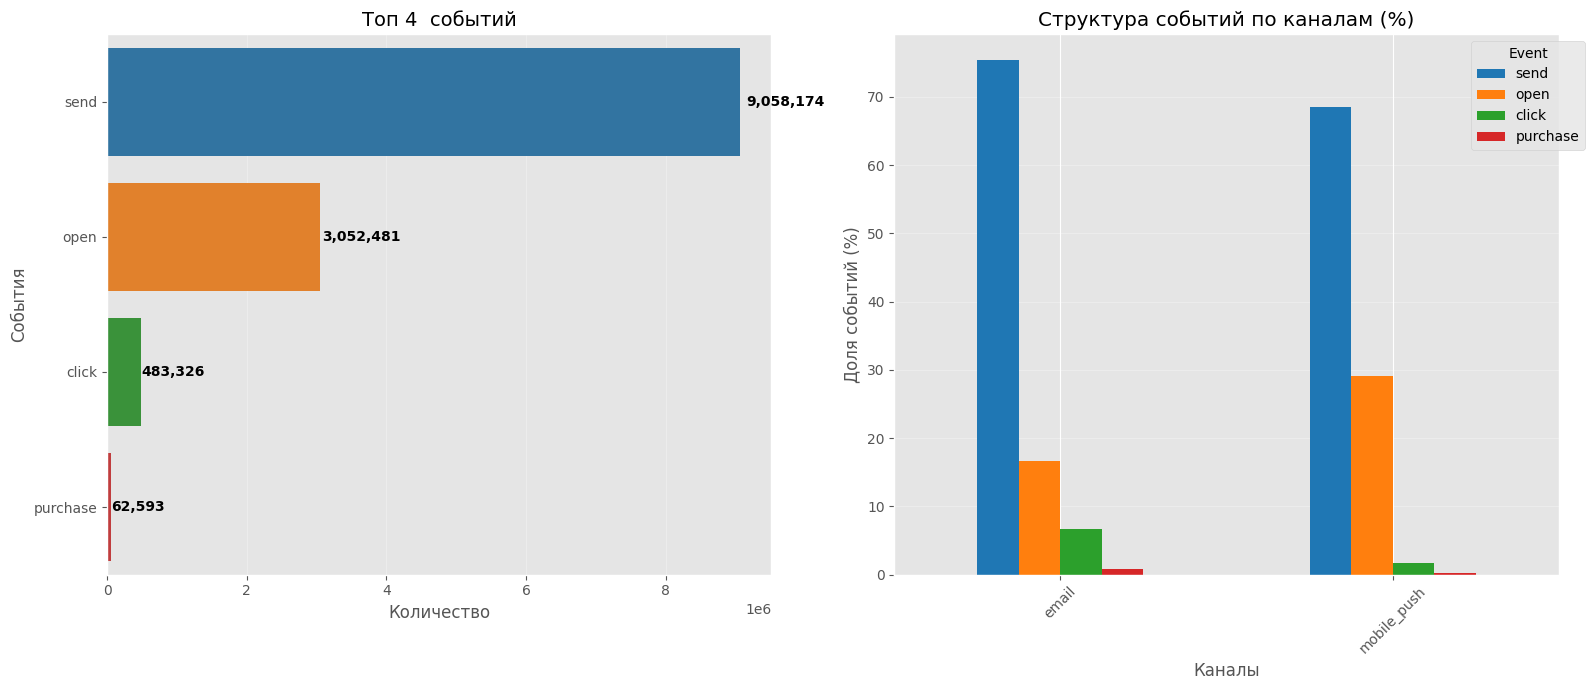

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
# топ 4 событий
top_events = event_dist.head(4)
sns.barplot(
    data=top_events.reset_index(),
    y='event',
    x='count',
    ax=ax[0],
    hue='event'
)
ax[0].set_title('Топ 4  событий', fontsize=14)
ax[0].set_xlabel('Количество')
ax[0].set_ylabel('События')
for i, v in enumerate(top_events['count']):
    ax[0].text(v * 1.01, i, f'{v:,}', va='center', fontsize=10, fontweight='bold')
ax[0].grid(True, axis='x', alpha=0.3)

# Доля событий по каналам
channel_event = pd.crosstab(df_messages['channel'], df_messages['event'], normalize='index') * 100
channel_event[['send', 'open', 'click', 'purchase']].plot(
    kind='bar',
    stacked=False,
    ax=ax[1])
ax[1].set_title('Структура событий по каналам (%)')
ax[1].set_xlabel('Каналы')
ax[1].set_ylabel('Доля событий (%)')
ax[1].legend(title='Event', bbox_to_anchor=(1.05, 1))
ax[1].grid(True, axis='y', alpha=0.3)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#### Выводы

Очень много рассылок, более 71% от всех событий  
средняя открываемость - 34%, но затем воронка резко сужается, что очень характерно для массовых рассылок  
Конверсия открытия в клик хорошая. Кликабельность до 16%.  
Воронка очень широкая в начале но потом сильно сужается.  
Только небольшая часть доходит до клика и совсем мало ведет к покупке.  
Итоговая конверсия отправки сообщения в покупку очень низкая 0,69%  

- `mobile_push` лучше привлекают внимание людей и быстрее доставляют сообщение чем `email`. Их чаще открывают почти в 2 раза чаще (42% открырий Vs email - 22%)  но при этом      крайне низкая кликабельность.  
   Вероятно потому что push могут приходить не вовремя, например когда человек чем то занят. Часто рекламнные сообщения очищают не особо вчитываясь в них, особенно если их приходит слишком много.
- `email` канал показывает лучшую кликабельность (40% vs push - 6 %)
   Когда разбирают почту у пользователей больше свободного времени. В письме можно лучше и красочнее описать рекламируемый товар что может приводить к частому переходу по ссылке
Конверсия от клика в покупку у обоих каналов находиться в районе 13%
Но итоговая конверсия отправки сообщения в покупки у e-mail канала в 4 раза выше чем у push



**`push`** может отлично работать как напоминание о старте распродажи или акции  с дальнейшим направлением письма по **`e-mail`** с детальной информацией.



 

#### Анализ изменения ключевых признаков во времени

In [58]:
print('Минимальная дата:', df_messages['message_created_at'].min())
print('Максимальная дата:', df_messages['message_created_at'].max())

Минимальная дата: 2022-05-19 00:14:20
Максимальная дата: 2024-02-15 23:58:40


In [59]:
events_list= ['send', 'open', 'click', 'purchase']
df_msg_temp = df_messages[df_messages['event'].isin(events_list)]

In [60]:
df_msg_temp['hour'] = df_msg_temp['message_created_at'].dt.hour
df_msg_temp['day_of_week'] = df_msg_temp['message_created_at'].dt.dayofweek
df_msg_temp['year_month'] = df_msg_temp['message_created_at'].dt.to_period('M')

In [61]:
# свод по часам
hourly = df_msg_temp.groupby(['event', 'hour']).size().unstack(fill_value=0)
# свод по дням недели
weekly = df_msg_temp.groupby(['event', 'day_of_week']).size().unstack(fill_value=0)
# свод по году и месяцу
monthly = df_msg_temp.groupby(['event', 'year_month']).size().unstack(fill_value=0)

In [62]:
monthly = monthly.sort_index(axis=1)

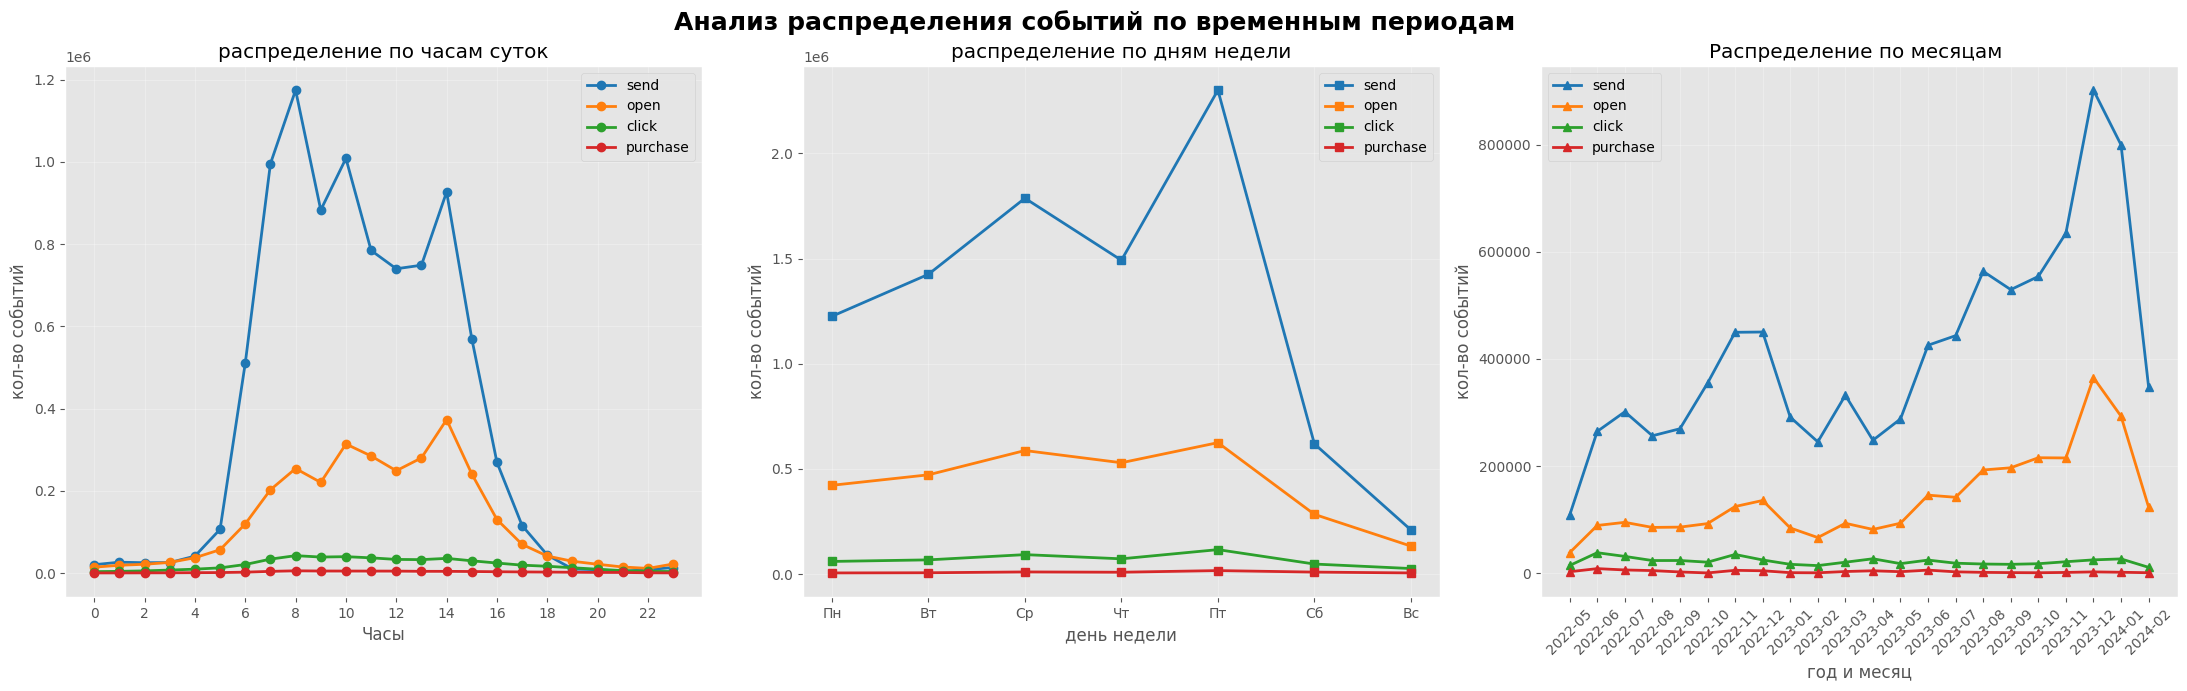

In [63]:
fig, ax = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Анализ распределения событий по временным периодам', fontsize=18, fontweight='bold', y=0.98)

days_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']


# распределение по часам суток
for i, event in enumerate(events_list):
    ax[0].plot(hourly.columns, hourly.loc[event],
                label=event, marker='o', linewidth=2, 
                )
ax[0].set_title('распределение по часам суток')
ax[0].set_xlabel('Часы')
ax[0].set_ylabel('кол-во событий')
ax[0].grid(True, alpha=0.3)
ax[0].set_xticks(range(0, 24, 2))
ax[0].legend()

# по дням недели
for i, event in enumerate(events_list):
    ax[1].plot(weekly.columns, weekly.loc[event],
                label=event, marker='s', linewidth=2
                )
ax[1].set_title('распределение по дням недели')
ax[1].set_xlabel('день недели')
ax[1].set_ylabel('кол-во событий')
ax[1].grid(True, alpha=0.3)
ax[1].set_xticks(weekly.columns)
ax[1].set_xticklabels(days_names)
ax[1].legend()

# распределение по месяцам 
for i, event in enumerate(events_list):
    data_sorted = monthly.loc[event].sort_index()
    ax[2].plot(data_sorted.index.astype(str), data_sorted.values,
                label=event, marker='^', linewidth=2
                )
ax[2].set_title('Распределение по месяцам ')
ax[2].set_xlabel('год и месяц')
ax[2].set_ylabel('кол-во событий')
ax[2].grid(True, alpha=0.3)
ax[2].tick_params(axis='x', rotation=45)
ax[2].legend()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

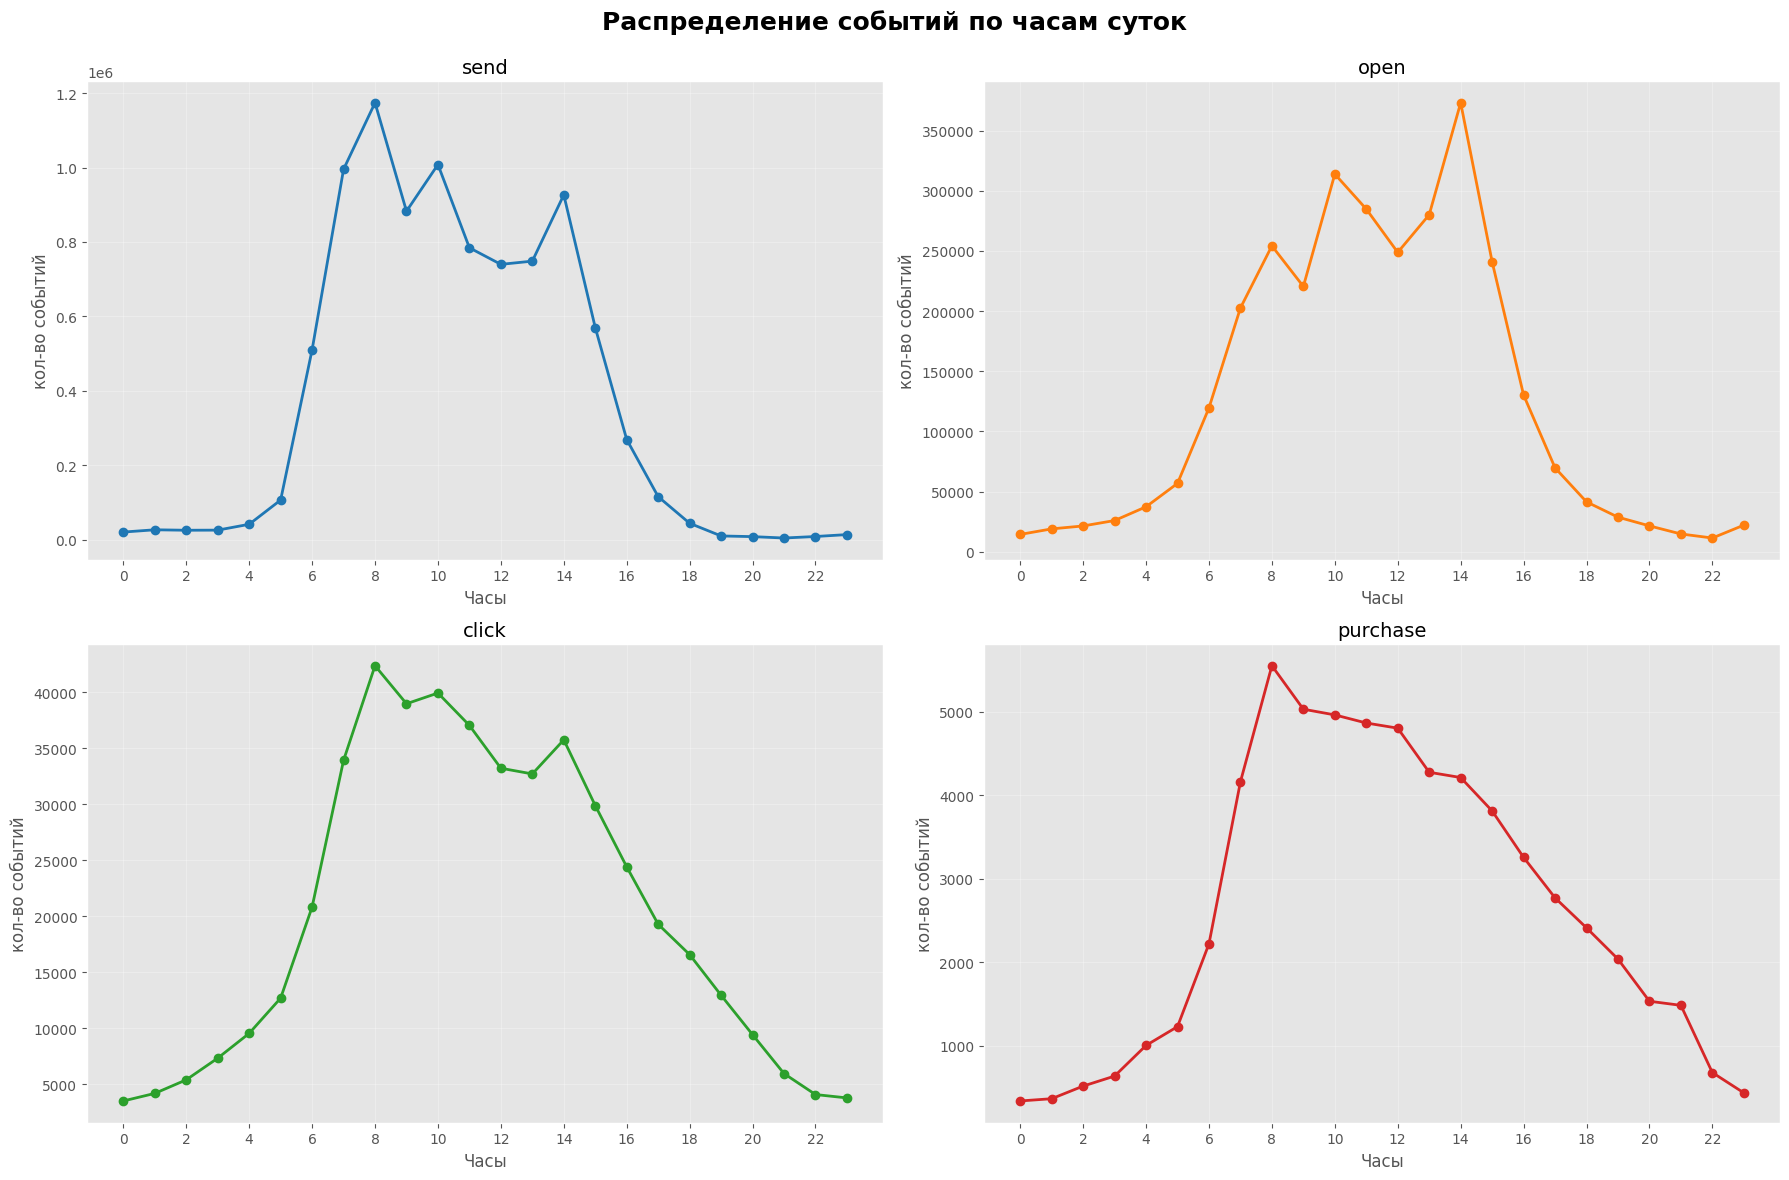

In [64]:
colors = sns.color_palette('tab10', len(events_list))
fig, ax = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Распределение событий по часам суток', fontsize=18, fontweight='bold', y=0.98)
for i, event in enumerate(events_list):
    row, col = i // 2, i % 2
    ax[row, col].plot(
        hourly.columns, 
        hourly.loc[event],
        marker='o', 
        linewidth=2,  
        color=colors[i]
    )
    ax[row, col].set_title(f'{event}', fontsize=14)
    ax[row, col].set_xlabel('Часы')
    ax[row, col].set_ylabel('кол-во событий')
    ax[row, col].grid(True, alpha=0.3)
    ax[row, col].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

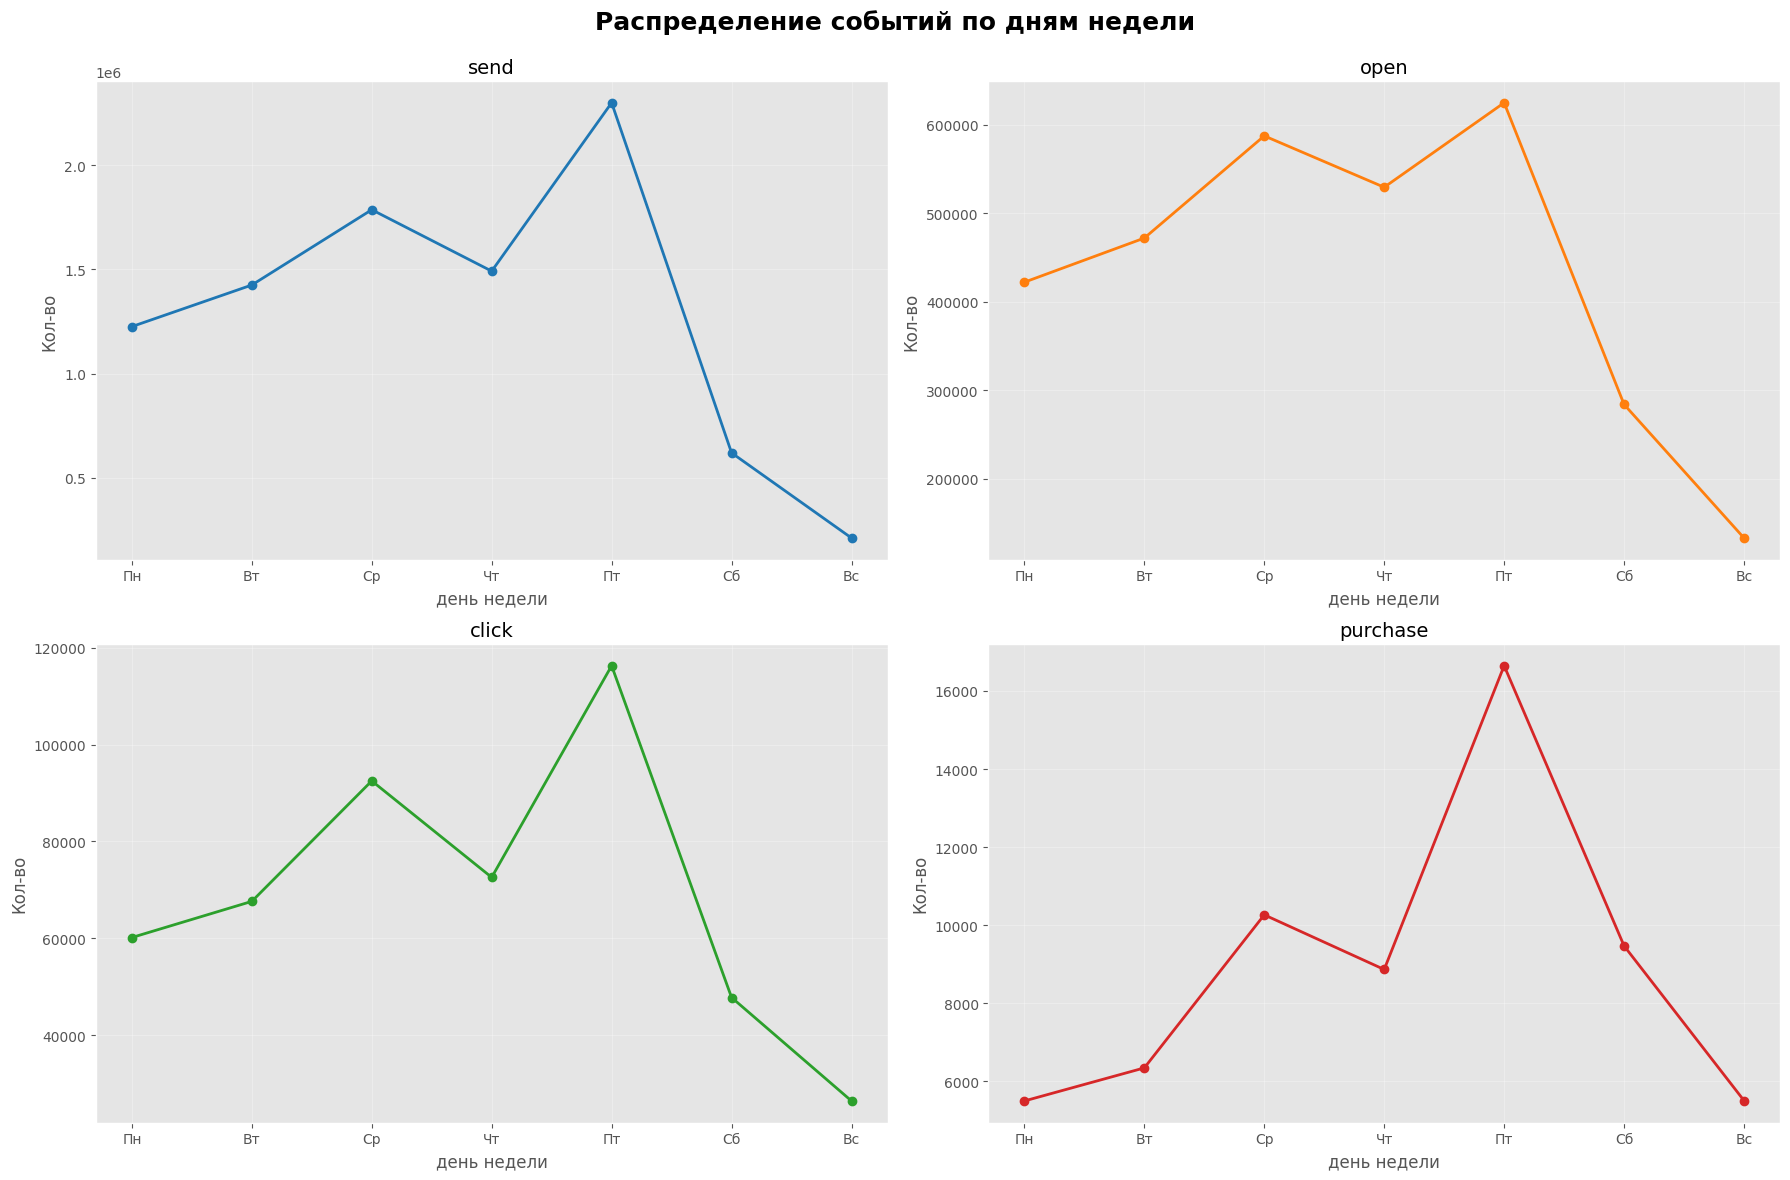

In [65]:
fig, ax = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Распределение событий по дням недели', fontsize=18, fontweight='bold', y=0.98)

for i, event in enumerate(events_list):
    row, col = i // 2, i % 2
    ax[row, col].plot(weekly.columns, weekly.loc[event],

                marker='o', 
                linewidth=2, 
                color=colors[i]
            )
    ax[row, col].set_title(f'{event}', fontsize=14)
    ax[row, col].set_xlabel('день недели')
    ax[row, col].set_ylabel('Кол-во')
    ax[row, col].grid(True, alpha=0.3)
    ax[row, col].set_xticks(weekly.columns)
    ax[row, col].set_xticklabels(days_names)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

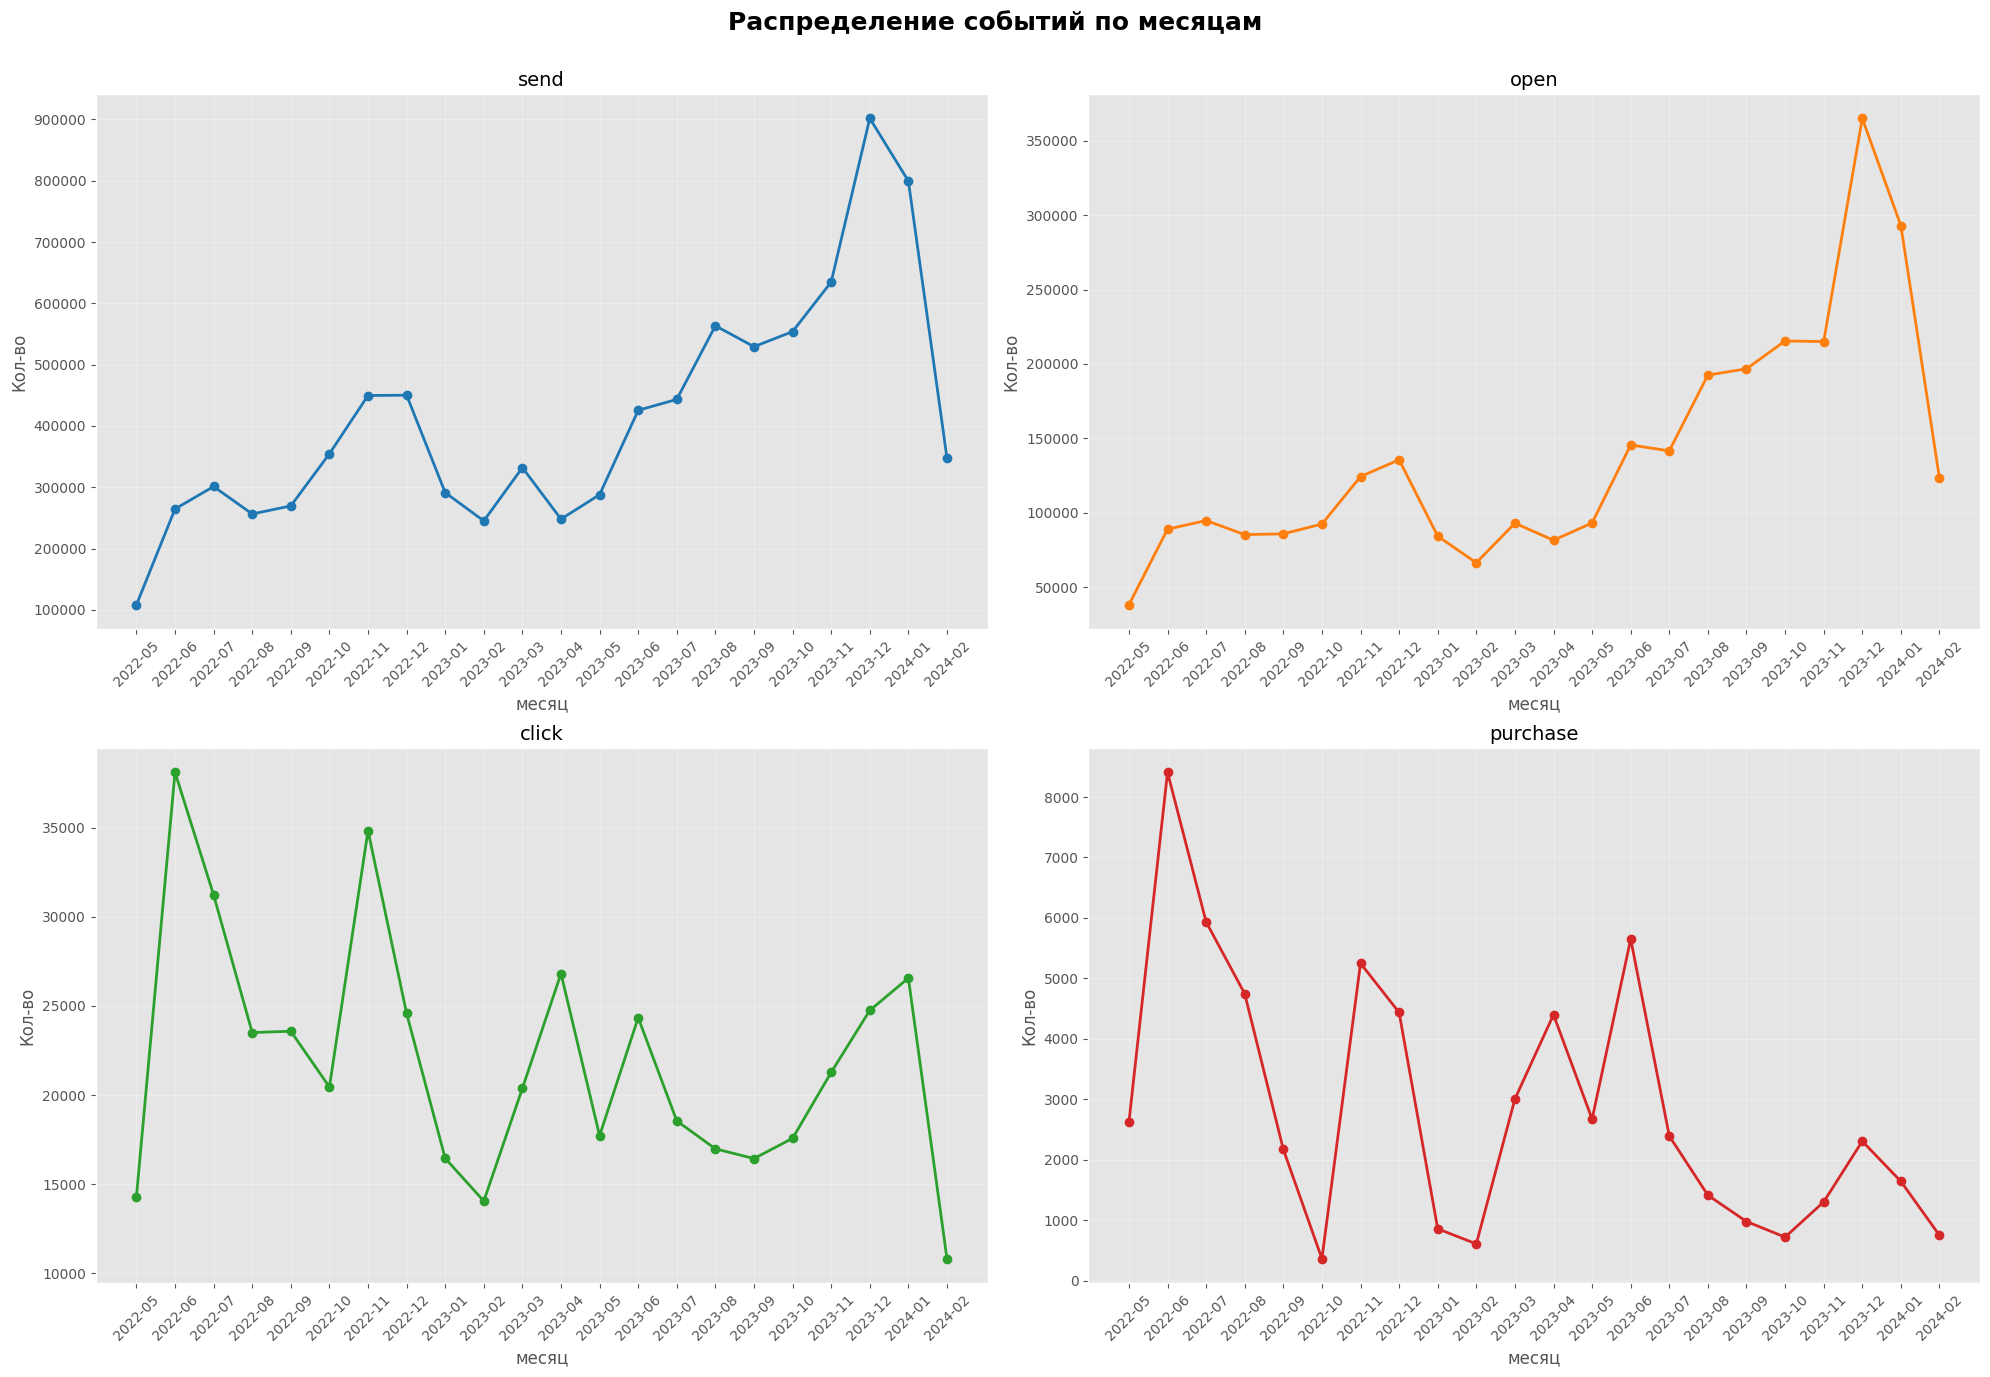

In [66]:
fig, ax = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Распределение событий по месяцам', fontsize=18, fontweight='bold', y=0.98)

for i, event in enumerate(events_list):
    row, col = i // 2, i % 2
    data_sorted = monthly.loc[event].sort_index()
    ax[row, col].plot(data_sorted.index.astype(str), data_sorted.values,
                        marker='o', linewidth=2, color=colors[i])
    ax[row, col].set_title(f'{event}', fontsize=14)
    ax[row, col].set_xlabel('месяц')
    ax[row, col].set_ylabel('Кол-во')
    ax[row, col].grid(True, alpha=0.3)
    ax[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


#### Выводы


**Распределение событий по часам**
- Пик отправки сообщений `send` приходиться в основном на утренние часы с 7 до 10 часов утра. повтрный пик  наблюдается в 14-00
- Пик открытия сообщений наоборот происходит с 14 до 15 часов
- график `сlick`  очень похож с `send`. заметна сильная корреляция 
с пиком в утренние часы 7-10 и вторым подъёмом около 14:00.
-  Пик `purchase` Приходиться на 8 утра. До 12 дня идет планое небольшое снижение.  После 12-00  количество покупок падает с каждым часом. минимум приходиться на период от 23-00 до 01-00 сдедующего дня.


**Распределение событий по дням недели**

По всем типам событий наблюдается одна картина. С понедельника по среду наблюдается рост. в четверг незначительное снижение, Пик всех событий приходиться на пятницу и затем резко падает до воскресенья

Покупки через рассылки лучше всего совершаются в пятницу

лучше снизить количество рассылок с субботы до понедельника включительно. очень низкая эффективность и риск получить сильное раздражение у потенциального покупателя на рекламу. или проводить точечные персональные рассылки ключевым клиентам.

**Распределение по месяцам**

- **send** сильный рост в течении всего 22 года, спад в январе феврале 23 года, небольшое восстановление в марте 23. в апреле снова снижение до уровня февраля. С начала мая до конца 23 года сильный рост с пиком в декабре, почти 900 тыс. отправок. в январе 24 снижение до 800 тыс. и резкий спад в феврале до 320-350 тыс.
- **open** - повторяет график `send` с пиком в декабре 23 года 360-370 тыс открытий
- **click** более неустойчивый график. много пиков и падений но в целом заметно снижение эффективности кликов по сравнению с ростом отправок с июня по октябрь 2023 года

не смотря на рост отправок количество кликов растет не так сильно как ожидается. это может говорить об усталости клиентов от постоянных рассылок.

- **purchase** самый нестабтльный график. Крупные пики - июнь 2022 года боле 8000 продаж, ноябрь-декабрь 22 года от 4 до 5 тыс продаж в месяц, возможно влияние распродаж черной пятницы и предновогодней распродажи, апрель 2023 года (4.2 - 4.4 тыс) и июнь 23 года (почти 600 продаж). затем резкое снижение продаж до октября 23 года, в ноябре и декабре 23 года небольшой рост, возможно снова влияние распродаж, затем снова падение.

Рост объема рассылок не привел к росту продаж конверсия в покупки падает с увеличением количества рассылок

Качество рассылок важнее количества 
Наиболее эффективными месяцами по покупкам являются апрель, май, июнь, ноябрь и декабрь.
Необходимо переходить от массовых рассылок к точечным, для клиентов готовых к покупкам



### EDA `df_target`

In [67]:
df_target.info()

<class 'pandas.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   client_id  49849 non-null  category
 1   target     49849 non-null  int64   
dtypes: category(1), int64(1)
memory usage: 973.7 KB


In [68]:
df_target.head()

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0


In [69]:
# распределение целевой переменной

counts = df_target['target'].value_counts()
pct = df_target['target'].value_counts(normalize=True) * 100
target_dist = pd.DataFrame({
    'count': counts,
    'pct': pct.round(2) 
})
target_dist

,count,pct
target,,
0,48888,98.07
1,961,1.93


#### Выводы

Очень сильный дисбаланс. Положительный класс менее 2 %. Может потребоваться oversampling

## Определение точки отсчета 

In [70]:
max_date = df_purchases['purchase_date'].max()
reference_point = max_date - pd.Timedelta(days=HORIZON)
print(f'Максимальная дата покупок: {max_date}')
print(f'Точка отсчета: {reference_point}')

Максимальная дата покупок: 2024-02-16 00:00:00
Точка отсчета: 2023-11-18 00:00:00


### Клиенты которые совершили покупку после точки отсчета

In [71]:
purchase_agg = df_purchases.groupby('client_id')['purchase_date'].agg([
    'min',  # первая покупка
    'max'   # последняя покупка
]).reset_index()
purchase_agg.columns = ['client_id', 'first_purchase_date', 'last_purchase_date']


In [72]:
purchase_agg['lifetime'] = (purchase_agg['last_purchase_date'] - purchase_agg['first_purchase_date']).dt.days

In [73]:
purchase_agg.head()

,client_id,first_purchase_date,last_purchase_date,lifetime
0,1515915625468060902,2022-05-27,2022-05-27,0
1,1515915625468061003,2023-01-04,2023-01-04,0
2,1515915625468061099,2022-05-17,2022-05-17,0
3,1515915625468061100,2024-02-10,2024-02-10,0
4,1515915625468061170,2023-03-26,2023-06-17,83


In [74]:
hist_clients = purchase_agg[purchase_agg['last_purchase_date'] < reference_point]['client_id'].values.tolist()
future_clients = purchase_agg[purchase_agg['last_purchase_date'] >= reference_point]['client_id'].values.tolist()
new_clients = purchase_agg[
    (purchase_agg['lifetime'] <= HORIZON) &
    (purchase_agg['last_purchase_date'] >= reference_point)
]['client_id'].values.tolist()

In [75]:
count_future = len(future_clients)
count_hist = len(hist_clients)
count_new = len(new_clients)    
all_clients = df_purchases.client_id.nunique()

print(f'Количество клиентов совершивших последнюю покупку до точки отсчета: {count_hist}')
print(f'Количество клиентов совершивших покупку после точки отсчета {count_future}')
print(f'Количество новых клиентов, совершивших первую покупку после точки отсчета : {count_new}')
print(f'Количество всех клиентов: {all_clients}')
print(f'Общая доля клиентов совершивших покупку после точки отсчета: {count_future/all_clients*100:.2f}%')
print(f'Общая доля новых клиентов: {count_new/all_clients*100:.2f}%')
print(f'доля новых клиентов совершивших первую покупку после ТО  относительно клиентов совершивших покупку после ТО: {count_new/count_future*100:.2f}%')

Количество клиентов совершивших последнюю покупку до точки отсчета: 44654
Количество клиентов совершивших покупку после точки отсчета 5195
Количество новых клиентов, совершивших первую покупку после точки отсчета : 4617
Количество всех клиентов: 49849
Общая доля клиентов совершивших покупку после точки отсчета: 10.42%
Общая доля новых клиентов: 9.26%
доля новых клиентов совершивших первую покупку после ТО  относительно клиентов совершивших покупку после ТО: 88.87%


#### Выводы


- Доля клиентов, совершивших покупку после точки отсчёта, — 10,42% (5195 из 49849).
- Из них 88,87% (4617) — **новые клиенты**, а 11.13% — **действующие**, вернувшиеся за повторной покупкой.
- 89,58% клиентов (44654) совершали покупки 90 дней назад и более

1. Продажи после точки отсчёта в основном даржаться на новых клиентах, которые не совершали покупки раньше.
2. Можно заметить низкую воволеченность текущей базы клиентов. Большинство клиентов неактивны в течении 3 месяцев.

Работа с неактивными клиентами может заметно увеличить продажи без привлечения новой аудитории.

## Создание новых признаков

### Фильруем датасеты до точки отсчета

In [76]:
reference_point

Timestamp('2023-11-18 00:00:00')

In [77]:
time_mask = df_purchases['purchase_date'] < reference_point
filt_purch = df_purchases[time_mask]

In [78]:
filt_purch.describe()

,quantity,price,purchase_date
count,179434.00,179434.00,179434
mean,1.01,1195.22,2023-02-07 19:10:34.675702
min,1.00,1.00,2022-05-16 00:00:00
25%,1.00,399.00,2022-11-11 00:00:00
50%,1.00,999.00,2023-03-06 00:00:00
75%,1.00,1699.00,2023-06-10 00:00:00
max,30.00,63499.00,2023-11-17 00:00:00
std,0.19,1234.49,NaN


In [79]:
time_mask = df_messages['message_created_at'] <= reference_point
filt_msg = df_messages[time_mask]

In [80]:
filt_msg.describe()

,message_created_at
count,9424022
mean,2023-03-23 20:52:01.988888
min,2022-05-19 00:14:20
25%,2022-11-10 00:13:00.750000
50%,2023-04-12 17:53:11
75%,2023-08-19 08:13:42
max,2023-11-17 23:59:02


### Создание признаков из данных о покупках `filt_purch`

In [81]:
filt_purch.head(2)

,client_id,quantity,price,category_ids,purchase_date,message_id
0,1515915625468169594,1,1999.00,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.00,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d


In [82]:
type(filt_purch['category_ids'][0])

str

####  Выделение категорий из `filt_purch['category_ids']`

In [83]:
def category_ids_tolist(value):
    if pd.isna(value) or value == '':
        return []
    try:
        parsed = ast.literal_eval(value)
        if not isinstance(parsed, list):
            return [] 
        return parsed
    except (ValueError, SyntaxError) as e:
        return []

In [84]:
filt_purch['category_ids'] = filt_purch['category_ids'].apply(category_ids_tolist)

In [85]:
type(filt_purch['category_ids'][0])

list

In [86]:
filt_purch['cat_1'] = filt_purch['category_ids'].str[0]
filt_purch['cat_2'] = filt_purch['category_ids'].str[1]
filt_purch['cat_3'] = filt_purch['category_ids'].str[2]
filt_purch['cat_4'] = filt_purch['category_ids'].str[3]

In [87]:
cols = ['cat_1', 'cat_2', 'cat_3', 'cat_4']
fill_values = {'cat_1': 'unknown_cat_1', 'cat_2': 'unknown_cat_2', 'cat_3': 'unknown_cat_3', 'cat_4': 'unknown_cat_4'}

filt_purch.loc[:, cols] = filt_purch[cols].fillna(fill_values)

In [88]:
filt_purch[['cat_1', 'cat_2', 'cat_3', 'cat_4']] = filt_purch[['cat_1', 'cat_2', 'cat_3', 'cat_4']].astype('category')

In [89]:
filt_purch.drop(columns=['category_ids'], inplace=True)

In [90]:
filt_purch.head()

,client_id,quantity,price,purchase_date,message_id,cat_1,cat_2,cat_3,cat_4
0,1515915625468169594,1,1999.00,2022-05-16,1515915625468169594-4301-627b661e9736d,4,28,57,431
1,1515915625468169594,1,2499.00,2022-05-16,1515915625468169594-4301-627b661e9736d,4,28,57,431
2,1515915625471138230,1,6499.00,2022-05-16,1515915625471138230-4437-6282242f27843,4,28,57,431
3,1515915625471138230,1,4999.00,2022-05-16,1515915625471138230-4437-6282242f27843,4,28,244,432
4,1515915625471138230,1,4999.00,2022-05-16,1515915625471138230-4437-6282242f27843,4,28,49,413


In [91]:
filt_purch.describe(include='category')

,client_id,message_id,cat_1,cat_2,cat_3,cat_4
count,179434,179434,179434,179434,179434,179434
unique,45277,45559,9,32,291,811
top,1515915625853312319,1515915625489095763-6251-6311b13a4cf78,4,28,57,431
freq,300,365,101451,73049,8490,8490


In [92]:
topcat1_list = filt_purch['cat_1'].value_counts().head(3).index.tolist()

In [93]:
topcat2_list=filt_purch['cat_2'].value_counts().head(3).index.tolist()

In [94]:
topcat3_list=filt_purch['cat_3'].value_counts().head(3).index.tolist()

In [95]:
topcat4_list=filt_purch['cat_4'].value_counts().head(4).index.tolist()
topcat4_list.remove('unknown_cat_4')

In [96]:
# бинарный признак покупки в топ категории
filt_purch['top_cat1'] = filt_purch['cat_1'].isin(topcat1_list).astype(int)
filt_purch['top_cat2'] = filt_purch['cat_2'].isin(topcat2_list).astype(int)
filt_purch['top_cat3'] = filt_purch['cat_3'].isin(topcat3_list).astype(int)
filt_purch['top_cat4'] = filt_purch['cat_4'].isin(topcat4_list).astype(int)


In [97]:
filt_purch.info()

<class 'pandas.DataFrame'>
RangeIndex: 179434 entries, 0 to 179433
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   client_id      179434 non-null  category      
 1   quantity       179434 non-null  int64         
 2   price          179434 non-null  float64       
 3   purchase_date  179434 non-null  datetime64[us]
 4   message_id     179434 non-null  category      
 5   cat_1          179434 non-null  category      
 6   cat_2          179434 non-null  category      
 7   cat_3          179434 non-null  category      
 8   cat_4          179434 non-null  category      
 9   top_cat1       179434 non-null  int64         
 10  top_cat2       179434 non-null  int64         
 11  top_cat3       179434 non-null  int64         
 12  top_cat4       179434 non-null  int64         
dtypes: category(6), datetime64[us](1), float64(1), int64(5)
memory usage: 13.8 MB


#### Общая сумма покупки

In [98]:
filt_purch['amount'] = filt_purch['quantity'] * filt_purch['price']

#### Финансовые признаки

In [99]:
transaction = filt_purch.groupby('client_id').agg({
    'quantity': ['sum', 'mean', 'count'],  # общее кол-во товаров, среднее кол-во товаров за покупку, кол-во покупок
    'price': ['mean'],  # среднняя цена товара
    'amount': ['sum', 'mean']  # общая сумма, средний чек
}).round(2)

In [100]:
transaction.columns = [
    'total_items', 'avg_items_per_purchase', 'purchase_count',
    'avg_price',
    'total_spent', 'avg_amount'
]

In [101]:
transaction.sample(5)

,total_items,avg_items_per_purchase,purchase_count,avg_price,total_spent,avg_amount
client_id,,,,,,
1515915625703018231,4,1.00,4,1124.00,4496.00,1124.00
1515915625555577756,1,1.00,1,2499.00,2499.00,2499.00
1515915625486543072,1,1.00,1,1999.00,1999.00,1999.00
1515915625503576299,2,1.00,2,1399.00,2798.00,1399.00
1515915625567614488,4,1.00,4,559.00,2236.00,559.00


#### Дата последней покупки

In [102]:
last_purchase = filt_purch.groupby('client_id')['purchase_date'].max().reset_index()
last_purchase['days_without_purchases'] = (reference_point - last_purchase['purchase_date']).dt.days

In [103]:
last_purchase = last_purchase.drop('purchase_date', axis=1)

In [104]:
last_purchase.describe()

,days_without_purchases
count,45277.00
mean,308.10
std,158.33
min,1.00
25%,162.00
50%,327.00
75%,467.00
max,551.00


#### Признаки по категориям

In [105]:

def safe_mode(x):
    """Функция для безопасного получения моды"""
    mode_result = x.mode()
    if len(mode_result) > 0:
        return mode_result.iloc[0]
    else:
        return np.nan


In [106]:
# количество уникальных категорий купленых товаров, любимая категория  и количество покупок из топ категорий
cat_features = filt_purch.groupby('client_id').agg({
    'cat_1': ['nunique', safe_mode],
    'cat_2': ['nunique', safe_mode],
    'cat_3': ['nunique', safe_mode],
    'cat_4': ['nunique', safe_mode],
    'top_cat1': ['sum'],
    'top_cat2': ['sum'],
    'top_cat3': ['sum'],
    'top_cat4': ['sum']
})

In [107]:
cat_features.columns = [
    'cat_1_nunique', 'cat_1_pref',
    'cat_2_nunique', 'cat_2_pref', 
    'cat_3_nunique', 'cat_3_pref', 
    'cat_4_nunique', 'cat_4_pref',
    'top_cat1_count', 
    'top_cat2_count', 
    'top_cat3_count', 
    'top_cat4_count'
]

In [108]:
cat_features.info()

<class 'pandas.DataFrame'>
CategoricalIndex: 45277 entries, 1515915625468060902 to 1515915626002352167
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   cat_1_nunique   45277 non-null  int64   
 1   cat_1_pref      45277 non-null  category
 2   cat_2_nunique   45277 non-null  int64   
 3   cat_2_pref      45277 non-null  category
 4   cat_3_nunique   45277 non-null  int64   
 5   cat_3_pref      45277 non-null  category
 6   cat_4_nunique   45277 non-null  int64   
 7   cat_4_pref      45277 non-null  category
 8   top_cat1_count  45277 non-null  int64   
 9   top_cat2_count  45277 non-null  int64   
 10  top_cat3_count  45277 non-null  int64   
 11  top_cat4_count  45277 non-null  int64   
dtypes: category(4), int64(8)
memory usage: 4.6 MB


#### Признаки динамики покупок 

In [109]:
def create_last_features(df, days, prefix):
    last = df[df['purchase_date'] >= reference_point - pd.Timedelta(days=days)]
    df_features = last.groupby('client_id').agg({
        'quantity': 'sum',
        'amount': ['sum', 'count']
    })
    df_features.columns = [f'{prefix}_items', f'{prefix}_amount', f'{prefix}_purchases']
    df_features = df_features.fillna(0)
    return df_features

In [110]:
(reference_point - filt_purch['purchase_date'].min()).days

551

In [111]:
# создаем признаки активности за последние 30, 90  дней и за весь период
last_30 = create_last_features(filt_purch, 30, 'last30')
last_60 = create_last_features(filt_purch, 60, 'last60')
last_90 = create_last_features(filt_purch, 90, 'last90')


#### Объединение признаков

In [112]:
df_target.info()

<class 'pandas.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   client_id  49849 non-null  category
 1   target     49849 non-null  int64   
dtypes: category(1), int64(1)
memory usage: 973.7 KB


In [113]:
df_features = df_target.copy()

In [114]:
msg_pursh_list =[transaction, last_purchase, 
                 cat_features, last_30, last_60, last_90]


for df in msg_pursh_list:
    df_features = df_features.merge(df, on='client_id', how='left')


In [115]:
df_features.shape

(49849, 30)

In [116]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   client_id               49849 non-null  category
 1   target                  49849 non-null  int64   
 2   total_items             45277 non-null  float64 
 3   avg_items_per_purchase  45277 non-null  float64 
 4   purchase_count          45277 non-null  float64 
 5   avg_price               45277 non-null  float64 
 6   total_spent             45277 non-null  float64 
 7   avg_amount              45277 non-null  float64 
 8   days_without_purchases  45277 non-null  float64 
 9   cat_1_nunique           45277 non-null  float64 
 10  cat_1_pref              45277 non-null  category
 11  cat_2_nunique           45277 non-null  float64 
 12  cat_2_pref              45277 non-null  category
 13  cat_3_nunique           45277 non-null  float64 
 14  cat_3_pref              45277 non

In [117]:
df_features.describe().T

,count,mean,std,min,25%,50%,75%,max
target,49849.00,0.02,0.14,0.00,0.00,0.00,0.00,1.00
total_items,45277.00,3.99,5.44,1.00,1.00,2.00,4.00,303.00
avg_items_per_purchase,45277.00,1.01,0.17,1.00,1.00,1.00,1.00,19.00
purchase_count,45277.00,3.96,5.41,1.00,1.00,2.00,4.00,300.00
avg_price,45277.00,1479.56,1294.58,1.00,699.00,1260.43,1999.00,53499.00
total_spent,45277.00,4762.87,6522.21,1.00,1499.00,2897.00,5598.00,255012.00
avg_amount,45277.00,1490.38,1307.60,1.00,699.00,1266.00,1999.00,53499.00
days_without_purchases,45277.00,308.10,158.33,1.00,162.00,327.00,467.00,551.00
cat_1_nunique,45277.00,1.22,0.49,1.00,1.00,1.00,1.00,5.00
cat_2_nunique,45277.00,1.37,0.78,1.00,1.00,1.00,2.00,12.00


### Создание признаков из данных о сообщениях `filt_msg`

In [118]:
filt_msg.shape[0]

9424022

In [119]:
filt_msg.info()

<class 'pandas.DataFrame'>
Index: 9424022 entries, 0 to 9454321
Data columns (total 6 columns):
 #   Column              Dtype         
---  ------              -----         
 0   bulk_campaign_id    category      
 1   client_id           category      
 2   message_id          category      
 3   event               str           
 4   channel             str           
 5   message_created_at  datetime64[us]
dtypes: category(3), datetime64[us](1), str(2)
memory usage: 447.0 MB


In [120]:
filt_msg['event'].value_counts()

event
send           6743546
open           2183973
click           413477
purchase         57578
hard_bounce      15067
soft_bounce       6626
unsubscribe       2330
hbq_spam           820
complain           527
subscribe           77
close                1
Name: count, dtype: int64

In [121]:
filt_msg['channel'].value_counts()

channel
mobile_push    5004771
email          4419251
Name: count, dtype: int64

#### Простые агрегированные признаки

In [122]:
basic_msg_features = filt_msg.groupby('client_id').agg({
    'event': 'nunique',
    'bulk_campaign_id': 'nunique',
    'message_id': 'count'
}).round(2)

basic_msg_features.columns = [
    'unique_event',
    'unique_campaigns', 
    'total_messages'
]

#### Предпочитаемый канал связи

в отличие от открытия, клик требует дополнительного осознанного действия, именно поэтому будем считать клики в каждом канале, а открытия, особенно из Push уведомлений могут быть вообще случайными

In [123]:
clicks_only = filt_msg[filt_msg['event'] == 'click']
clicks_in_ch = clicks_only.groupby(['client_id', 'channel']).size().reset_index(name='click_count')

In [124]:
# Для каждого клиента находим канал с максимальным количеством кликов
pref_ch = clicks_in_ch.loc[
    clicks_in_ch.groupby('client_id')['click_count'].idxmax()
]
pref_ch = pref_ch[['client_id', 'channel']].rename(columns={'channel': 'preferred_channel'})


In [125]:
pref_ch.head(2)

,client_id,preferred_channel
0,1515915625468060902,email
1,1515915625468061003,email


#### Общее количество событий

In [126]:
def count_events_by_channel(df, channels=None, events=None, shift_days=None):
    """
    Создает сводную таблицу с количеством событий по client_id с фильтрацией по каналу и 
    возможностью выбора событий за определенный период времени
    """
    
    data = df.copy()
    
    # фильтруем по  окну
    if shift_days is not None:
        reference_date = data['message_created_at'].max()
        shift_start = reference_date - pd.Timedelta(days=shift_days)
        data = data[data['message_created_at'] >= shift_start]
    
    # фильтруем по каналам
    if channels is not None:
        if isinstance(channels, str):
            channels = [channels]
        data = data[data['channel'].isin(channels)]
        
        if len(channels) == 1:
            add_suffix = False
        else:
            add_suffix = True
    
    # фильтруем по событиям
    if events is not None:
        data = data[data['event'].isin(events)]
    
    # свод
    if len(data) > 0:
        pivot = pd.crosstab(data['client_id'], data['event']).astype(np.int32)
        
    else:
        pivot = pd.DataFrame()
    
    
    return pivot

In [127]:
def add_conversion(df, column_mapp=None):
    """
    функция для добавления метрик конверсии.
    """
    data = df.copy()

    if column_mapp is None:
        column_mapp = {} 
    
    # для получения названия колонок
    def col(standard_name):
        return column_mapp.get(standard_name, standard_name)
    

    if col('send') in data.columns and col('open') in data.columns:
        data['send_open_rate'] = data[col('open')] / data[col('send')].clip(lower=1)
    
    if col('open') in data.columns and col('click') in data.columns:
        data['click_open_rate'] = data[col('click')] / data[col('open')].clip(lower=1)
    
    if col('send') in data.columns and col('click') in data.columns:
        data['send_click_rate'] = data[col('click')] / data[col('send')].clip(lower=1)
    
    if col('click') in data.columns and col('purchase') in data.columns:
        data['click_purchase_rate'] = data[col('purchase')] / data[col('click')].clip(lower=1)
    
    return data

In [128]:
# Все события по всем каналам за все время
all_channels = count_events_by_channel(filt_msg)

In [129]:
all_channels = add_conversion(all_channels, column_mapp=None).round(2)

In [130]:
all_channels.columns = [f'total_{col}' for col in all_channels.columns]
        

In [131]:
all_channels.head(2)

,total_click,total_close,total_complain,total_hard_bounce,total_hbq_spam,total_open,total_purchase,total_send,total_soft_bounce,total_subscribe,total_unsubscribe,total_send_open_rate,total_click_open_rate,total_send_click_rate,total_click_purchase_rate
client_id,,,,,,,,,,,,,,,
1515915625468060902,8,0,0,0,0,29,5,107,0,0,0,0.27,0.28,0.07,0.62
1515915625468061003,4,0,0,0,0,4,1,138,0,0,0,0.03,1.00,0.03,0.25


In [132]:
## топ 4 события по email каналу за все время
top_events_email = count_events_by_channel(
    filt_msg,
    channels='email',
    events=['send', 'open', 'click', 'purchase'],
)

In [133]:
top_events_email = add_conversion(top_events_email).round(2)

In [134]:
top_events_email.columns = [f'email_{col}' for col in top_events_email.columns]

In [135]:
top_events_email.head(2)

,email_click,email_open,email_purchase,email_send,email_send_open_rate,email_click_open_rate,email_send_click_rate,email_click_purchase_rate
client_id,,,,,,,,
1515915625468060902,8,29,5,107,0.27,0.28,0.07,0.62
1515915625468061003,4,4,1,138,0.03,1.00,0.03,0.25


In [136]:
## топ 4 события по mobile_push  каналу за все время
top_events_mobile_push = count_events_by_channel(
    filt_msg,
    channels='mobile_push',
    events=['send', 'open', 'click', 'purchase'],
)

In [137]:
top_events_mobile_push = add_conversion(top_events_mobile_push).round(2)

In [138]:
top_events_mobile_push.columns = [f'push_{col}' for col in top_events_mobile_push.columns]

In [139]:
top_events_mobile_push.head(2)

,push_click,push_open,push_purchase,push_send,push_send_open_rate,push_click_open_rate,push_send_click_rate,push_click_purchase_rate
client_id,,,,,,,,
1515915625468061099,0,34,0,58,0.59,0.00,0.00,0.00
1515915625468061100,0,97,0,199,0.49,0.00,0.00,0.00


In [140]:
# топ 4 события за последние 30 дней
last_30d = count_events_by_channel(filt_msg,
                                   events=['send', 'open', 'click', 'purchase'],
                                   shift_days=30
                                   )


In [141]:
last_30d = add_conversion(last_30d).round(2)

In [142]:
last_30d.columns = [f'last_30d_{col}' for col in last_30d.columns]

In [143]:
last_30d.head(2)

,last_30d_click,last_30d_open,last_30d_purchase,last_30d_send,last_30d_send_open_rate,last_30d_click_open_rate,last_30d_send_click_rate,last_30d_click_purchase_rate
client_id,,,,,,,,
1515915625468060902,0,4,0,9,0.44,0.00,0.00,0.00
1515915625468061003,0,0,0,9,0.00,0.00,0.00,0.00


In [144]:
# топ 4 события за последние 60 дней
last_60d = count_events_by_channel(filt_msg,
                                   events=['send', 'open', 'click', 'purchase'],
                                   shift_days=60
                                   )


In [145]:
last_60d = add_conversion(last_60d).round(2)

In [146]:
last_60d.columns = [f'last_60d_{col}' for col in last_60d.columns]

In [147]:
last_60d.head(2)

,last_60d_click,last_60d_open,last_60d_purchase,last_60d_send,last_60d_send_open_rate,last_60d_click_open_rate,last_60d_send_click_rate,last_60d_click_purchase_rate
client_id,,,,,,,,
1515915625468060902,0,6,0,15,0.40,0.00,0.00,0.00
1515915625468061003,0,0,0,17,0.00,0.00,0.00,0.00


In [148]:
# топ 4 события за последние 90 дней
last_90d = count_events_by_channel(filt_msg,
                                   events=['send', 'open', 'click', 'purchase'],
                                   shift_days=90
                                   )


In [149]:
last_90d = add_conversion(last_90d).round(2)
last_90d.columns = [f'last_90d_{col}' for col in last_90d.columns]

In [150]:
last_90d.head(2)

,last_90d_click,last_90d_open,last_90d_purchase,last_90d_send,last_90d_send_open_rate,last_90d_click_open_rate,last_90d_send_click_rate,last_90d_click_purchase_rate
client_id,,,,,,,,
1515915625468060902,0,6,0,17,0.35,0.00,0.00,0.00
1515915625468061003,0,0,0,26,0.00,0.00,0.00,0.00


#### Количество дней с даты последнего события

In [151]:
events_list = ['click', 'open', 'purchase', 'send']
filtered_data = filt_msg[filt_msg['event'].isin(events_list)]

last_event_features = filtered_data.groupby(['client_id', 'event'])['message_created_at'].max().unstack()


ref_point_date = pd.Timestamp(reference_point).normalize()

for event in events_list:
    if event in last_event_features.columns:
        # normalize() убирает время из Timestamp
        last_event_features[f'days_since_{event}'] = (ref_point_date - last_event_features[event].dt.normalize()).dt.days


In [152]:
last_event_features = last_event_features.iloc[:, -4:]


In [153]:
max_days = (ref_point_date - filt_msg['message_created_at'].min().normalize()).days
missing_days = max_days + 1
missing_days

549

In [154]:
last_event_features = last_event_features.fillna(missing_days).astype(int)

In [155]:
last_event_features.sample(5)

event,days_since_click,days_since_open,days_since_purchase,days_since_send
client_id,,,,
1515915625483661663,533,3,533,1
1515915625490277997,8,1,333,1
1515915625775929681,549,30,549,1
1515915625489479735,309,309,309,110
1515915625843768077,171,59,171,1


#### Объединение признаков 

In [156]:
msg_f_list =[basic_msg_features,
            pref_ch,
            all_channels,
            top_events_email,
            top_events_mobile_push,
            last_30d,
            last_60d,
            last_90d,
            last_event_features,
]

for df in msg_f_list:
    df_features = df_features.merge(df, on='client_id', how='left')

## Датасет с итоговыми признаками

### Первичный осмотр

In [157]:
df_features. shape

(49849, 93)

In [158]:
df_features.head()

,client_id,target,total_items,avg_items_per_purchase,purchase_count,avg_price,total_spent,avg_amount,days_without_purchases,cat_1_nunique,cat_1_pref,cat_2_nunique,cat_2_pref,cat_3_nunique,cat_3_pref,cat_4_nunique,cat_4_pref,top_cat1_count,top_cat2_count,top_cat3_count,top_cat4_count,last30_items,last30_amount,last30_purchases,last60_items,last60_amount,last60_purchases,last90_items,last90_amount,last90_purchases,unique_event,unique_campaigns,total_messages,preferred_channel,total_click,total_close,total_complain,total_hard_bounce,total_hbq_spam,total_open,total_purchase,total_send,total_soft_bounce,total_subscribe,total_unsubscribe,total_send_open_rate,total_click_open_rate,total_send_click_rate,total_click_purchase_rate,email_click,email_open,email_purchase,email_send,email_send_open_rate,email_click_open_rate,email_send_click_rate,email_click_purchase_rate,push_click,push_open,push_purchase,push_send,push_send_open_rate,push_click_open_rate,push_send_click_rate,push_click_purchase_rate,last_30d_click,last_30d_open,last_30d_purchase,last_30d_send,last_30d_send_open_rate,last_30d_click_open_rate,last_30d_send_click_rate,last_30d_click_purchase_rate,last_60d_click,last_60d_open,last_60d_purchase,last_60d_send,last_60d_send_open_rate,last_60d_click_open_rate,last_60d_send_click_rate,last_60d_click_purchase_rate,last_90d_click,last_90d_open,last_90d_purchase,last_90d_send,last_90d_send_open_rate,last_90d_click_open_rate,last_90d_send_click_rate,last_90d_click_purchase_rate,days_since_click,days_since_open,days_since_purchase,days_since_send
0,1515915625468060902,0,7.00,1.00,7.00,999.00,6993.00,999.00,540.00,1.00,4,2.00,28,5.00,176,5.00,420,7.00,7.00,2.00,3.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,108.00,149.00,email,8.00,0.00,0.00,0.00,0.00,29.00,5.00,107.00,0.00,0.00,0.00,0.27,0.28,0.07,0.62,8.00,29.00,5.00,107.00,0.27,0.28,0.07,0.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,4.00,0.00,9.00,0.44,0.00,0.00,0.00,0.00,6.00,0.00,15.00,0.40,0.00,0.00,0.00,0.00,6.00,0.00,17.00,0.35,0.00,0.00,0.00,376.00,23.00,540.00,1.00
1,1515915625468061003,1,7.00,1.00,7.00,2319.29,16235.00,2319.29,318.00,1.00,4,1.00,28,1.00,249,1.00,615,7.00,7.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,138.00,147.00,email,4.00,0.00,0.00,0.00,0.00,4.00,1.00,138.00,0.00,0.00,0.00,0.03,1.00,0.03,0.25,4.00,4.00,1.00,138.00,0.03,1.00,0.03,0.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,9.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,26.00,0.00,0.00,0.00,0.00,186.00,186.00,318.00,1.00
2,1515915625468061099,0,1.00,1.00,1.00,299.00,299.00,299.00,550.00,1.00,4,1.00,28,1.00,290,1.00,424,1.00,1.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,187.00,247.00,email,8.00,0.00,0.00,2.00,0.00,50.00,0.00,187.00,0.00,0.00,0.00,0.27,0.16,0.04,0.00,8.00,16.00,0.00,129.00,0.12,0.50,0.06,0.00,0.00,34.00,0.00,58.00,0.59,0.00,0.00,0.00,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,10.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,19.00,0.05,1.00,0.05,0.00,82.00,82.00,549.00,1.00
3,1515915625468061100,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00,199.00,297.00,NaN,0.00,0.00,0.00,1.00,0.00,97.00,0.00,199.00,0.00,0.00,0.00,0.49,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,97.00,0.00,199.00,0.49,0.00,0.00,0.00,0.00,19.00,0.00,20.00,0.95,0.00,0.00,0.00,0.00,35.00,0.00,39.00,0.90,0.00,0.00,0.00,0.00,38.00,0.00,56.00,0.68,0.00,0.00,0.00,549.00,1.00,549.00,1.00
4,1515915625468061170,0,19.00,1.00,19.00,1768.47,33601.00,1768.47,154.00,3.00,4,3.00,28,4.00,260,4.00,420,17.00,17.00,12.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,135.00,178.00,email,16.00,0.00,0.00,0.00,0.00,24.00,3.00,135.00,0.00,0.00,0.00,0.18,0.67,0.12,0.19,16.00,18.00,3.00,127.00,0.14,0.89,0.13,0.19,0.00,6.00,0.00,8.00,0.75,0.00,0.00,0.00,1.00,7.00,0.00,16.00,0.44,0.14,0.06,0.00,1.00,7.00,0.00,25.00,0.28,0.14,0.04,0.00,1.00,8.00,0.00,30.00,0.27,0.12,0.03,0.00,28.00,3.00,154.00,1.00


In [159]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 93 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   client_id                     49849 non-null  object  
 1   target                        49849 non-null  int64   
 2   total_items                   45277 non-null  float64 
 3   avg_items_per_purchase        45277 non-null  float64 
 4   purchase_count                45277 non-null  float64 
 5   avg_price                     45277 non-null  float64 
 6   total_spent                   45277 non-null  float64 
 7   avg_amount                    45277 non-null  float64 
 8   days_without_purchases        45277 non-null  float64 
 9   cat_1_nunique                 45277 non-null  float64 
 10  cat_1_pref                    45277 non-null  category
 11  cat_2_nunique                 45277 non-null  float64 
 12  cat_2_pref                    45277 non-null  category
 1

In [160]:
# настройка для отображения всех строк 
pd.set_option('display.max_rows', None)

df_features.describe().T

,count,mean,std,min,25%,50%,75%,max
target,49849.00,0.02,0.14,0.00,0.00,0.00,0.00,1.00
total_items,45277.00,3.99,5.44,1.00,1.00,2.00,4.00,303.00
avg_items_per_purchase,45277.00,1.01,0.17,1.00,1.00,1.00,1.00,19.00
purchase_count,45277.00,3.96,5.41,1.00,1.00,2.00,4.00,300.00
avg_price,45277.00,1479.56,1294.58,1.00,699.00,1260.43,1999.00,53499.00
total_spent,45277.00,4762.87,6522.21,1.00,1499.00,2897.00,5598.00,255012.00
avg_amount,45277.00,1490.38,1307.60,1.00,699.00,1266.00,1999.00,53499.00
days_without_purchases,45277.00,308.10,158.33,1.00,162.00,327.00,467.00,551.00
cat_1_nunique,45277.00,1.22,0.49,1.00,1.00,1.00,1.00,5.00
cat_2_nunique,45277.00,1.37,0.78,1.00,1.00,1.00,2.00,12.00


In [161]:
pd.reset_option('display.max_rows')

In [162]:
df_features.describe(include=['object', 'category', 'str']).T

,count,unique,top,freq
client_id,49849,49849,1515915625468060902,1
cat_1_pref,45277,8,4,28072
cat_2_pref,45277,29,28,22008
cat_3_pref,45277,274,57,2446
cat_4_pref,45277,710,431,2820
preferred_channel,37064,2,email,26136


#### Выводы

**Результаы создания новых признаков**

1. Отфильтровал данные. Ограничил историю покупок и сообщений точкой отсчета чтобы избежать утечки
2. Преобразовал категории. выделил 4 уровня. заменил пропуски на unknown
3. Признаки на основе данных о покупках
   - Финансовые признаки (total_spent, avg_amount, purchase_count, avg_price) 
   - признак давности покупок - days_without_purchases
   - предпочтения клиентов (nunique и mode для каждого уровня категории)
   - признаки за периоды 30, 60 и 90 дней (сумма, кол-во, число покупок)
4. Признаки на основе данных о взаимодействии с клиентской базой
   - количество событий, кампаний, и сообщений, общие конверсии 
   - Предпочитаемый канал связи
   - общее количество событий  в разрезе каналов и их конверсии
   - количество событий за последние 30, 60 и 90 дней а так же конверсии событий
   - признаки давности событий

Всего создано 87 признаков
Все полученые прихнаки описывают основные аспекты поведения клиентов и могут повысить точность прогнозов

**Общая информация**

- Датасет содержит 49849 с записей и 89 признаков включая target и client_id
- Целевая переменная - target c долей положительных значений около 2 %

**Пропуски**

- Признаки за поледние 3, 60 и 90 дней содержат очень малое количество значений. Это может быть связано с тем что что у большинства клиентов не было покупок за этот период. Пропуски необходимо заполнить нулевыми значениями
- Параметры коммуникации, такие как `unique_event`, `unique_campaigns`, `total_messages`, `bulk_campaign_id` заполнены 41 из из почти 50 тыс значений
- Предпочитаемый канал связи `preferred_channel` - 37 тыс заполненных значений
- Метрики конверсий событий имеют заполненость в районе 37 тыс. значений
- основные финансовые признаки, такие как `total_items`, `purchase_count` и пр. имеют 45 тыс заполненых значений 

**Заметки**

 - **Длительные периоды без покупок** Среднее количество дней без покупок 308 а медиана достигает 327 дней. общий диапазон от 1 до 551 дня
 - Признаки `p_all_time_items`, `p_all_time_amount`, `p_all_time_purchases` являются полными дубликатами `total_items`, `total_spent`, `purchase_count`. их необходимо удалить

### Обработка пропусков

In [163]:
def analyze_missing_values(df, figsize=(8, 6), heatmap_cmap='viridis', visualisation = False):
    """
    Функция для анализа пропусков в датасете
    
    """
    def separator():
        print('\n' + '='*60 + '\n')

    def get_variable_name(variable):
        for key, value in globals().items():
            if value is variable:
                return key
        return None
         
    df_name = get_variable_name(df)
        
    df_missing = df.isnull()

    total_missing = df_missing.sum().sort_values(ascending=False)
    total_missing_pct = (df_missing.sum() / len(df)) * 100

    # статистика
    print(f"\nОбщая статистика пропусков для {df_name}:")
    separator()
    print(f'Всего пропусков: {df_missing.sum().sum()}')
    print(f'Процент пропусков: {df_missing.sum().sum() / df.size * 100:.2f}%')

    if total_missing.sum() > 0:
        print('\nПропуски по столбцам:')
        separator()
        print(pd.concat([total_missing, total_missing_pct], axis=1, 
                   keys=['Количество пропусков', 'Процент пропусков']))
        separator()
        print('\nСтроки с пропущенными данными')
        separator()
        rows_with_missing = df[df.isnull().any(axis=1)]
        display(rows_with_missing.head(10))
        separator()

  # строим heatmap
    if visualisation:
        plt.figure(figsize=figsize)
        plt.title(f'Карта пропусков в {df_name}', fontsize=16)
        sns.heatmap(
            df_missing,
            cmap=heatmap_cmap,
            cbar_kws={'label': 'Наличие пропусков'},
            yticklabels=False  # отключаем метки чтобы лучше читалось
        )
        plt.xlabel('Столбцы', fontsize=14)
        plt.ylabel('Строки', fontsize=14)
        plt.tight_layout()
        plt.show()




Общая статистика пропусков для df_features:


Всего пропусков: 1344515
Процент пропусков: 29.00%

Пропуски по столбцам:


                        Количество пропусков  Процент пропусков
last30_amount                          48492              97.28
last30_purchases                       48492              97.28
last30_items                           48492              97.28
last60_items                           47628              95.54
last60_purchases                       47628              95.54
...                                      ...                ...
days_without_purchases                  4572               9.17
top_cat3_count                          4572               9.17
top_cat4_count                          4572               9.17
target                                     0               0.00
client_id                                  0               0.00

[93 rows x 2 columns]



Строки с пропущенными данными




,client_id,target,total_items,avg_items_per_purchase,purchase_count,avg_price,total_spent,avg_amount,days_without_purchases,cat_1_nunique,cat_1_pref,cat_2_nunique,cat_2_pref,cat_3_nunique,cat_3_pref,cat_4_nunique,cat_4_pref,top_cat1_count,top_cat2_count,top_cat3_count,top_cat4_count,last30_items,last30_amount,last30_purchases,last60_items,last60_amount,last60_purchases,last90_items,last90_amount,last90_purchases,unique_event,unique_campaigns,total_messages,preferred_channel,total_click,total_close,total_complain,total_hard_bounce,total_hbq_spam,total_open,total_purchase,total_send,total_soft_bounce,total_subscribe,total_unsubscribe,total_send_open_rate,total_click_open_rate,total_send_click_rate,total_click_purchase_rate,email_click,email_open,email_purchase,email_send,email_send_open_rate,email_click_open_rate,email_send_click_rate,email_click_purchase_rate,push_click,push_open,push_purchase,push_send,push_send_open_rate,push_click_open_rate,push_send_click_rate,push_click_purchase_rate,last_30d_click,last_30d_open,last_30d_purchase,last_30d_send,last_30d_send_open_rate,last_30d_click_open_rate,last_30d_send_click_rate,last_30d_click_purchase_rate,last_60d_click,last_60d_open,last_60d_purchase,last_60d_send,last_60d_send_open_rate,last_60d_click_open_rate,last_60d_send_click_rate,last_60d_click_purchase_rate,last_90d_click,last_90d_open,last_90d_purchase,last_90d_send,last_90d_send_open_rate,last_90d_click_open_rate,last_90d_send_click_rate,last_90d_click_purchase_rate,days_since_click,days_since_open,days_since_purchase,days_since_send
0,1515915625468060902,0,7.00,1.00,7.00,999.00,6993.00,999.00,540.00,1.00,4,2.00,28,5.00,176,5.00,420,7.00,7.00,2.00,3.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,108.00,149.00,email,8.00,0.00,0.00,0.00,0.00,29.00,5.00,107.00,0.00,0.00,0.00,0.27,0.28,0.07,0.62,8.00,29.00,5.00,107.00,0.27,0.28,0.07,0.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,4.00,0.00,9.00,0.44,0.00,0.00,0.00,0.00,6.00,0.00,15.00,0.40,0.00,0.00,0.00,0.00,6.00,0.00,17.00,0.35,0.00,0.00,0.00,376.00,23.00,540.00,1.00
1,1515915625468061003,1,7.00,1.00,7.00,2319.29,16235.00,2319.29,318.00,1.00,4,1.00,28,1.00,249,1.00,615,7.00,7.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,138.00,147.00,email,4.00,0.00,0.00,0.00,0.00,4.00,1.00,138.00,0.00,0.00,0.00,0.03,1.00,0.03,0.25,4.00,4.00,1.00,138.00,0.03,1.00,0.03,0.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,9.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,26.00,0.00,0.00,0.00,0.00,186.00,186.00,318.00,1.00
2,1515915625468061099,0,1.00,1.00,1.00,299.00,299.00,299.00,550.00,1.00,4,1.00,28,1.00,290,1.00,424,1.00,1.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,187.00,247.00,email,8.00,0.00,0.00,2.00,0.00,50.00,0.00,187.00,0.00,0.00,0.00,0.27,0.16,0.04,0.00,8.00,16.00,0.00,129.00,0.12,0.50,0.06,0.00,0.00,34.00,0.00,58.00,0.59,0.00,0.00,0.00,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,10.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,19.00,0.05,1.00,0.05,0.00,82.00,82.00,549.00,1.00
3,1515915625468061100,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00,199.00,297.00,NaN,0.00,0.00,0.00,1.00,0.00,97.00,0.00,199.00,0.00,0.00,0.00,0.49,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,97.00,0.00,199.00,0.49,0.00,0.00,0.00,0.00,19.00,0.00,20.00,0.95,0.00,0.00,0.00,0.00,35.00,0.00,39.00,0.90,0.00,0.00,0.00,0.00,38.00,0.00,56.00,0.68,0.00,0.00,0.00,549.00,1.00,549.00,1.00
4,1515915625468061170,0,19.00,1.00,19.00,1768.47,33601.00,1768.47,154.00,3.00,4,3.00,28,4.00,260,4.00,420,17.00,17.00,12.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,135.00,178.00,email,16.00,0.00,0.00,0.00,0.00,24.00,3.00,135.00,0.00,0.00,0.00,0.18,0.67,0.12,0.19,16.00,18.00,3.00,127.00,0.14,0.89,0.13,0.19,0.00,6.00,0.00,8.00,0.75,0.00,0.00,0.00,1.00,7.00,0.00,16.00,0.44,0.14,0.06,0.00,1.00,7.00,0.00,25.00,0.28,0.14,0.04,0.00,1.00,8.00,0.00,30.00,0.27,0.12,0.03,0.00,28.00,3.00,154.00,1.00
5,1515915625468061

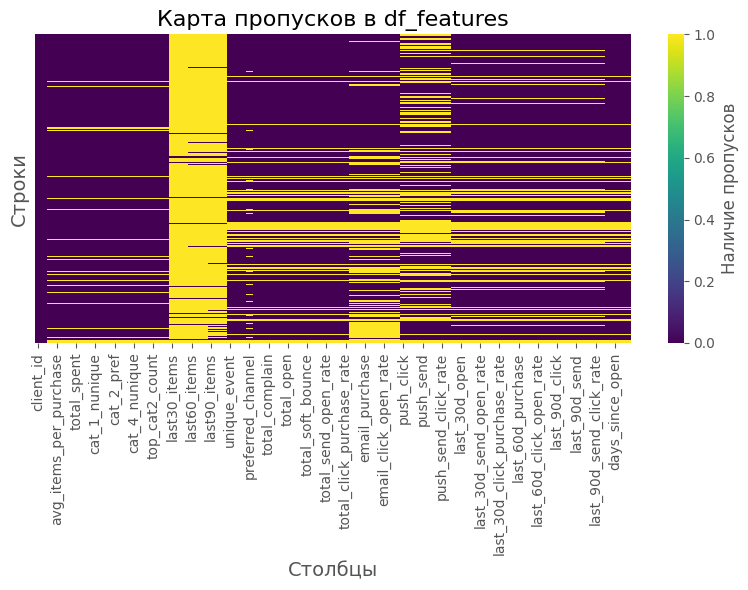

In [164]:
analyze_missing_values(df=df_features, visualisation=True)

In [165]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 93 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   client_id                     49849 non-null  object  
 1   target                        49849 non-null  int64   
 2   total_items                   45277 non-null  float64 
 3   avg_items_per_purchase        45277 non-null  float64 
 4   purchase_count                45277 non-null  float64 
 5   avg_price                     45277 non-null  float64 
 6   total_spent                   45277 non-null  float64 
 7   avg_amount                    45277 non-null  float64 
 8   days_without_purchases        45277 non-null  float64 
 9   cat_1_nunique                 45277 non-null  float64 
 10  cat_1_pref                    45277 non-null  category
 11  cat_2_nunique                 45277 non-null  float64 
 12  cat_2_pref                    45277 non-null  category
 1

In [166]:
days_cols = ['days_without_purchases', 'days_since_click', 'days_since_open', 'days_since_purchase', 'days_since_send'] 
        

num_cols = [
    col for col in df_features.columns
    if df_features[col].dtype == 'float64' and col not in (days_cols + ['client_id'])
]

str_cols = [
    col for col in df_features.columns
    if df_features[col].dtype =='str'
]

cat_cols = [
    col for col in df_features.columns
    if df_features[col].dtype =='category'
]



In [167]:
df_features[num_cols] = df_features[num_cols].fillna(0)


In [168]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 93 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   client_id                     49849 non-null  object  
 1   target                        49849 non-null  int64   
 2   total_items                   49849 non-null  float64 
 3   avg_items_per_purchase        49849 non-null  float64 
 4   purchase_count                49849 non-null  float64 
 5   avg_price                     49849 non-null  float64 
 6   total_spent                   49849 non-null  float64 
 7   avg_amount                    49849 non-null  float64 
 8   days_without_purchases        45277 non-null  float64 
 9   cat_1_nunique                 49849 non-null  float64 
 10  cat_1_pref                    45277 non-null  category
 11  cat_2_nunique                 49849 non-null  float64 
 12  cat_2_pref                    45277 non-null  category
 1

In [169]:
without_purchases_mask = (df_features['purchase_count']==0) & (df_features['total_spent']==0)
df_without_purchases = df_features[without_purchases_mask][['total_spent','total_send','total_open','total_click','cat_1_pref','cat_2_pref','cat_3_pref','cat_4_pref']]
df_without_purchases.head(2)

,total_spent,total_send,total_open,total_click,cat_1_pref,cat_2_pref,cat_3_pref,cat_4_pref
3,0.00,199.00,97.00,0.00,NaN,NaN,NaN,NaN
13,0.00,171.00,53.00,1.00,NaN,NaN,NaN,NaN


In [170]:
len(df_without_purchases)

4572

4572 клиента не имеют истории покупок

In [171]:
# Для таких клиентов добавим новую категорию `without_purchase` и заполним ей пропуски
for col in cat_cols:
    df_features[col] = df_features[col].cat.add_categories(['without_purchase'])
    df_features[col] = df_features[col].fillna('without_purchase')

In [172]:
df_features['preferred_channel'] = df_features['preferred_channel'].fillna('unknown')

In [173]:
analyze_missing_values(df=df_features, visualisation=False)


Общая статистика пропусков для df_features:


Всего пропусков: 39448
Процент пропусков: 0.85%

Пропуски по столбцам:


                              Количество пропусков  Процент пропусков
days_since_click                              8719              17.49
days_since_send                               8719              17.49
days_since_purchase                           8719              17.49
days_since_open                               8719              17.49
days_without_purchases                        4572               9.17
...                                            ...                ...
last_90d_click                                   0               0.00
last_90d_click_purchase_rate                     0               0.00
last_90d_send_click_rate                         0               0.00
last_90d_click_open_rate                         0               0.00
last_90d_send_open_rate                          0               0.00

[93 rows x 2 columns]



Строки с пропу

,client_id,target,total_items,avg_items_per_purchase,purchase_count,avg_price,total_spent,avg_amount,days_without_purchases,cat_1_nunique,cat_1_pref,cat_2_nunique,cat_2_pref,cat_3_nunique,cat_3_pref,cat_4_nunique,cat_4_pref,top_cat1_count,top_cat2_count,top_cat3_count,top_cat4_count,last30_items,last30_amount,last30_purchases,last60_items,last60_amount,last60_purchases,last90_items,last90_amount,last90_purchases,unique_event,unique_campaigns,total_messages,preferred_channel,total_click,total_close,total_complain,total_hard_bounce,total_hbq_spam,total_open,total_purchase,total_send,total_soft_bounce,total_subscribe,total_unsubscribe,total_send_open_rate,total_click_open_rate,total_send_click_rate,total_click_purchase_rate,email_click,email_open,email_purchase,email_send,email_send_open_rate,email_click_open_rate,email_send_click_rate,email_click_purchase_rate,push_click,push_open,push_purchase,push_send,push_send_open_rate,push_click_open_rate,push_send_click_rate,push_click_purchase_rate,last_30d_click,last_30d_open,last_30d_purchase,last_30d_send,last_30d_send_open_rate,last_30d_click_open_rate,last_30d_send_click_rate,last_30d_click_purchase_rate,last_60d_click,last_60d_open,last_60d_purchase,last_60d_send,last_60d_send_open_rate,last_60d_click_open_rate,last_60d_send_click_rate,last_60d_click_purchase_rate,last_90d_click,last_90d_open,last_90d_purchase,last_90d_send,last_90d_send_open_rate,last_90d_click_open_rate,last_90d_send_click_rate,last_90d_click_purchase_rate,days_since_click,days_since_open,days_since_purchase,days_since_send
3,1515915625468061100,0,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,199.00,297.00,unknown,0.00,0.00,0.00,1.00,0.00,97.00,0.00,199.00,0.00,0.00,0.00,0.49,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,97.00,0.00,199.00,0.49,0.00,0.00,0.00,0.00,19.00,0.00,20.00,0.95,0.00,0.00,0.00,0.00,35.00,0.00,39.00,0.90,0.00,0.00,0.00,0.00,38.00,0.00,56.00,0.68,0.00,0.00,0.00,549.00,1.00,549.00,1.00
13,1515915625468062558,0,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,171.00,226.00,email,1.00,0.00,0.00,1.00,0.00,53.00,0.00,171.00,0.00,0.00,0.00,0.31,0.02,0.01,0.00,1.00,28.00,0.00,140.00,0.20,0.04,0.01,0.00,0.00,25.00,0.00,31.00,0.81,0.00,0.00,0.00,0.00,1.00,0.00,9.00,0.11,0.00,0.00,0.00,0.00,1.00,0.00,16.00,0.06,0.00,0.00,0.00,0.00,2.00,0.00,25.00,0.08,0.00,0.00,0.00,279.00,18.00,549.00,1.00
116,1515915625468070155,0,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,126.00,195.00,email,11.00,0.00,0.00,1.00,0.00,57.00,0.00,126.00,0.00,0.00,0.00,0.45,0.19,0.09,0.00,11.00,15.00,0.00,79.00,0.19,0.73,0.14,0.00,0.00,42.00,0.00,47.00,0.89,0.00,0.00,0.00,0.00,0.00,0.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,10.00,0.00,0.00,0.00,0.00,3.00,4.00,0.00,15.00,0.27,0.75,0.20,0.00,62.00,62.00,549.00,1.00
136,1515915625468071585,0,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,160.00,176.00,email,5.00,0.00,0.00,0.00,0.00,11.00,0.00,160.00,0.00,0.00,0.00,0.07,0.45,0.03,0.00,5.00,11.00,0.00,160.00,0.07,0.45,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,13.00,0.00,0.00,0.00,0.00,3.00,3.00,0.00,23.00,0.13,1.00,0.13,0.00,4.00,4.00,0.00,35.00,0.11,1.00,0.11,0.00,43.00,43.00,549.00,1.00
164,1515915625468073229,0,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,296.00,518.00,email,26.00,0.

In [174]:
df_features[df_features.isna().any(axis=1)].sample(5)

,client_id,target,total_items,avg_items_per_purchase,purchase_count,avg_price,total_spent,avg_amount,days_without_purchases,cat_1_nunique,cat_1_pref,cat_2_nunique,cat_2_pref,cat_3_nunique,cat_3_pref,cat_4_nunique,cat_4_pref,top_cat1_count,top_cat2_count,top_cat3_count,top_cat4_count,last30_items,last30_amount,last30_purchases,last60_items,last60_amount,last60_purchases,last90_items,last90_amount,last90_purchases,unique_event,unique_campaigns,total_messages,preferred_channel,total_click,total_close,total_complain,total_hard_bounce,total_hbq_spam,total_open,total_purchase,total_send,total_soft_bounce,total_subscribe,total_unsubscribe,total_send_open_rate,total_click_open_rate,total_send_click_rate,total_click_purchase_rate,email_click,email_open,email_purchase,email_send,email_send_open_rate,email_click_open_rate,email_send_click_rate,email_click_purchase_rate,push_click,push_open,push_purchase,push_send,push_send_open_rate,push_click_open_rate,push_send_click_rate,push_click_purchase_rate,last_30d_click,last_30d_open,last_30d_purchase,last_30d_send,last_30d_send_open_rate,last_30d_click_open_rate,last_30d_send_click_rate,last_30d_click_purchase_rate,last_60d_click,last_60d_open,last_60d_purchase,last_60d_send,last_60d_send_open_rate,last_60d_click_open_rate,last_60d_send_click_rate,last_60d_click_purchase_rate,last_90d_click,last_90d_open,last_90d_purchase,last_90d_send,last_90d_send_open_rate,last_90d_click_open_rate,last_90d_send_click_rate,last_90d_click_purchase_rate,days_since_click,days_since_open,days_since_purchase,days_since_send
30453,1515915625574651144,0,2.00,1.00,2.00,3052.00,6104.00,3052.00,363.00,1.00,2,1.00,18,1.00,61,1.00,661,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,unknown,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN
48062,1515915625977575492,0,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,30.00,60.00,email,13.00,0.00,0.00,0.00,0.00,17.00,0.00,30.00,0.00,0.00,0.00,0.57,0.76,0.43,0.00,13.00,17.00,0.00,30.00,0.57,0.76,0.43,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,7.00,0.29,0.00,0.00,0.00,0.00,6.00,0.00,12.00,0.50,0.00,0.00,0.00,4.00,7.00,0.00,14.00,0.50,0.57,0.29,0.00,62.00,6.00,549.00,1.00
23025,1515915625544110226,0,6.00,1.00,6.00,3666.00,21996.00,3666.00,309.00,1.00,4,1.00,28,1.00,62,1.00,657,6.00,6.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,unknown,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN
10418,1515915625489256910,0,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,without_purchase,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,136.00,168.00,email,11.00,0.00,0.00,0.00,0.00,21.00,0.00,136.00,0.00,0.00,0.00,0.15,0.52,0.08,0.00,11.00,21.00,0.00,136.00,0.15,0.52,0.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2.00,0.00,8.00,0.25,0.50,0.12,0.00,1.00,2.00,0.00,11.00,0.18,0.50,0.09,0.00,1.00,3.00,0.00,17.00,0.18,0.33,0.06,0.00,17.00,17.00,549.00,1.00
21205,1515915625503636194,0,8.00,1.00,8.00,1124.00,8992.00,1124.00,335.00,1.00,2,1.00,18,1.00,217,1.00,662,8.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,unknown,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.

Пропуски в признаках давности `days_cols`

In [175]:
days_cols

['days_without_purchases',
 'days_since_click',
 'days_since_open',
 'days_since_purchase',
 'days_since_send']

In [176]:
missing_days

549

пропуски в `days_cols` это пропуски у клиентов либо совершивших первую покупку после точки отсчета либо никогда не получавших рассылки и соответственно не делавших открытия, клики и переход к покупкам. Такие пропуски заполним ранее расчитаным значением для пропусков давности `missing_days` = 549 дням, с добавлением признака что пользователь не активный учатник рассылок


In [177]:
df_features['has_activity'] = df_features['days_since_send'].notna()

In [178]:
df_features[days_cols] = df_features[days_cols].fillna(missing_days)

In [179]:
analyze_missing_values(df=df_features, visualisation=False)


Общая статистика пропусков для df_features:


Всего пропусков: 0
Процент пропусков: 0.00%


#### Преобразование типов

In [180]:
int_cols = [
    'purchase_count', 'days_without_purchases',
    'cat_1_nunique', 'cat_2_nunique', 'cat_3_nunique', 'cat_4_nunique',
    'days_since_click', 'days_since_open', 'days_since_purchase', 'days_since_send',
    'total_click', 'total_open', 'total_purchase', 'total_send',
    'last_30d_click', 'last_30d_open', 'last_30d_purchase', 'last_30d_send',
    'last_60d_click', 'last_60d_open', 'last_60d_purchase', 'last_60d_send',
    'last_90d_click', 'last_90d_open', 'last_90d_purchase', 'last_90d_send',
    'email_click', 'email_open', 'email_purchase', 'email_send',
    'push_click', 'push_open', 'push_purchase', 'push_send',
    'total_items',
    'avg_items_per_purchase'
]

for col in int_cols:
    if col in df_features.columns:
        try:
            df_features[col] = df_features[col].fillna(0).astype(int)
        except ValueError as e:
            print(f"Ошибка преобразования столбца {col}: {e}")
    else:
        print(f'Столбец {col} не обнаружен')


In [181]:
df_features['preferred_channel'] = df_features['preferred_channel'].astype('category')

#### Выводы по обработке пропусков

 1. Финансовые и количественные признаки заполнены нулями так как покупки в даныые периоды клиентами не осущеествлялись
 2. конверсионные метрики заполнены нулями. Так как пользователи не совершали активных действий в данные временные промежутки
 3. Категориальные предпочтения заполнены новой категорией `without_purchase`
 4. Предпочитаемый канал связи заполнен значением `unknown` 
 5. метрики давности заполнены ранее расчитаным значением для такого рода пропусков `missing_days` = 549 дней
 6. Привели типы данных в соответствие

### EDA новых признаков

In [182]:
df_features.shape

(49849, 94)

In [183]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 94 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   client_id                     49849 non-null  object  
 1   target                        49849 non-null  int64   
 2   total_items                   49849 non-null  int64   
 3   avg_items_per_purchase        49849 non-null  int64   
 4   purchase_count                49849 non-null  int64   
 5   avg_price                     49849 non-null  float64 
 6   total_spent                   49849 non-null  float64 
 7   avg_amount                    49849 non-null  float64 
 8   days_without_purchases        49849 non-null  int64   
 9   cat_1_nunique                 49849 non-null  int64   
 10  cat_1_pref                    49849 non-null  category
 11  cat_2_nunique                 49849 non-null  int64   
 12  cat_2_pref                    49849 non-null  category
 1

In [184]:
# распределение целевого признака
df_features['target'].value_counts(normalize=True)

target
0   0.98
1   0.02
Name: proportion, dtype: float64

In [185]:
with pd.option_context('display.max_rows', None):
    describe = df_features.describe().T
    display(describe)

,count,mean,std,min,25%,50%,75%,max
target,49849.00,0.02,0.14,0.00,0.00,0.00,0.00,1.00
total_items,49849.00,3.62,5.31,0.00,1.00,2.00,4.00,303.00
avg_items_per_purchase,49849.00,0.91,0.33,0.00,1.00,1.00,1.00,19.00
purchase_count,49849.00,3.60,5.28,0.00,1.00,2.00,4.00,300.00
avg_price,49849.00,1343.86,1305.60,0.00,539.00,1101.83,1881.10,53499.00
total_spent,49849.00,4326.04,6366.11,0.00,1198.00,2514.00,5197.00,255012.00
avg_amount,49849.00,1353.68,1318.35,0.00,543.67,1116.33,1899.00,53499.00
days_without_purchases,49849.00,330.19,166.14,1.00,175.00,337.00,497.00,551.00
cat_1_nunique,49849.00,1.11,0.59,0.00,1.00,1.00,1.00,5.00
cat_2_nunique,49849.00,1.25,0.85,0.00,1.00,1.00,1.00,12.00


In [186]:
describe.loc[['total_send', 'unique_campaigns']]

,count,mean,std,min,25%,50%,75%,max
total_send,49849.00,119.06,91.80,0.00,39.00,116.00,180.00,2025.00
unique_campaigns,49849.00,119.09,91.80,0.00,39.00,116.00,180.00,2023.00


In [187]:
describe.loc[['total_items', 'purchase_count']]

,count,mean,std,min,25%,50%,75%,max
total_items,49849.00,3.62,5.31,0.00,1.00,2.00,4.00,303.00
purchase_count,49849.00,3.60,5.28,0.00,1.00,2.00,4.00,300.00


In [188]:
describe.loc[['avg_price', 'avg_amount']]

,count,mean,std,min,25%,50%,75%,max
avg_price,49849.00,1343.86,1305.60,0.00,539.00,1101.83,1881.10,53499.00
avg_amount,49849.00,1353.68,1318.35,0.00,543.67,1116.33,1899.00,53499.00


#### Дубликаты по результатам описательной статистики

`total_send` и `unique_campaigns`

`total_send`: общее количество отправленных сообщений.
`unique_campaigns`: количество уникальных кампаний

из всех показателей статистики отличается только максимальное значение

Видимо каждая отправка соответствует одной кампании, или кампании содержат по одному сообщению.  
Остаим `total_send`, более понятный показатель который дополняет общие характеристики рассылок


`total_items` и `purchase_count`

`total_items` - количество товаров 
`purchase_count` - количество покупок

 Очень близкие показатели описательной статистики
 25, 50, 75% одинаковы

Видимо почти каждая покупка состаяла из одного товара
Остаим `total_items`, как более информативный и дополняющий общую картину фин анализа

По этой же причине `avg_price` и `avg_amount`

 `avg_price` - средняя цена купленых товаров 
 `avg_amount` - средний чек

Оставим `avg_amount`



 


In [189]:
df_features = df_features.drop(['unique_campaigns', 'purchase_count', 'avg_price'], axis=1)

In [190]:
num_columns = df_features.select_dtypes(include=[np.number]).columns

In [191]:
# Топ 10 признаков с высокой долей нулевых значений

zero = (df_features[num_columns] == 0).mean()
zero_cols = zero[zero > 0.5]
zero_cols.sort_values(ascending=False).head(10)

total_close                    1.00
total_subscribe                1.00
total_complain                 0.99
total_soft_bounce              0.99
total_hbq_spam                 0.99
target                         0.98
last_30d_purchase              0.98
last_30d_click_purchase_rate   0.98
last30_amount                  0.97
last30_purchases               0.97
dtype: float64

In [192]:
# Удалим топ 5 признаков. Низкая информативность и важность категорий взаимодействия с покупателями

df_features.drop(['total_close', 'total_subscribe' , 'total_complain', 'total_soft_bounce', 'total_hbq_spam'], axis=1, inplace=True)

#### EDA числловых признаков

In [193]:
def plot_distrib_boxplot(df, num_feature, n_columns=2, bins=30, figsize_hist=(16, 10), figsize_box=(15, 8)):
    """
    Строит распределения и боксплоты для числовых признаков.
    """
    count = len(num_feature)
    n_rows = (count + n_columns - 1) // n_columns 
    # Строим гистограммы распределения
    fig, ax = plt.subplots(n_rows, n_columns, figsize=figsize_hist)
    if n_rows == 1 and n_columns == 1:
        ax = np.array([ax])
    else:
        ax = ax.ravel()
    for i, feature in enumerate(num_feature):
        ax[i].hist(df[feature].dropna(), bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
        ax[i].set_xlabel(feature)
        ax[i].set_ylabel('Частота')
        ax[i].set_title(f'Распределение {feature}')
    # Удаляем пустые
    for j in range(count, len(ax)):
        fig.delaxes(ax[j])
    plt.tight_layout()
    plt.show()
    
    # боксплоты
    plt.figure(figsize=figsize_box)
    df[num_feature].boxplot()
    plt.title('Ящик с усами')
    plt.xticks(rotation=45)
    plt.show()


In [194]:
top_num_features = [
    'total_items',
    'total_spent',
    'avg_amount',
    'last30_amount',
    'last60_amount',
    'last90_amount',
    'total_click',
    'total_messages',
    'total_open',
    'total_purchase',
    'days_without_purchases',
    'days_since_send',
    'days_since_click',
    'days_since_open',
    'days_since_purchase'
    ]

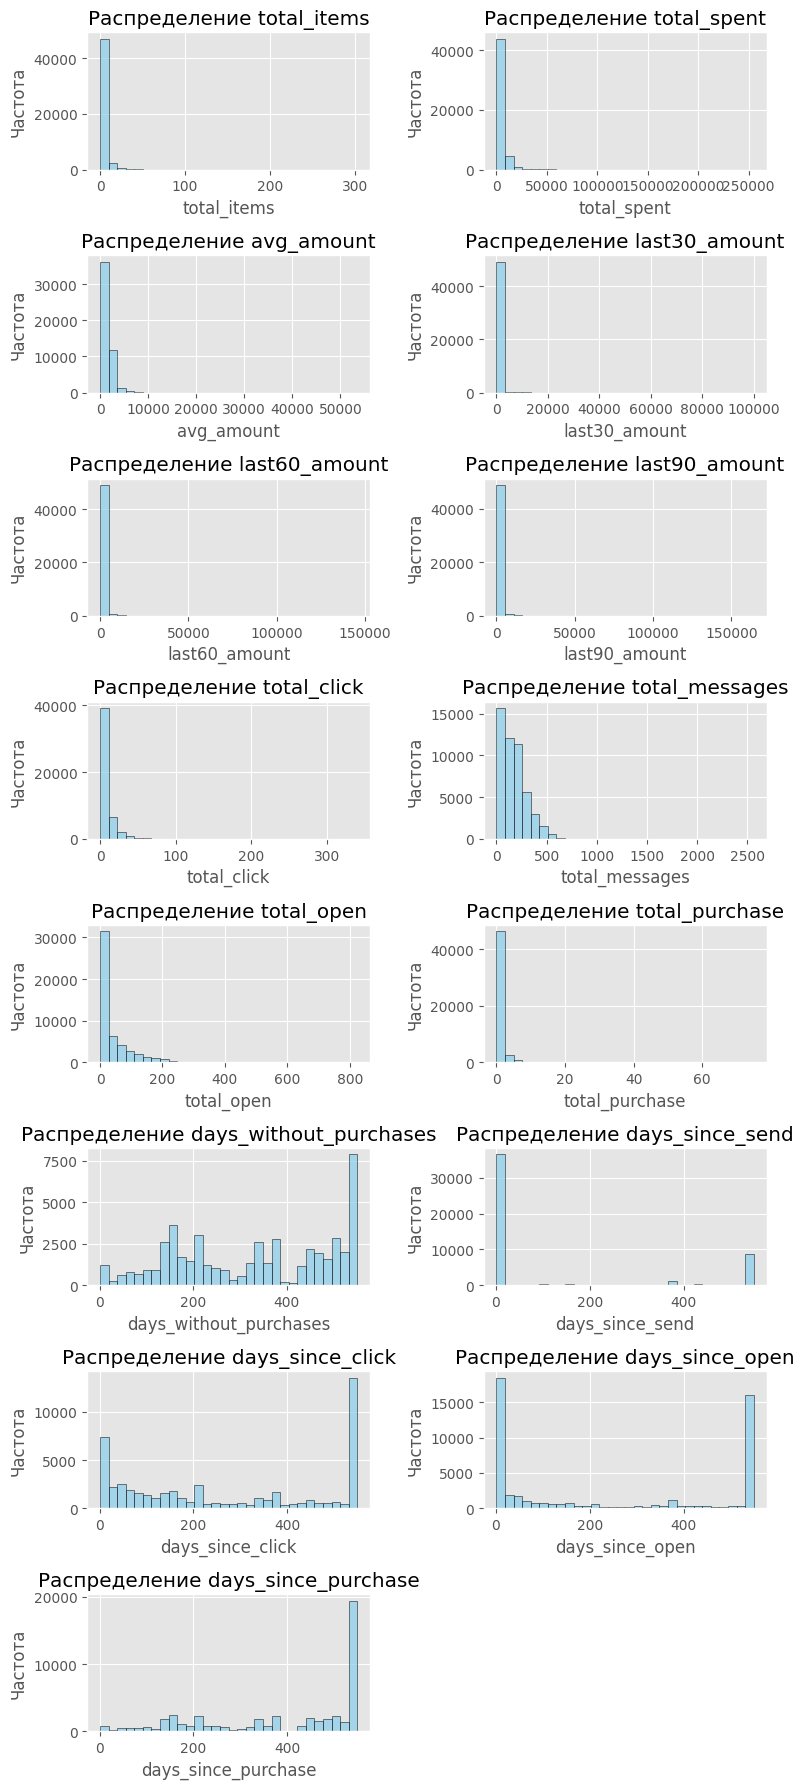

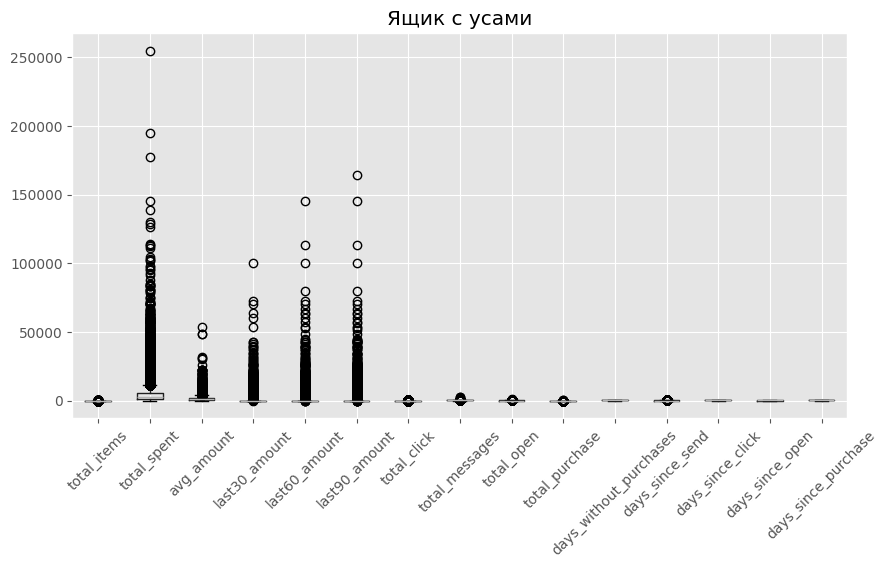

In [195]:
plot_distrib_boxplot(df =df_features, num_feature=top_num_features, figsize_hist=(8, 18), figsize_box=(10, 5))

##### Выводы 

1. Большая часть клиентов не активна. Только небольшая часть делает основную выручку магазину
2. Большинство клиентов просто игнорирует расслыки. очень низкая вовлеченность
3.  у большинства прищнаков не нормальное распределение. Признаки с большим количеством выбросов можно нормалтзовать например при помощи логарифмического преобразования

#### Логарифмическое преобразование признаков с длинным хвостом и большим количеством выбросов

In [196]:
log_features = [ 'total_spent', 'avg_amount', 'last30_amount', 'last60_amount', 'last90_amount' ]



In [197]:
# Проверяем минимальные значения
df_features[log_features].min()


total_spent     0.00
avg_amount      0.00
last30_amount   0.00
last60_amount   0.00
last90_amount   0.00
dtype: float64

In [198]:
# Так как во всех признаках есть нулевые значения но нет отрицательных можно провести преобразование при помощи log1p 

for feature in log_features:
    df_features[f'log1p_{feature}'] = np.log1p(df_features[feature])

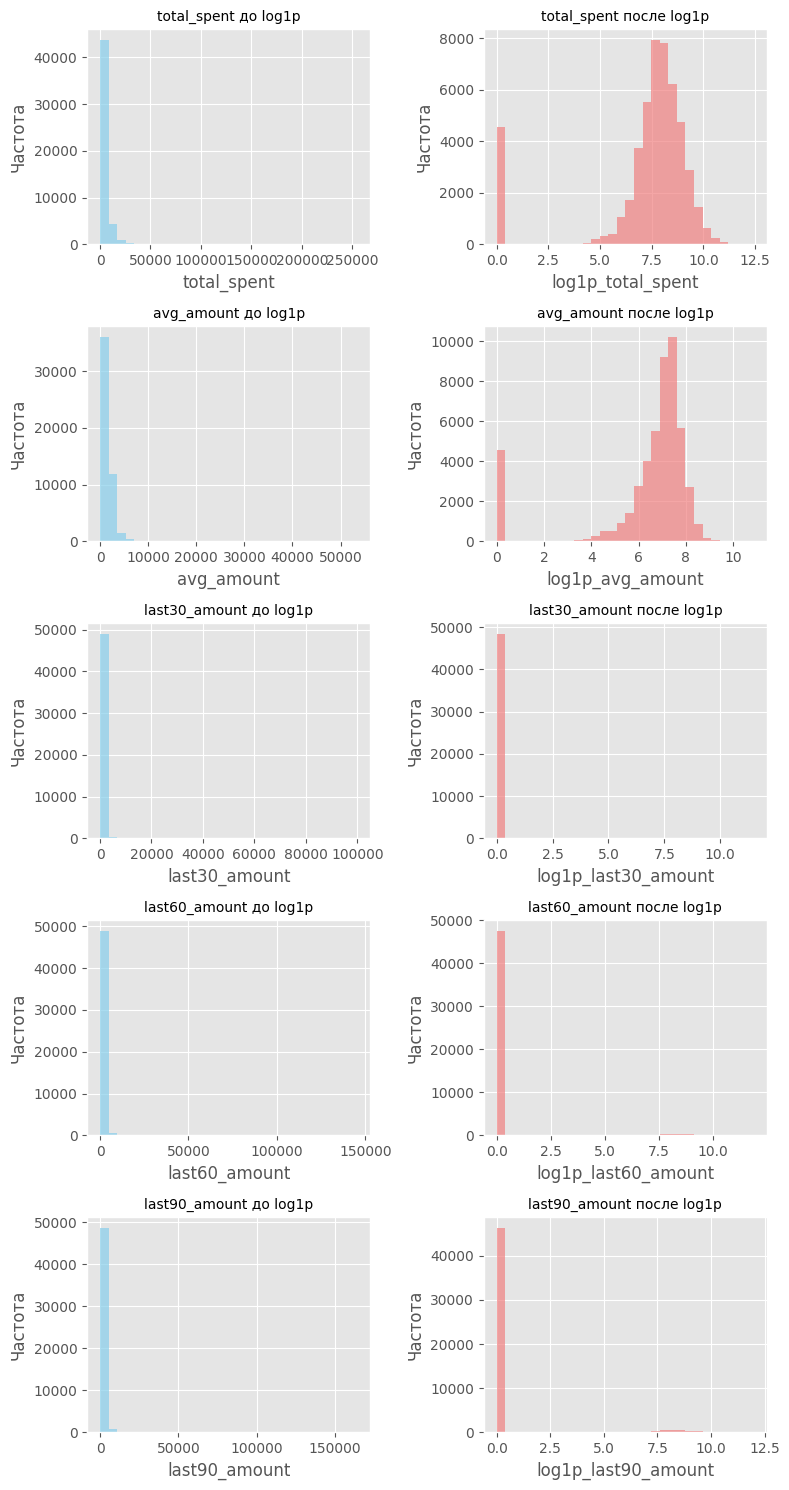

In [199]:
fig, ax = plt.subplots(len(log_features), 2, figsize=(8, 15))

for i, feature in enumerate(log_features):
    # первичное распределение
    ax[i, 0].hist(df_features[feature], bins=30, alpha=0.7, color='skyblue')
    ax[i, 0].set_title(f'{feature} до log1p', fontsize=10)
    ax[i, 0].set_xlabel(feature)
    ax[i, 0].set_ylabel('Частота')

    # распределение после логарифмирования
    ax[i, 1].hist(df_features[f'log1p_{feature}'], bins=30, alpha=0.7, color='lightcoral')
    ax[i, 1].set_title(f'{feature} после log1p', fontsize=10)
    ax[i, 1].set_xlabel(f'log1p_{feature}')
    ax[i, 1].set_ylabel('Частота')

plt.tight_layout()
plt.show()


##### Выводы. 

Устранили сильные различия в масштабе и сильные хвосты
Большинство признаков стало более информативными
пока оставим оба набора признаков и в дальнейшем проведем отбор лучших


#### EDA категориальных признаков

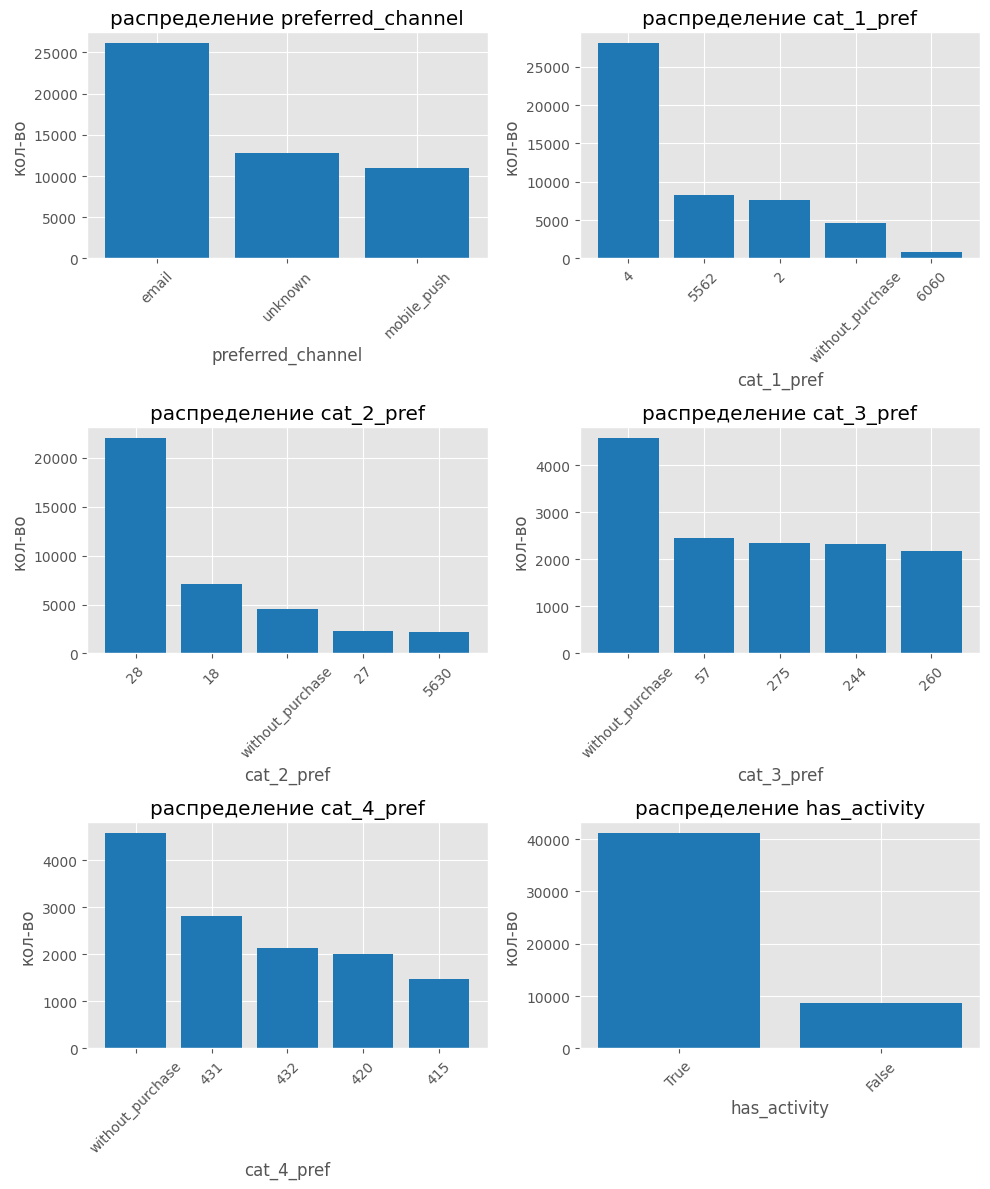

In [200]:
cat_features = ['preferred_channel', 'cat_1_pref', 'cat_2_pref',
                        'cat_3_pref', 'cat_4_pref', 'has_activity']

fig, ax = plt.subplots(3, 2, figsize=(10, 12))

for i, feature in enumerate(cat_features):
    value_counts = df_features[feature].value_counts().head(5)
    row = i // 2  
    col = i % 2   
    ax[row, col].bar(value_counts.index.astype(str), value_counts.values)
    ax[row, col].set_title(f'распределение {feature}')
    ax[row, col].set_xlabel(feature)
    ax[row, col].set_ylabel('кол-во')
    ax[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##### Выводы

Во всех категориях есть доминирующие значения
Холодных клиентов немного. в основном рассылки проводят клиентам которые что то приобретали
В предпочитаемых категориях 3 и 4 уроаня преобладает категория без покупок, а остальные категории распределены более менее равномерно. возможно стоит подумать над исключением этих признаков.

### Матрица корреляций

In [201]:
def phik_matrix_analyze(data, num_cols=None, cat_cols=None , title=None, visualisation=True, n_separator=7, figsize=(14, 14)):
    
    def separator(n=n_separator):
        print('='*n)
        print()
    
    if title:
        print('Анализ матрицы корреляций phik для ' + title)
        separator()
    else:
        print('Анализ матрицы корреляций phik:')
        separator()

    print('')

    df = data.copy()

    # Преобразуем категориальные колонки в тип 'category'
    if cat_cols is not None:
        for col in cat_cols:
            if col in df.columns:
                df[col] = df[col].astype('category')
            else:
                print(f'Колонка {col} не найдена в данных')

    # Убедимся, что числовые колонки имеют числовой тип
    if num_cols is not None:
        for col in num_cols:
            if col in df.columns:
                # Попробуем преобразовать к числовому типу, если возможно
                df[col] = pd.to_numeric(df[col], errors='coerce')
            else:
                print(f'Колонка {col} не найдена в данных')


    # Объединяем все колонки, которые будем использовать
    all_cols = []
    if num_cols is not None:
        all_cols += num_cols
    if cat_cols is not None:
        all_cols += cat_cols

    # Убедимся, что все колонки присутствуют в df
    all_cols = [col for col in all_cols if col in df.columns]

    # Вычисляем матрицу phik
    phik_corr = phik_matrix(
            df[all_cols], 
            interval_cols=num_cols  # передаем только числовые колонки как интервальные
    )

    print('Матрица корреляций phik:')
    display(phik_corr.round(4))

    if visualisation:
        # График матрицы корреляции
        plt.figure(figsize=figsize)
        sns.heatmap(
                    phik_corr, 
                    annot=True, 
                    cmap='PuOr', 
                    center=0, 
                    square=True, 
                    fmt='.3f', 
                    cbar_kws={"shrink": .8}
                    )
        plt.title(rf'Матрица корреляций $\phi_K$ для {title}' if title else r'Матрица корреляций $\phi_K$', 
           fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()
    return phik_corr

In [202]:
drop_features = ['target']

In [203]:
num_features = (
    df_features
    .select_dtypes(include=['float64', 'int64'])
    .columns
    .drop(drop_features, errors='ignore')
    .tolist()
)

cat_features = df_features.select_dtypes(include=['category', 'bool']).columns.tolist()

cat_features.append('target')
    

In [204]:
cat_features

['cat_1_pref',
 'cat_2_pref',
 'cat_3_pref',
 'cat_4_pref',
 'preferred_channel',
 'has_activity',
 'target']

In [ ]:
#  with pd.option_context('display.max_rows', None):
phik_corr = phik_matrix_analyze(
    data=df_features,
    num_cols=num_features,
    cat_cols=cat_features,
    title='Матрица корреляции df_features',
    visualisation=False
)

Анализ матрицы корреляций phik для Матрица корреляции df_features


Матрица корреляций phik:


,total_items,avg_items_per_purchase,total_spent,avg_amount,days_without_purchases,cat_1_nunique,cat_2_nunique,cat_3_nunique,cat_4_nunique,top_cat1_count,top_cat2_count,top_cat3_count,top_cat4_count,last30_items,last30_amount,last30_purchases,last60_items,last60_amount,last60_purchases,last90_items,last90_amount,last90_purchases,unique_event,total_messages,total_click,total_hard_bounce,total_open,total_purchase,total_send,total_unsubscribe,total_send_open_rate,total_click_open_rate,total_send_click_rate,total_click_purchase_rate,email_click,email_open,email_purchase,email_send,email_send_open_rate,email_click_open_rate,email_send_click_rate,email_click_purchase_rate,push_click,push_open,push_purchase,push_send,push_send_open_rate,push_click_open_rate,push_send_click_rate,push_click_purchase_rate,last_30d_click,last_30d_open,last_30d_purchase,last_30d_send,last_30d_send_open_rate,last_30d_click_open_rate,last_30d_send_click_rate,last_30d_click_purchase_rate,last_60d_click,last_60d_open,last_60d_purchase,last_60d_send,last_60d_send_open_rate,last_60d_click_open_rate,last_60d_send_click_rate,last_60d_click_purchase_rate,last_90d_click,last_90d_open,last_90d_purchase,last_90d_send,last_90d_send_open_rate,last_90d_click_open_rate,last_90d_send_click_rate,last_90d_click_purchase_rate,days_since_click,days_since_open,days_since_purchase,days_since_send,log1p_total_spent,log1p_avg_amount,log1p_last30_amount,log1p_last60_amount,log1p_last90_amount,cat_1_pref,cat_2_pref,cat_3_pref,cat_4_pref,preferred_channel,has_activity,target
total_items,1.00,0.07,0.80,0.00,0.05,0.18,0.51,0.69,0.80,0.94,0.79,0.32,0.22,0.45,0.27,0.45,0.83,0.39,0.83,0.76,0.46,0.76,0.00,0.02,0.08,0.12,0.00,0.56,0.00,0.03,0.00,0.26,0.00,0.68,0.08,0.00,0.18,0.00,0.00,0.00,0.04,0.25,0.14,0.00,0.71,0.01,0.00,0.16,0.00,0.69,0.02,0.03,0.18,0.03,0.00,0.04,0.05,0.09,0.06,0.01,0.69,0.04,0.00,0.12,0.03,0.79,0.05,0.00,0.67,0.03,0.00,0.08,0.03,0.79,0.01,0.00,0.04,0.00,0.29,0.10,0.14,0.22,0.21,0.03,0.13,0.38,0.56,0.02,0.00,0.05
avg_items_per_purchase,0.07,1.00,0.00,0.05,0.02,0.03,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02,0.00,0.02,0.07,0.00,0.00,0.00,0.04,0.12,0.34,0.49,0.06,0.01,0.00
total_spent,0.80,0.00,1.00,0.31,0.08,0.15,0.20,0.57,0.59,0.76,0.82,0.39,0.40,0.62,0.53,0.62,0.75,0.75,0.75,0.56,0.76,0.56,0.00,0.00,0.05,0.19,0.00,0.28,0.00,0.01,0.00,0.18,0.00,0.12,0.06,0.00,0.18,0.00,0.00,0.00,0.00,0.16,0.19,0.00,0.31,0.00,0.00,0.22,0.01,0.09,0.03,0.01,0.30,0.00,0.00,0.05,0.00,0.14,0.06,0.00,0.30,0.01,0.00,0.12,0.03,0.00,0.06,0.00,0.41,0.00,0.00,0.08,0.03,0.00,0.00,0.00,0.06,0.00,0.73,0.22,0.18,0.33,0.39,0.03,0.10,0.29,0.39,0.00,0.00,0.04
avg_amount,0.00,0.05,0.31,1.00,0.06,0.04,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.10,0.00,0.00,0.49,0.00,0.00,0.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.02,0.01,0.05,0.00,0.20,0.74,0.07,0.17,0.17,0.03,0.25,0.45,0.74,0.02,0.00,0.00
days_without_purchases,0.05,0.02,0.08,0.06,1.00,0.45,0.25,0.12,0.17,0.06,0.05,0.12,0.09,0.29,0.22,0.29,0.14,0.18,0.14,0.13,0.16,0.13,0.23,0.09,0.06,0.04,0.10,0.04,0.10,0.05,0.06,0.03,0.01,0.02,0.04,0.06,0.03,0.17,0.00,0.01,0.02,0.01,0.04,0.13,0.04,0.13,0.11,0.04,0.07,0.04,0.06,0.08,0.25,0.05,0.00,0.09,0.06,0.35,0.06,0.07,0.06,0.05,0.08,0.14,0.06,0.03,0.06,0.07,0.05,0.04,0.10,0.14,0.05,0.03,0.69,0.35,0.99,0.32,0.55,0.55,0.55,0.75,0.73,0.54,0.51,0.69,0.73,0.30,0.26,0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [206]:
print(f'Размер матрицы {phik_corr.shape}')
print(f'Количество признаков {phik_corr.shape[0]}')

Размер матрицы (90, 90)
Количество признаков 90


In [207]:
phik_no_target = phik_corr.drop(columns=['target'], errors='ignore').drop(index=['target'], errors='ignore')
print(f'Средняя корреляция между признаками: {phik_no_target.values.mean():.4f}')
print(f'Медианная корреляция: {np.median(phik_no_target.values):.4f}')

Средняя корреляция между признаками: 0.1752
Медианная корреляция: 0.0534


In [208]:
target_corr = phik_corr['target'].sort_values(ascending=False)
print('топ-20 признаков по корреляции с target:')
target_corr.head(21).round(4)

топ-20 признаков по корреляции с target:


target                     1.00
cat_4_pref                 0.11
total_click                0.09
last_60d_open              0.09
last_90d_open              0.08
cat_1_nunique              0.08
push_open                  0.08
log1p_total_spent          0.08
log1p_avg_amount           0.08
total_open                 0.08
days_since_click           0.08
cat_4_nunique              0.08
last_60d_click             0.07
last_60d_send_open_rate    0.07
last_90d_click             0.07
cat_3_pref                 0.07
last_60d_click_open_rate   0.07
total_messages             0.07
total_purchase             0.07
log1p_last90_amount        0.07
days_without_purchases     0.07
Name: target, dtype: float64

In [209]:
print('топ-20 признаков с низкой корреляцией с target:')
target_corr.tail(20).round(4)

топ-20 признаков с низкой корреляцией с target:


last30_amount                  0.01
has_activity                   0.01
preferred_channel              0.01
email_send                     0.01
last_30d_send_open_rate        0.01
total_hard_bounce              0.00
avg_items_per_purchase         0.00
avg_amount                     0.00
email_send_open_rate           0.00
email_click_open_rate          0.00
email_send_click_rate          0.00
email_click_purchase_rate      0.00
push_send_click_rate           0.00
push_click_purchase_rate       0.00
total_click_purchase_rate      0.00
total_send_click_rate          0.00
last_90d_click_purchase_rate   0.00
last_90d_purchase              0.00
last_60d_purchase              0.00
last_60d_click_purchase_rate   0.00
Name: target, dtype: float64

In [210]:
# Выделяем верхний треугольник
upper = phik_corr.where(np.triu(np.ones(phik_corr.shape), k=1).astype(bool))

# Все пары с высокой корреляцией
high_corr_pairs = upper.stack().reset_index()
high_corr_pairs.columns = ['feature1', 'feature2', 'phik']
high_corr_pairs = high_corr_pairs[high_corr_pairs['phik'] > 0.85]
high_corr_pairs = high_corr_pairs.sort_values('phik', ascending=False).reset_index(drop=True)

print(f'кол-во пар с Phik > 0.85: {len(high_corr_pairs)}')
print('\nтоп-50 самых зависимых пар:')
high_corr_pairs[high_corr_pairs['phik']>0.84].head(50)

кол-во пар с Phik > 0.85: 96

топ-50 самых зависимых пар:


,feature1,feature2,phik
0,last30_items,last30_purchases,1.00
1,last60_items,last60_purchases,1.00
2,last90_items,last90_purchases,1.00
3,unique_event,has_activity,1.00
4,cat_3_pref,cat_4_pref,1.00
5,days_since_send,has_activity,1.00
6,push_click,push_click_open_rate,1.00
7,cat_2_pref,cat_3_pref,1.00
8,cat_2_pref,cat_4_pref,1.00
9,cat_1_pref,cat_3_pref,0.99


#### Выводы по корреляционному анализу

**Мультиколлинеарность**
Большое количество пар с высокой корреляцией Phik почтиравен 1
многие RFM, логарифмированные признаки, временные окна.

**Наибольшее влияние на `target`**

- `cat_4_pref` - 0.107 (самое сильное влияние)
- `total_click` - 0.086
- `last_60d_open`, `last_90d_open` - 0.086
- `cat_1_nunique`, 
- `push_open`
- `log1p_total_spent`
- `log1p_avg_amount`
  
**наблюдения**

- `days_without_purchases` хорошая корреляция с `log1p_last90_amount` (0.73), `cat_4_pref` (0.73) , `days_since_click` (0.69) Чем дольше пользователь не покупал, тем ниже активность и меньше вариантов выбора товаров.
- 4 уровень категорий товаров (`cat_4_pref` и `cat_4_nunique`) сильнее влияет на target, чем верхние категории (Верхние категории скорее обобщение категори к которой относиься товарная позиция).
- Метрики качества воронки  `last_90d_click_purchase_rate` и аналоги не оказывают влияния на target`.
- лог формы финансовых признаков значительно лучше связаны с целевой переменной чем исходные признаки


In [211]:
df_features

,client_id,target,total_items,avg_items_per_purchase,total_spent,avg_amount,days_without_purchases,cat_1_nunique,cat_1_pref,cat_2_nunique,cat_2_pref,cat_3_nunique,cat_3_pref,cat_4_nunique,cat_4_pref,top_cat1_count,top_cat2_count,top_cat3_count,top_cat4_count,last30_items,last30_amount,last30_purchases,last60_items,last60_amount,last60_purchases,last90_items,last90_amount,last90_purchases,unique_event,total_messages,preferred_channel,total_click,total_hard_bounce,total_open,total_purchase,total_send,total_unsubscribe,total_send_open_rate,total_click_open_rate,total_send_click_rate,total_click_purchase_rate,email_click,email_open,email_purchase,email_send,email_send_open_rate,email_click_open_rate,email_send_click_rate,email_click_purchase_rate,push_click,push_open,push_purchase,push_send,push_send_open_rate,push_click_open_rate,push_send_click_rate,push_click_purchase_rate,last_30d_click,last_30d_open,last_30d_purchase,last_30d_send,last_30d_send_open_rate,last_30d_click_open_rate,last_30d_send_click_rate,last_30d_click_purchase_rate,last_60d_click,last_60d_open,last_60d_purchase,last_60d_send,last_60d_send_open_rate,last_60d_click_open_rate,last_60d_send_click_rate,last_60d_click_purchase_rate,last_90d_click,last_90d_open,last_90d_purchase,last_90d_send,last_90d_send_open_rate,last_90d_click_open_rate,last_90d_send_click_rate,last_90d_click_purchase_rate,days_since_click,days_since_open,days_since_purchase,days_since_send,has_activity,log1p_total_spent,log1p_avg_amount,log1p_last30_amount,log1p_last60_amount,log1p_last90_amount
0,1515915625468060902,0,7,1,6993.00,999.00,540,1,4,2,28,5,176,5,420,7.00,7.00,2.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,149.00,email,8,0.00,29,5,107,0.00,0.27,0.28,0.07,0.62,8,29,5,107,0.27,0.28,0.07,0.62,0,0,0,0,0.00,0.00,0.00,0.00,0,4,0,9,0.44,0.00,0.00,0.00,0,6,0,15,0.40,0.00,0.00,0.00,0,6,0,17,0.35,0.00,0.00,0.00,376,23,540,1,True,8.85,6.91,0.00,0.00,0.00
1,1515915625468061003,1,7,1,16235.00,2319.29,318,1,4,1,28,1,249,1,615,7.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,147.00,email,4,0.00,4,1,138,0.00,0.03,1.00,0.03,0.25,4,4,1,138,0.03,1.00,0.03,0.25,0,0,0,0,0.00,0.00,0.00,0.00,0,0,0,9,0.00,0.00,0.00,0.00,0,0,0,17,0.00,0.00,0.00,0.00,0,0,0,26,0.00,0.00,0.00,0.00,186,186,318,1,True,9.69,7.75,0.00,0.00,0.00
2,1515915625468061099,0,1,1,299.00,299.00,550,1,4,1,28,1,290,1,424,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,247.00,email,8,2.00,50,0,187,0.00,0.27,0.16,0.04,0.00,8,16,0,129,0.12,0.50,0.06,0.00,0,34,0,58,0.59,0.00,0.00,0.00,0,0,0,6,0.00,0.00,0.00,0.00,0,0,0,10,0.00,0.00,0.00,0.00,1,1,0,19,0.05,1.00,0.05,0.00,82,82,549,1,True,5.70,5.70,0.00,0.00,0.00
3,1515915625468061100,0,0,0,0.00,0.00,549,0,without_purchase,0,without_purchase,0,without_purchase,0,without_purchase,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,297.00,unknown,0,1.00,97,0,199,0.00,0.49,0.00,0.00,0.00,0,0,0,0,0.00,0.00,0.00,0.00,0,97,0,199,0.49,0.00,0.00,0.00,0,19,0,20,0.95,0.00,0.00,0.00,0,35,0,39,0.90,0.00,0.00,0.00,0,38,0,56,0.68,0.00,0.00,0.00,549,1,549,1,True,0.00,0.00,0.00,0.00,0.00
4,1515915625468061170,0,19,1,33601.00,1768.47,154,3,4,3,28,4,260,4,420,17.00,17.00,12.00,15.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,178.00,email,16,0.00,24,3,135,0.00,0.18,0.67,0.12,0.19,16,18,3,127,0.14,0.89,0.13,0.19,0,6,0,8,0.75,0.00,0.00,0.00,1,7,0,16,0.44,0.14,0.06,0.00,1,7,0,25,0.28,0.14,0.04,0.00,1,8,0,30,0.27,0.12,0.03,0.00,28,3,154,1,True,10.42,7.48,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49844,1515915626010261344,0,0,0,0.00,0.00,549,0,without_purchase,0,without_purchase,0,without_purchase,0,without_

In [212]:
keep = [ 
 'days_since_purchase',
 'cat_1_nunique',
 'cat_4_nunique',
 'unique_event',
 'email_open',
 'push_click',
 'push_open',
 'last30_items',
 'last90_items',
 'push_send_open_rate',
 'last_30d_open',
 'last_30d_send',
 'last_30d_click_open_rate',
 'last_30d_send_click_rate',
 'last_90d_click',
 'last_90d_open',
 'last_90d_send',
 'last_90d_send_open_rate',
 'last_90d_click_open_rate',
 'days_since_click',
 'days_since_open',
 'days_since_send',
 'log1p_last90_amount',
 'log1p_avg_amount',
 'cat_1_pref',
 'top_cat1_count',
 'top_cat2_count',
 'top_cat3_count',
 'top_cat4_count'

 ]

In [213]:
df_features.to_csv('data/df_features.csv', index=False)

In [214]:
final_df = df_features[['client_id'] + keep + ['target']].copy()

In [215]:
num_features = (
    final_df
    .select_dtypes(include=['float64', 'int64'])
    .loc[:, final_df.select_dtypes(include=['float64', 'int64']).columns != 'target']
    .columns
    .tolist()
)

cat_features = final_df.select_dtypes(include=['category', 'bool']).columns.tolist()
cat_features.append('target')


In [216]:
final_df['target'].value_counts(normalize=True) * 100

target
0   98.07
1    1.93
Name: proportion, dtype: float64

## Обучение модели

### Разделение данных

In [217]:
X = final_df.drop(['client_id', 'target'], axis=1)
y = final_df['target']

In [218]:
cat_cols = X.select_dtypes(include=['category']).columns.tolist()

In [219]:
cat_cols

['cat_1_pref']

In [220]:
bin_cols = X.select_dtypes(include=['bool']).columns.tolist()
bin_cols

[]

In [221]:
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols

['days_since_purchase',
 'cat_1_nunique',
 'cat_4_nunique',
 'unique_event',
 'email_open',
 'push_click',
 'push_open',
 'last30_items',
 'last90_items',
 'push_send_open_rate',
 'last_30d_open',
 'last_30d_send',
 'last_30d_click_open_rate',
 'last_30d_send_click_rate',
 'last_90d_click',
 'last_90d_open',
 'last_90d_send',
 'last_90d_send_open_rate',
 'last_90d_click_open_rate',
 'days_since_click',
 'days_since_open',
 'days_since_send',
 'log1p_last90_amount',
 'log1p_avg_amount',
 'top_cat1_count',
 'top_cat2_count',
 'top_cat3_count',
 'top_cat4_count']

In [222]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
    shuffle=True)


In [223]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(39879, 29)
(39879,)
(9970, 29)
(9970,)


#### Препроцессинг

In [224]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    )) ])

transformers = [('num', num_transformer, num_cols)]

if len(cat_cols) > 0:
    transformers.append(('cat', cat_transformer, cat_cols))
if len(bin_cols) > 0:
    transformers.append(('binary', 'passthrough', bin_cols))

preprocessor = ColumnTransformer(transformers)

In [225]:
transformers

[('num',
  Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                  ('scaler', RobustScaler())]),
  ['days_since_purchase',
   'cat_1_nunique',
   'cat_4_nunique',
   'unique_event',
   'email_open',
   'push_click',
   'push_open',
   'last30_items',
   'last90_items',
   'push_send_open_rate',
   'last_30d_open',
   'last_30d_send',
   'last_30d_click_open_rate',
   'last_30d_send_click_rate',
   'last_90d_click',
   'last_90d_open',
   'last_90d_send',
   'last_90d_send_open_rate',
   'last_90d_click_open_rate',
   'days_since_click',
   'days_since_open',
   'days_since_send',
   'log1p_last90_amount',
   'log1p_avg_amount',
   'top_cat1_count',
   'top_cat2_count',
   'top_cat3_count',
   'top_cat4_count']),
 ('cat',
  Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                  ('encoder',
                   OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
  ['cat_1_pref'])]

In [226]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [227]:
# Взыешивание положительного класса
pos_weight = (y_train.value_counts()[0]/y_train.value_counts()[1])

#### Сетка моделей и параметров

In [228]:
models = {
    # Dummy
    'DummyClassifier': {
        'pipeline': ImbPipeline([
            ('preprocessor', preprocessor),
            ('model', DummyClassifier(random_state=RANDOM_STATE))
        ]),
        'params': {
            'model__strategy': ['prior', 'most_frequent', 'stratified']
        },
        'n_iter': 3
    },

    # Логистическая регрессия
    'LogisticRegression': {
    'pipeline': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),              
        ('model', LogisticRegression(
            max_iter=2000,
            tol=1e-4,
            random_state=RANDOM_STATE
        ))
    ]),
    'params': {
        'model__C': uniform(0.1, 10),
        'model__l1_ratio': [0, 0.5, 1],
        'model__class_weight': ['balanced'],
        'model__solver': ['saga']
    },
    'n_iter': 50
},

    # XGBoost 
    'XGBoost': {
        'pipeline': ImbPipeline([
            ('preprocessor', preprocessor),
            ('model', XGBClassifier(
                objective='binary:logistic',
                scale_pos_weight=pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        'params': {
            'model__n_estimators': randint(300, 1500), 
            'model__learning_rate': uniform(0.01, 0.15), 
            'model__max_depth': randint(3, 10), 
            'model__min_child_weight': randint(1, 10), 
            'model__subsample': uniform(0.6, 0.4),
            'model__colsample_bytree': uniform(0.5, 0.4),  
            'model__colsample_bylevel': uniform(0.6, 0.3),
            'model__reg_alpha': uniform(0, 5), 
            'model__reg_lambda': uniform(0.5, 5),  
            'model__gamma': uniform(0, 3), 
            'model__max_delta_step': randint(1, 10) 
        },
        'n_iter': 70  
    },

    # LightGBM 
    'LightGBM': {
        'pipeline': ImbPipeline([
            ('preprocessor', preprocessor),
            ('model', LGBMClassifier(
                objective='binary',
                scale_pos_weight=pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        'params': {
            'model__n_estimators': randint(200, 1200),
            'model__learning_rate': uniform(0.01, 0.2),
            'model__num_leaves': randint(20, 150),
            'model__max_depth': randint(3, 16),
            'model__subsample': uniform(0.6, 0.4),
            'model__colsample_bytree': uniform(0.6, 0.4),
            'model__min_child_samples': randint(10, 100),
            'model__reg_alpha': uniform(0, 3),
            'model__reg_lambda': uniform(0, 3)
        },
        'n_iter': 70
    }
}

#### Выбор метрики

Так как в данных сильный дисбаланс целевого признака (только 2 % положительного класса), обычную метрику ROC‑AUC брать не тоит так как она  часто даёт слишком позитивную картину  при критическом дисбалансе за счёт того что слишком много разовых (остывших) клиентов.

Вместо неё в качестве основной метрики лучше будет взять `pr-auc`. Она лучше покажет, как модель справиться с поиском именно тех потенциальных клиентов, которые нам нужны. А это напрямую влияет на эффективность рассылок, так как мы хотим находить максимум полезных клиентов и не спамить остальным.

Чтобы ничего не упустить, дополнительно посмотрим на остальные метрики:

- Precision — из всех, кому модель дала положительный класс, сколько реально подходят
- Recall — сколько потенциальных клиентов нашамодель нашла, а сколько пропустила
- F1‑score — общий баланс между этими двумя показателями- ROC‑AUC — в качестве дополнительной общей метрик

In [229]:
scoring = {
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}


#### Поиск оптимаьной модели и параметров

In [230]:
results = []
best_models = {}

In [231]:
for name, config in models.items():

    print(f'\nТренировка модели: {name}')
    separator()

    search = RandomizedSearchCV(
        estimator=config['pipeline'],
        param_distributions=config['params'],
        n_iter=config['n_iter'],
        scoring=scoring,
        refit='pr_auc',
        cv=cv,
        verbose=0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    
    best_idx = search.best_index_
   
    
    results.append(
        {
    'model': name,
    'cv_pr_auc': search.cv_results_['mean_test_pr_auc'][best_idx],
    'cv_roc_auc': search.cv_results_['mean_test_roc_auc'][best_idx],
    'cv_f1': search.cv_results_['mean_test_f1'][best_idx],
    'cv_precision': search.cv_results_['mean_test_precision'][best_idx],
    'cv_recall': search.cv_results_['mean_test_recall'][best_idx],
    'best_params': search.best_params_
    })


    print('\nЛучшая метрика pr_auc на кросс-валидации:')
    print(search.best_score_)

    print('\nЛучшие параметры:')
    print(search.best_params_)


Тренировка модели: DummyClassifier

Лучшая метрика pr_auc на кросс-валидации:
0.019299997143771876

Лучшие параметры:
{'model__strategy': 'stratified'}

Тренировка модели: LogisticRegression


c:\Users\DaD\anaconda3\envs\.pur_predict_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Лучшая метрика pr_auc на кросс-валидации:
0.06095203741636797

Лучшие параметры:
{'model__C': np.float64(2.087156815341724), 'model__class_weight': 'balanced', 'model__l1_ratio': 1, 'model__solver': 'saga'}

Тренировка модели: XGBoost

Лучшая метрика pr_auc на кросс-валидации:
0.0564516602884775

Лучшие параметры:
{'model__colsample_bylevel': np.float64(0.6615135985519575), 'model__colsample_bytree': np.float64(0.6005769758047194), 'model__gamma': np.float64(0.8241953910777263), 'model__learning_rate': np.float64(0.041084147351208467), 'model__max_delta_step': 1, 'model__max_depth': 3, 'model__min_child_weight': 8, 'model__n_estimators': 333, 'model__reg_alpha': np.float64(1.7908135901642024), 'model__reg_lambda': np.float64(1.067787960998145), 'model__subsample': np.float64(0.8686292782371199)}

Тренировка модели: LightGBM
[LightGBM] [Info] Number of positive: 769, number of negative: 39110
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003282

#### Рейтиг моделей

In [232]:
results_df = (pd.DataFrame(results).sort_values(
        'cv_pr_auc',
        ascending=False))
display(results_df)

,model,cv_pr_auc,cv_roc_auc,cv_f1,cv_precision,cv_recall,best_params
1,LogisticRegression,0.06,0.71,0.07,0.04,0.60,"{'model__C': 2.087156815341724, 'model__class_weight': 'balanced', 'model__l1_ratio': 1, 'model__solver': 'saga'}"
2,XGBoost,0.06,0.71,0.07,0.04,0.53,"{'model__colsample_bylevel': 0.6615135985519575, 'model__colsample_bytree': 0.6005769758047194, 'model__gamma': 0.8241953910777263, 'model__learning_rate': 0.041084147351208467, 'model__max_delta_step': 1, 'model__max_depth': 3, 'model__min_child_weight': 8, 'model__n_estimators': 333, 'model__reg_alpha': 1.7908135901642024, 'model__reg_lambda': 1.067787960998145, 'model__subsample': 0.8686292782371199}"
3,LightGBM,0.05,0.71,0.08,0.05,0.40,"{'model__colsample_bytree': 0.7801997007878172, 'model__learning_rate': 0.012652992231973307, 'model__max_depth': 11, 'model__min_child_samples': 69, 'model__n_estimators': 213, 'model__num_leaves': 28, 'model__reg_alpha': 0.04789875666064258, 'model__reg_lambda': 0.692681476866447, 'model__subsample': 0.6964101864104046}"
0,DummyClassifier,0.02,0.50,0.01,0.01,0.01,{'model__strategy': 'stratified'}


In [233]:
results_df.to_csv('results/model_leaderboard.csv', index=False)

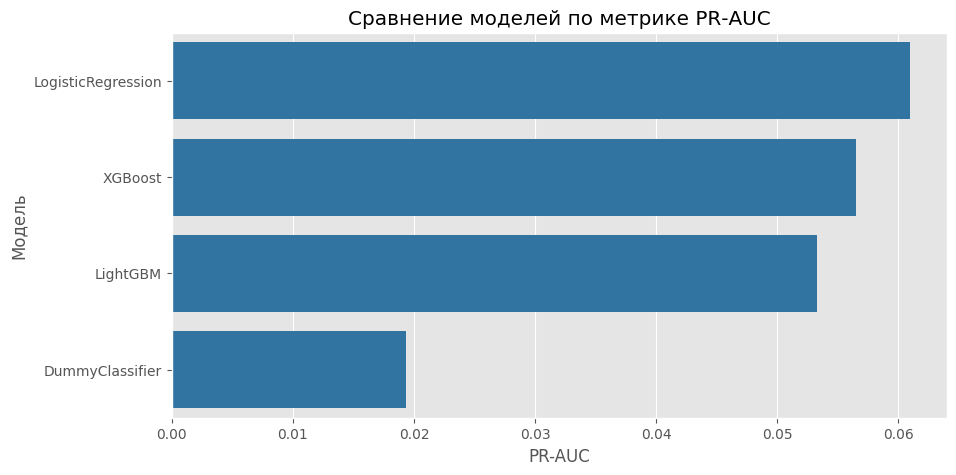

In [234]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x='cv_pr_auc',
    y='model'
)
plt.title('Сравнение моделей по метрике PR‑AUC')
plt.xlabel('PR-AUC')
plt.ylabel('Модель')
plt.show()

In [235]:
best_model_name = results_df.iloc[0]['model']
best_model = best_models[best_model_name]

print('Лучшая модель:')
separator()
print(best_model_name)

Лучшая модель:
LogisticRegression


##### Выводы

По результатам выбора оптимальной модели и её параметров, лучшей моделью  оказалась  `LogisticRegression` (pr-auc = 0.061, Recall = 0.60)
- recall 0.6 - модель находит 60% правильных потенциальных клиентов 
- Но precision = 0.037 говорит о том что только 3-4 из 100 предсказанных реально им являются. Слишком много ложных срабатываний.

При этом метрика `pr_auc`  у всех моделей оказалась крайне низкой
При положительном классе в 2%, baseline всегда предсказывает 0 и даёт PR-AUC = 0.02. Лучшие модели улучшили показатель лишь до 0.06, что лучше но так же непригодно для практического использования.
roc_auc - 0.70-0.71 обманчиво приличный у обоих моделей


Возможные причины:
- Слабые признаки плохо помогают модели разделять классы
- Большое количество выбросоы в числовых значениях
- Возможно стоило упростить признаки,выбрать 7-10 наиболее сильных

Но так как в модели логистической регрессии мы использовали Oversampling необходимо проверить эту модель на переобучение

In [236]:
y_proba = best_model.predict_proba(X_test)[:, 1]


In [237]:
y_pred = (y_proba >= 0.5).astype(int)
pr_auc = average_precision_score(y_test, y_proba)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
print(f'precision: {precision:.4f}')
print(f'recall: {recall:.4f}')
print(f'f1: {f1:.4f}')
print(f'PR_AUC: {pr_auc:.4f}')


precision: 0.0437
recall: 0.7083
f1: 0.0823
PR_AUC: 0.0618


PR‑AUC на тесте и CV почти совпадают - 0.06. переобучения нет. racall вырос но возможно это связано с случайным разбиением данных

##### Сохранение лучшей модели

In [238]:
joblib.dump(best_model,'models/best_model_pipeline.pkl')

['models/best_model_pipeline.pkl']

##### Подбор оптимального порога

In [239]:
thresholds = np.arange(0.10, 0.91, 0.05).round(2)

In [240]:
threshold_metrics = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    threshold_metrics.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })


In [241]:
threshold_df = pd.DataFrame(threshold_metrics).sort_values('f1', ascending=False)
best_threshold = (threshold_df.iloc[0]['threshold'])

In [242]:
threshold_df

,threshold,precision,recall,f1
13,0.75,0.09,0.22,0.13
14,0.80,0.10,0.14,0.12
12,0.70,0.07,0.28,0.11
11,0.65,0.06,0.36,0.10
10,0.60,0.05,0.49,0.09
9,0.55,0.05,0.60,0.09
8,0.50,0.04,0.71,0.08
7,0.45,0.04,0.76,0.07
15,0.85,0.08,0.06,0.07
6,0.40,0.03,0.82,0.06


In [243]:
print('Лучший порог')
separator()
print(best_threshold)

Лучший порог
0.75


In [244]:
y_pred_final = (y_proba >= best_threshold).astype(int)

#### Матрица ошибок

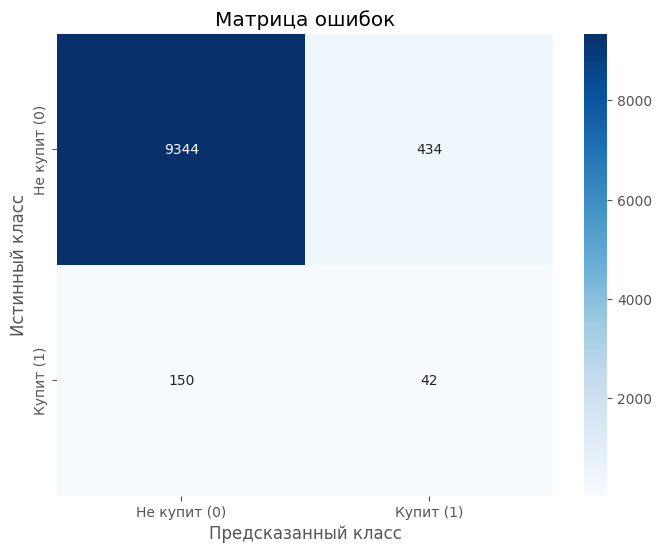

In [245]:
cm = confusion_matrix(y_test, y_pred_final) 

# Матрица ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Не купит (0)', 'Купит (1)'], 
            yticklabels=['Не купит (0)', 'Купит (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

In [246]:
final_pr_auc = average_precision_score(y_test, y_proba)
final_roc_auc = roc_auc_score(y_test, y_proba)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print('Финальные метрики теста с подбором порога')
separator(n=41)
print(f'pr-auc:   {final_pr_auc:.4f}')
print(f'precision: {final_precision:.4f}')
print(f'recall:   {final_recall:.4f}')
print(f'F1: {final_f1:.4f}')
print(f'roc-auc:  {final_roc_auc:.4f}')

Финальные метрики теста с подбором порога
pr-auc:   0.0618
precision: 0.0882
recall:   0.2188
F1: 0.1257
roc-auc:  0.7481


##### Вывод по матрице ошибок

Из реальных покупателей (42 + 150 = 192 человека) модель правильно угадала только 42.  Это очень низкая чувствительность (recall = 0.22).  
Зато ложных срабатываний много. 434 человека которые не купили получили класс что купит. Из-за этого точность критически низкая, всего 8.8%.
PR AUC - 0.06 — почти как случайное угадывание для редкого класса.
ROC AUC - 0.75 выглядит хорошо но крайне обманчив при таком критическом дисбалансе. модель просто хорошо отличает клиентов которые не купят, но не ловит целевую группу коиентов.

##### Анализ важности признаков

In [247]:
feature_names = (best_model.named_steps['preprocessor'].get_feature_names_out())
coefficients = (best_model.named_steps['model'].coef_[0])

In [248]:
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'coeff': coefficients,
    'abs_coeff': np.abs(coefficients)
}).sort_values('abs_coeff', ascending=False)


In [249]:
top20 = feat_imp.head(20)
top20

,feature,coeff,abs_coeff
11,num__last_30d_send,1.42,1.42
16,num__last_90d_send,-1.12,1.12
20,num__days_since_open,-0.93,0.93
13,num__last_30d_send_click_rate,0.85,0.85
32,cat__cat_1_pref_5963,-0.65,0.65
34,cat__cat_1_pref_unknown_cat_1,-0.55,0.55
19,num__days_since_click,-0.49,0.49
30,cat__cat_1_pref_4,0.36,0.36
35,cat__cat_1_pref_without_purchase,-0.28,0.28
33,cat__cat_1_pref_6060,-0.28,0.28


In [250]:
top20.to_csv('results/top20_features.csv', index=False)

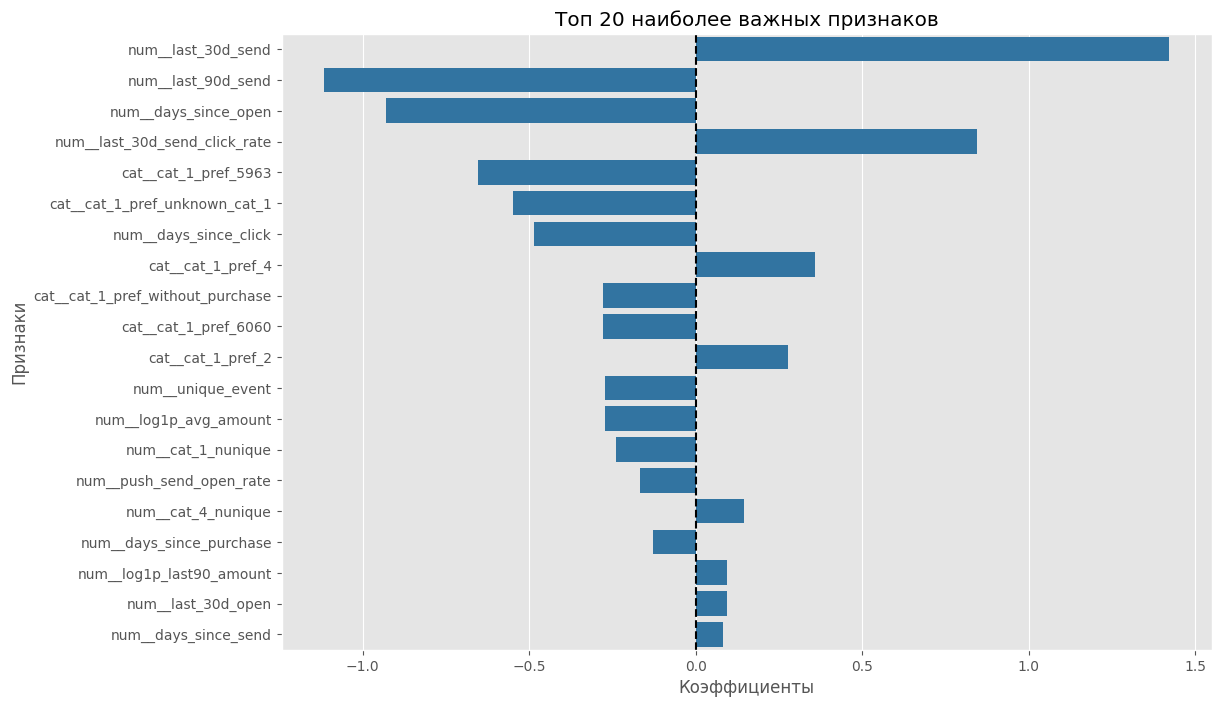

In [251]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top20,
    x='coeff',
    y='feature'
)
plt.title('Топ 20 наиболее важных признаков')
plt.xlabel('Коэффициенты')
plt.ylabel('Признаки')
plt.axvline(0,
    color='black',
    linestyle='--'
)
plt.show()

##### Выводы анализа важности признаков 


Модель считает, что главное — свежая активность за последние 30 дней (открытия, клики, отправки и тд). А вот если активность старая например больше 90 дней назад или пользователь долго молчит то вероятность падает.  
Категорийные предпочтения тоже важны, но работают избирательно,  одни категории дают плюс, другие  минус.  
А вот фактор давно не покупал оказался почти бесполезным что странно и стоит перепроверить.

## Общий вывод по проекту

**Постановка задачи**

В этом проекте я решал задачу прогнозирования, кто из клиентов совершит покупку в течение ближайших 90 дней. Нужно было построить модель, которая на основе истории покупок и истории рассылок предскажет вероятность покупки. Главная бизнес-цель это оптимизация рассылок и сокращение количества спама отправляя предложения только тем покупателям кто действительно готов купить в ближайшие три месяца.



**Что было сделано:**

Что было сделано:

- Выполнена полная загрузка и первичный осмотр всех таблиц.
- Проведена предобработка: приведение типов, удаление дубликатов в apparel-messages, парсинг category_ids, переименование колонок.
- Выполнен  EDA с анализом распределений, временной динамики, воронок конверсии по каналам (email / mobile_push) и сегментации клиентов.
- Реализован  Feature Engineering: RFM-метрики за разные окна, агрегация событий рассылок (send/open/click), признаки recency активности, предпочтения категорий, временные паттерны.
Проведён итоговый корреляционный анализ (phik) с новыми признаками.
- Построен полный пайплайн предобработки и обучения.
- Выполнено сравнение моделей (Dummy, LogisticRegression + SMOTE, XGBoost, LightGBM) с RandomizedSearchCV с выбором в качестве основной метрики PR-AUC.
- Проведён анализ важности признаков, 
- Проведен подбор порога для оптимизации.

**Выбор модели**

Из-за сильного дисбаланса классов в качестве основной метрики я выбрал PR-AUC (average_precision), дополнительно оценивались ROC-AUC, Recall, Precision и F1.
Сравнивались несколько моделей:

- Baseline (DummyClassifier)
- LogisticRegression + SMOTE
- XGBoost
- LightGBM

Все модели обучались с учётом дисбаланса (scale_pos_weight / class_weight / oversampling) и стратифицированной кросс-валидацией.


**Результаты**

Лучшей моделью по совокупности метрик и стабильности стала LogisticRegression которая на тестовой выборке при оптимальном пороге показала следующие результаты:

PR-AUC: 0.0618
ROC-AUC: 0.7481
Recall: 0.2188 (при пороге 0.75)
Precision: 0.0882
F1: 0.1257

Модель хоть и  превосходит случайный baseline, но качество остаётся низким из-за.
Ключевыми источниками прогноза стали признаки свежей активности (отправки, открытия и клики за последние 30 дней), recency взаимодействия и отдельные категории товаров.

Для достижения целевых показателей рекомендуется дальнейшее развитие:  
- углубление feature engineering, 
- эксперименты с дополнительными данными

Проект позволил получить важные инсайты о поведении клиентов и подтвердил критическую роль свежей активности в прогнозировании повторных покупок.
